In [1]:
# Autoload modules
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters, ProteinFoldingResult
from vqe import VQEC, VQECOpt
from qiskit.circuit.library import RealAmplitudes, EfficientSU2, TwoLocal
from qiskit.primitives import Sampler, Estimator
# from qiskit_aer.primitives import Estimator, Sampler
from qiskit_aer import AerSimulator
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient, LinCombEstimatorGradient, LinCombQGT, SPSAEstimatorGradient, FiniteDiffEstimatorGradient
import numpy as np
import matplotlib.pyplot as plt
from qufold.execution_utils.measurements import _evaluate_sparsepauli
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit

## VQEC workflow

In [3]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 10
    penalty_redun = 10
    # penalty_olap = 50

    penalty_terms = PenaltyParameters(penalty_back, penalty_redun)

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(peptide, mj_interaction, penalty_terms)

    return protein_folding_problem

In [4]:
main_seq_4 = "LFLF" # 6MVZ ("LFLF")YYDPETGTWY
protein_folding_problem = build_pf(main_seq_4)
qubit_op = protein_folding_problem.qubit_op()
print(f"Number of qubits: {qubit_op.num_qubits}")
print(f"Number of terms: {len(qubit_op)}")

[[ 0.   -7.28 -7.37 -7.28]
 [ 0.    0.   -7.28 -7.26]
 [ 0.    0.    0.   -7.28]
 [ 0.    0.    0.    0.  ]]
Number of qubits: 9
Number of terms: 107


In [5]:
print(qubit_op)

SparsePauliOp(['IIIIIIIII', 'IIIZZIIII', 'IIIZIZZII', 'IIIIZZZII', 'IIIIIIZZI', 'IIIZZIZZI', 'IIIZIZIZI', 'IIIIZZIZI', 'IIIIIZIIZ', 'IIIZZZIIZ', 'IIIZIIZIZ', 'IIIIZIZIZ', 'IIIIIZZZZ', 'IIIZZZZZZ', 'IIIZIIIZZ', 'IIIIZIIZZ', 'IIIIIZZII', 'IIIZZZZII', 'IIIIIIIZI', 'IIIIIIIZZ', 'IIZIIIIII', 'IIZIIIIZI', 'IIZIIIIZZ', 'IIIIIZIII', 'IIIZIZIII', 'IIIIZZIII', 'IIIZZZIII', 'IIIIIIZII', 'IIIZIIZII', 'IIIIZIZII', 'IIIZZIZII', 'IIIIIZIZI', 'IIIZZZIZI', 'IIIZIIZZI', 'IIIZIIIII', 'IIIIZIIII', 'IIIIIZIZZ', 'IIIZZZIZZ', 'IIIIIIZZZ', 'IIIZZIZZZ', 'IIIZIZZZZ', 'IIIIZZZZZ', 'IIIIZZIIZ', 'IZIIIIIII', 'IZIIIIIZI', 'IZIIIZIII', 'IZIZIZIII', 'IZIIZZIII', 'IZIZZZIII', 'IZIIIIZII', 'IZIZIIZII', 'IZIIZIZII', 'IZIZZIZII', 'IZIIIZIZI', 'IZIZIZIZI', 'IZIIZZIZI', 'IZIZZZIZI', 'IZIIIIZZI', 'IZIZIIZZI', 'IZIZZIZZI', 'IZIZIIIII', 'IZIIZIIII', 'IZIZZIIII', 'IZIIIZZII', 'IZIZIZZII', 'IZIIZZZII', 'IZIZZZZII', 'IZIIIIIZZ', 'IZIZIIIZZ', 'IZIIZIIZZ', 'IZIIIZIZZ', 'IZIZZZIZZ', 'IZIIIIZZZ', 'IZIZZIZZZ', 'IZIZIZZZZ', 'IZIIZZZZZ

In [6]:
bead_pairs, olap_constr_ops = protein_folding_problem.olap_constr_ops()
print(f"Number of overlap constraints: {len(olap_constr_ops)}")
print(f"Number of qubits: {olap_constr_ops[0].num_qubits}")

Number of overlap constraints: 1
Number of qubits: 9


In [7]:
# ansatz_ra = RealAmplitudes(qubit_op.num_qubits, skip_final_rotation_layer=False)

ansatz_su2 = EfficientSU2(qubit_op.num_qubits, skip_final_rotation_layer=False)

In [8]:
estimator = Estimator()
# estimator = Estimator(backend_options={'method': 'matrix_product_state'})
#gradient_finitediff = FiniteDiffEstimatorGradient(estimator=estimator, epsilon=0.01)
#gradient_paramshift = ParamShiftEstimatorGradient(estimator=estimator)
gradient_lincomb = LinCombEstimatorGradient(estimator=estimator)
#gradient_spsa = SPSAEstimatorGradient(estimator=estimator, epsilon=0.01, batch_size=10, seed=50)

C:\Users\8J6010897\AppData\Local\Temp\ipykernel_52636\3143096275.py:1: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator()


Testing primal_perturb_step=0.0001, dual_perturb_step=0.0001


100%|██████████| 200/200 [03:19<00:00,  1.00it/s]


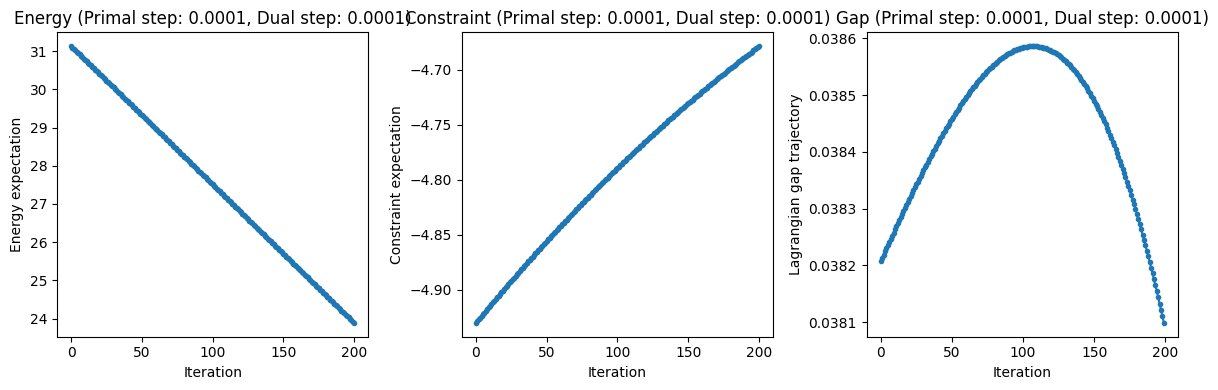

C:\Users\8J6010897\AppData\Local\Temp\ipykernel_52636\1855327178.py:51: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler(options={"shots": 10000})


Sample 0: 000001111 with probability 0.0154 and energy 0.0
Sample 1: 000000011 with probability 0.011 and energy -7.105427357601002e-15
Sample 2: 000101001 with probability 0.0109 and energy 1.0658141036401503e-14
Sample 3: 011010101 with probability 0.0109 and energy 58.50999999999999
Sample 4: 000000110 with probability 0.0103 and energy 10.0
Testing primal_perturb_step=0.0001, dual_perturb_step=0.005644444444444445


100%|██████████| 200/200 [03:19<00:00,  1.00it/s]


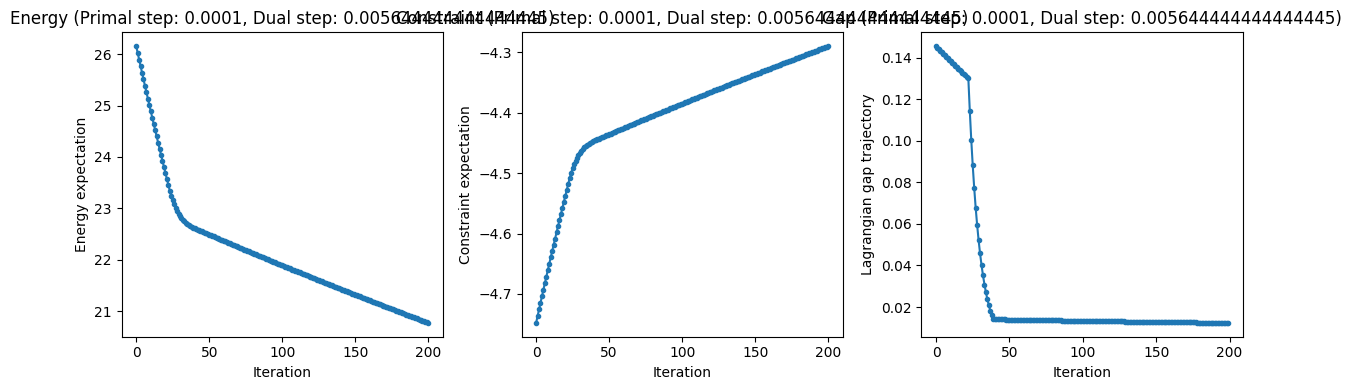

Sample 0: 000001011 with probability 0.0212 and energy 0.0
Sample 1: 110101011 with probability 0.0163 and energy -14.540000000000003
Sample 2: 000010011 with probability 0.0131 and energy 10.000000000000005
Sample 3: 000010101 with probability 0.0131 and energy -8.881784197001252e-15
Sample 4: 110111011 with probability 0.0125 and energy 43.61999999999999
Testing primal_perturb_step=0.0001, dual_perturb_step=0.011188888888888889


100%|██████████| 200/200 [03:11<00:00,  1.05it/s]


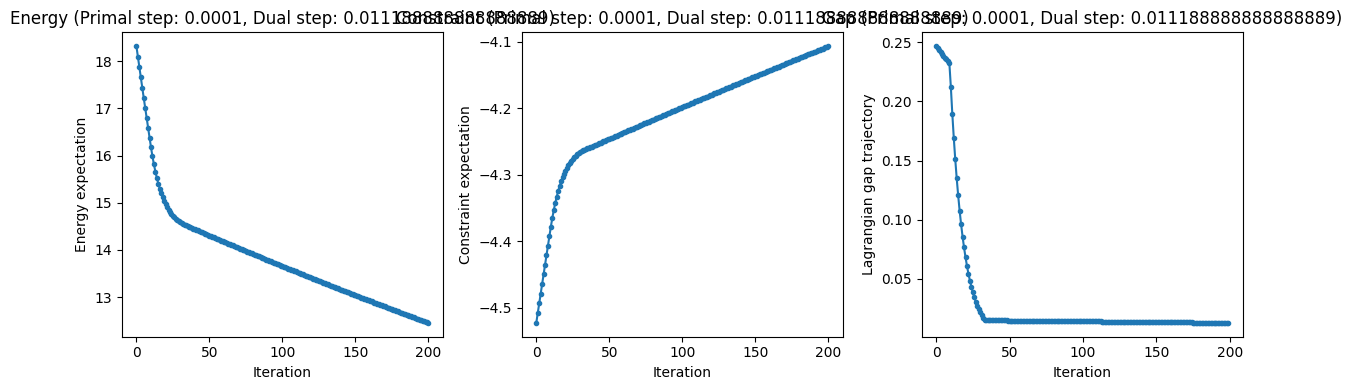

Sample 0: 000111001 with probability 0.0353 and energy 0.0
Sample 1: 000011011 with probability 0.0341 and energy -5.773159728050814e-15
Sample 2: 000101001 with probability 0.0222 and energy 1.0658141036401503e-14
Sample 3: 100000011 with probability 0.0216 and energy 7.259999999999996
Sample 4: 100111001 with probability 0.0165 and energy 7.259999999999998
Testing primal_perturb_step=0.0001, dual_perturb_step=0.016733333333333333


100%|██████████| 200/200 [03:09<00:00,  1.05it/s]


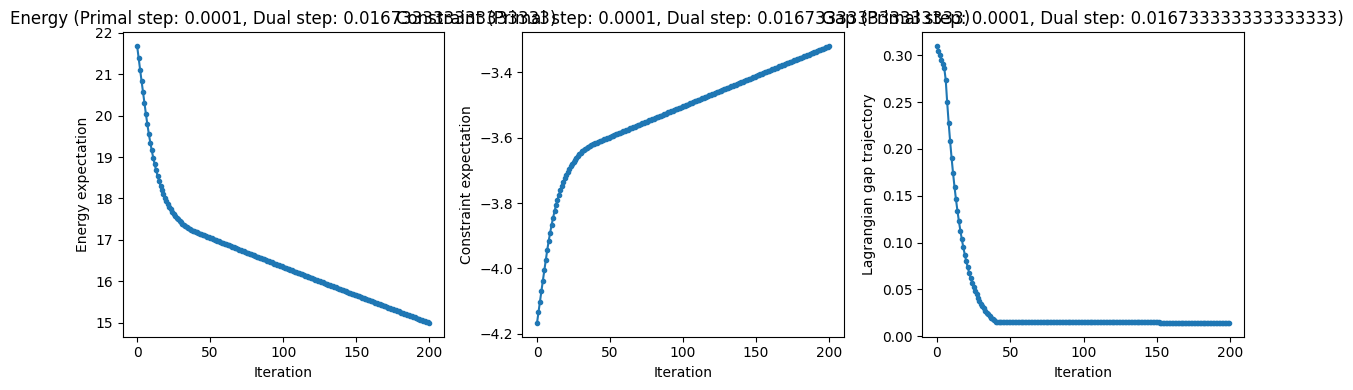

Sample 0: 100001010 with probability 0.0381 and energy 36.3
Sample 1: 100011110 with probability 0.0234 and energy 2.7400000000000064
Sample 2: 101011110 with probability 0.0227 and energy -4.629999999999998
Sample 3: 000001010 with probability 0.0217 and energy -3.552713678800501e-15
Sample 4: 110101110 with probability 0.0213 and energy -4.540000000000003
Testing primal_perturb_step=0.0001, dual_perturb_step=0.02227777777777778


100%|██████████| 200/200 [03:17<00:00,  1.01it/s]


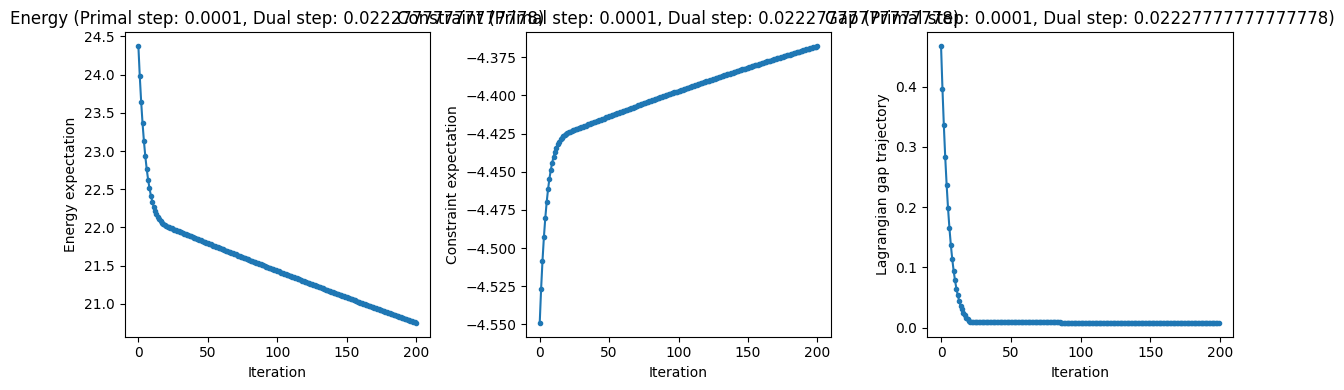

Sample 0: 000110010 with probability 0.036 and energy -3.552713678800501e-15
Sample 1: 000100000 with probability 0.0206 and energy 10.000000000000004
Sample 2: 010001000 with probability 0.0182 and energy 21.839999999999996
Sample 3: 011010010 with probability 0.0175 and energy -4.6500000000000075
Sample 4: 010001100 with probability 0.0159 and energy 50.959999999999994
Testing primal_perturb_step=0.0001, dual_perturb_step=0.027822222222222224


100%|██████████| 200/200 [03:18<00:00,  1.01it/s]


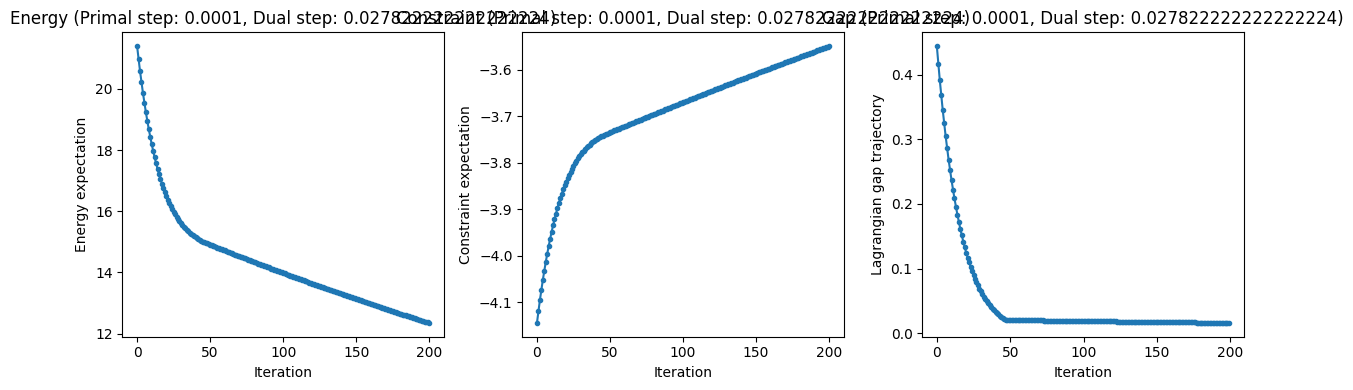

Sample 0: 001100110 with probability 0.0526 and energy -7.370000000000003
Sample 1: 000100110 with probability 0.0409 and energy 5.329070518200751e-15
Sample 2: 001011110 with probability 0.0363 and energy 2.630000000000001
Sample 3: 001011011 with probability 0.0327 and energy 7.369999999999999
Sample 4: 001111111 with probability 0.0316 and energy 17.36999999999999
Testing primal_perturb_step=0.0001, dual_perturb_step=0.03336666666666667


100%|██████████| 200/200 [03:19<00:00,  1.00it/s]


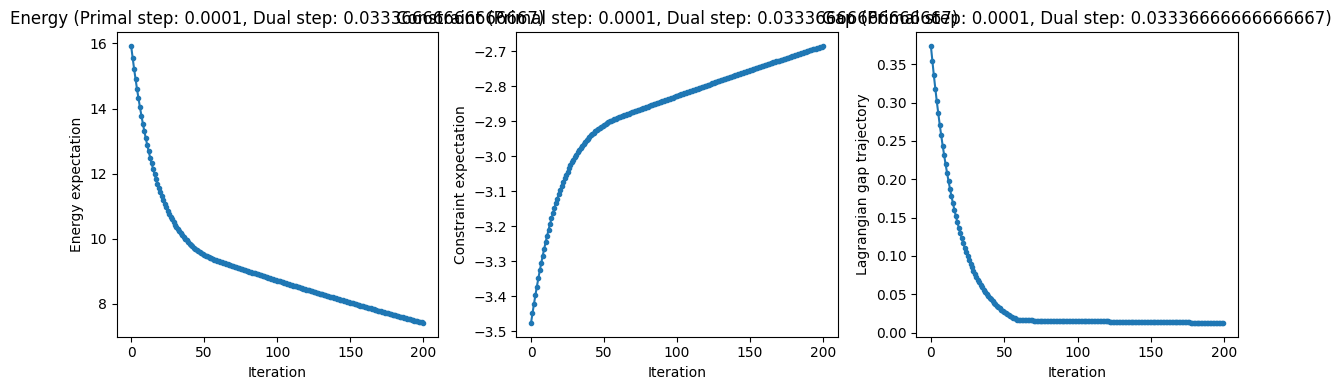

Sample 0: 000100110 with probability 0.0485 and energy 5.329070518200751e-15
Sample 1: 001001110 with probability 0.0451 and energy -7.36999999999999
Sample 2: 000100010 with probability 0.0291 and energy 9.999999999999998
Sample 3: 001110110 with probability 0.0264 and energy -7.370000000000001
Sample 4: 000101110 with probability 0.023 and energy 9.999999999999998
Testing primal_perturb_step=0.0001, dual_perturb_step=0.03891111111111112


100%|██████████| 200/200 [03:15<00:00,  1.03it/s]


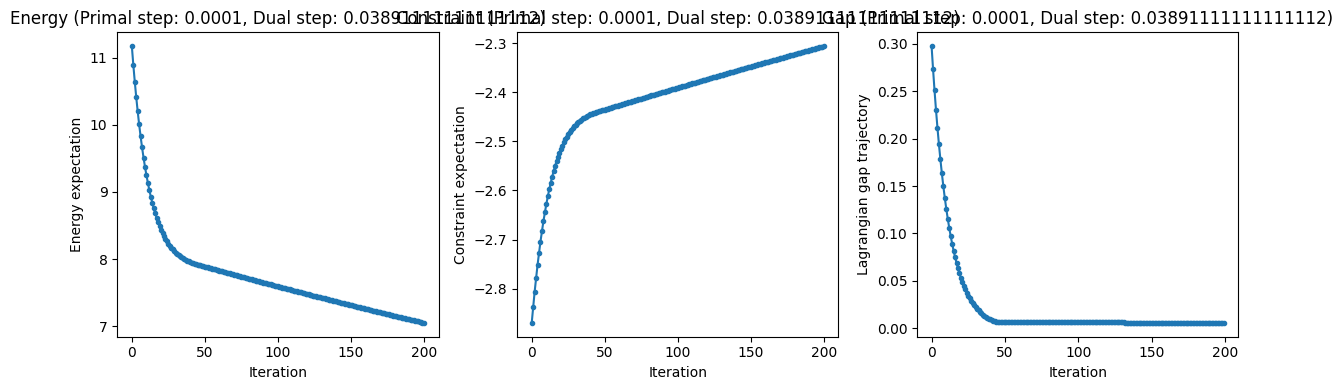

Sample 0: 100011010 with probability 0.0613 and energy -7.2600000000000104
Sample 1: 100000111 with probability 0.0447 and energy -7.260000000000001
Sample 2: 100010010 with probability 0.0438 and energy 2.740000000000011
Sample 3: 100100010 with probability 0.0287 and energy 2.7400000000000038
Sample 4: 100101010 with probability 0.0269 and energy 21.779999999999998
Testing primal_perturb_step=0.0001, dual_perturb_step=0.04445555555555556


100%|██████████| 200/200 [03:15<00:00,  1.02it/s]


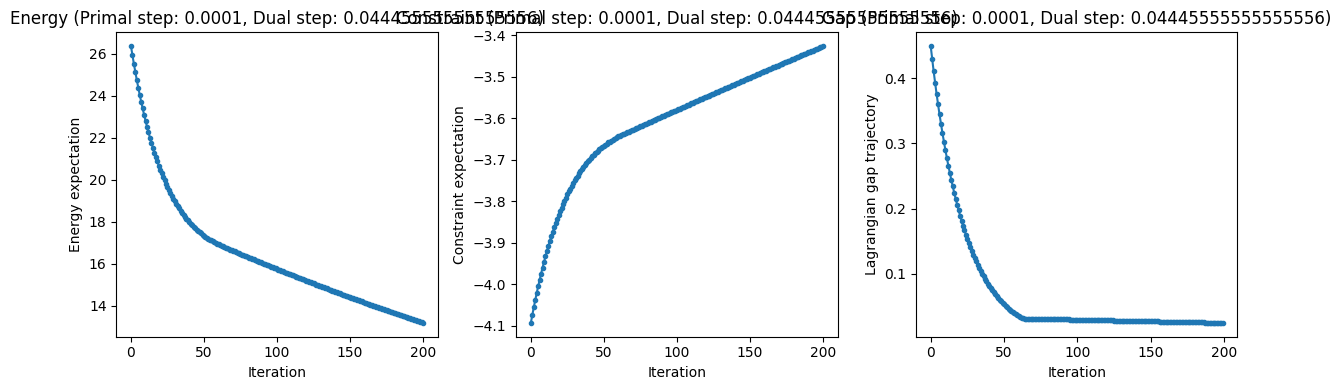

Sample 0: 011000110 with probability 0.0474 and energy -4.6500000000000075
Sample 1: 100010110 with probability 0.0409 and energy 21.779999999999987
Sample 2: 011010110 with probability 0.0338 and energy 29.029999999999994
Sample 3: 011100110 with probability 0.0324 and energy -0.09000000000000519
Sample 4: 011101100 with probability 0.0312 and energy 83.25
Testing primal_perturb_step=0.0001, dual_perturb_step=0.05


100%|██████████| 200/200 [03:15<00:00,  1.02it/s]


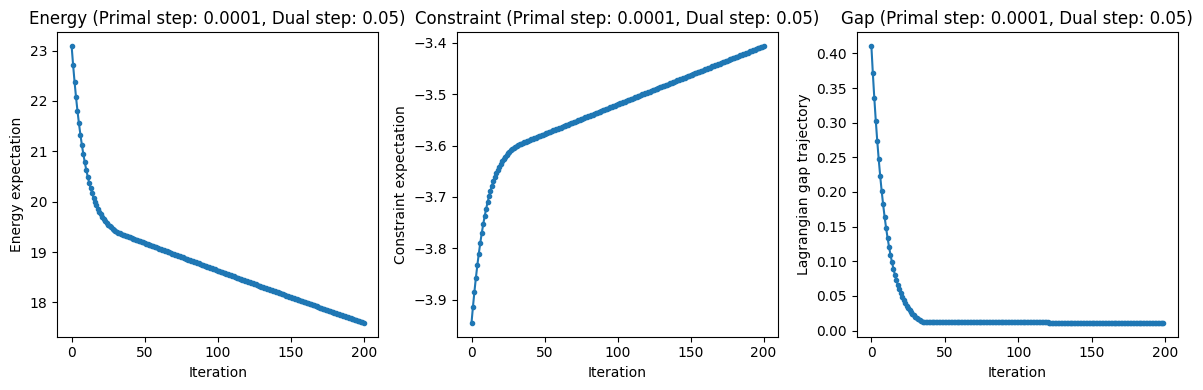

Sample 0: 010111010 with probability 0.0275 and energy -7.280000000000008
Sample 1: 010110001 with probability 0.0192 and energy -7.280000000000001
Sample 2: 010110111 with probability 0.0178 and energy 21.839999999999996
Sample 3: 101011010 with probability 0.0174 and energy -14.629999999999994
Sample 4: 010001000 with probability 0.0168 and energy 21.839999999999996
Testing primal_perturb_step=0.005644444444444445, dual_perturb_step=0.0001


100%|██████████| 200/200 [03:16<00:00,  1.02it/s]


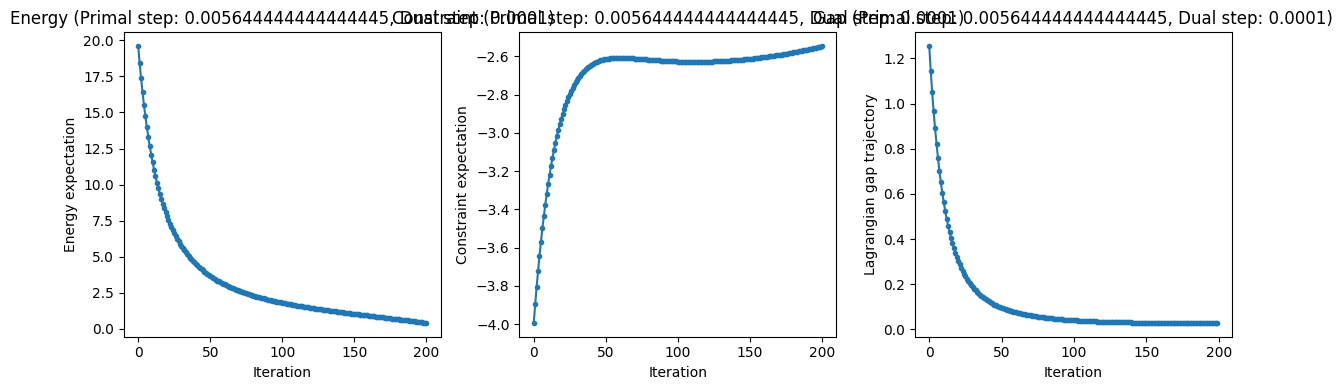

Sample 0: 001101010 with probability 0.1066 and energy -7.3700000000000045
Sample 1: 001110010 with probability 0.0828 and energy -7.369999999999994
Sample 2: 001000010 with probability 0.0562 and energy -7.370000000000003
Sample 3: 001001010 with probability 0.0501 and energy -7.370000000000001
Sample 4: 000011011 with probability 0.0443 and energy -5.773159728050814e-15
Testing primal_perturb_step=0.005644444444444445, dual_perturb_step=0.005644444444444445


100%|██████████| 200/200 [03:16<00:00,  1.02it/s]


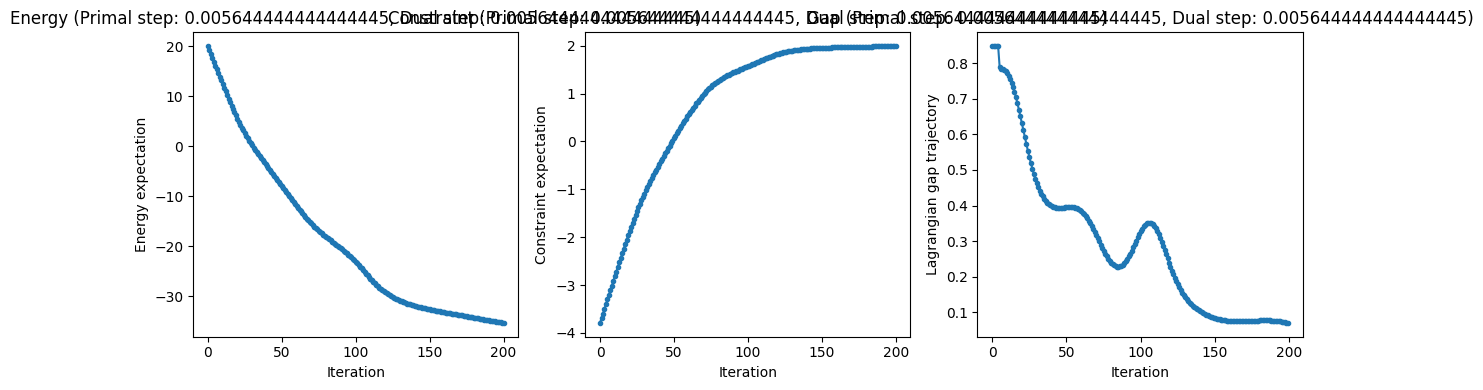

Sample 0: 111011010 with probability 0.867 and energy -36.46999999999999
Sample 1: 110011010 with probability 0.1161 and energy -29.100000000000012
Sample 2: 101011010 with probability 0.0078 and energy -14.629999999999994
Sample 3: 011011010 with probability 0.0017 and energy -29.209999999999994
Sample 4: 100000110 with probability 0.0017 and energy -11.780000000000006
Testing primal_perturb_step=0.005644444444444445, dual_perturb_step=0.011188888888888889


100%|██████████| 200/200 [03:15<00:00,  1.02it/s]


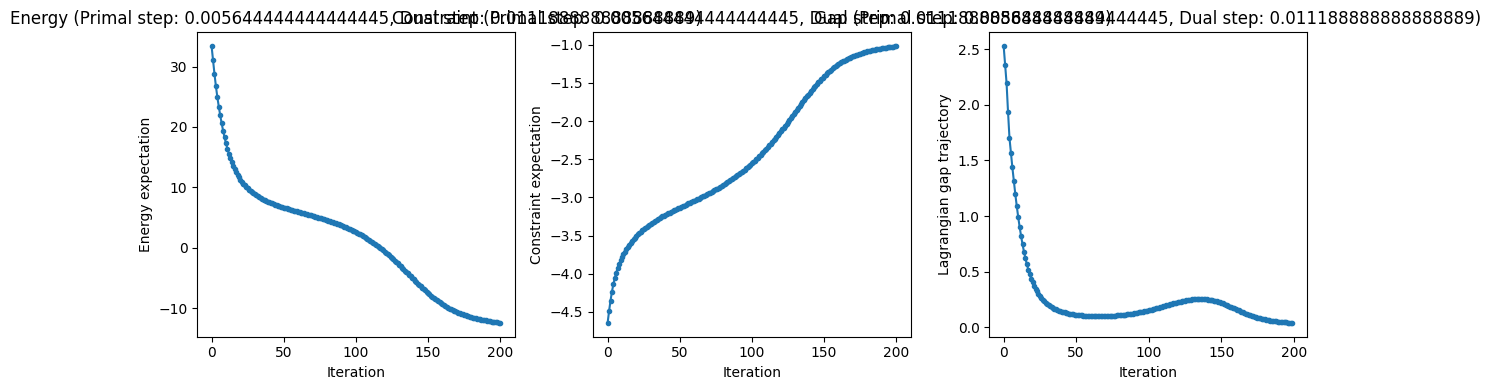

Sample 0: 101100110 with probability 0.3787 and energy -14.63
Sample 1: 101111110 with probability 0.2242 and energy -14.62999999999998
Sample 2: 100001001 with probability 0.1009 and energy -11.780000000000001
Sample 3: 100101001 with probability 0.0824 and energy -7.259999999999991
Sample 4: 100111110 with probability 0.0683 and energy -7.259999999999996
Testing primal_perturb_step=0.005644444444444445, dual_perturb_step=0.016733333333333333


100%|██████████| 200/200 [03:13<00:00,  1.04it/s]


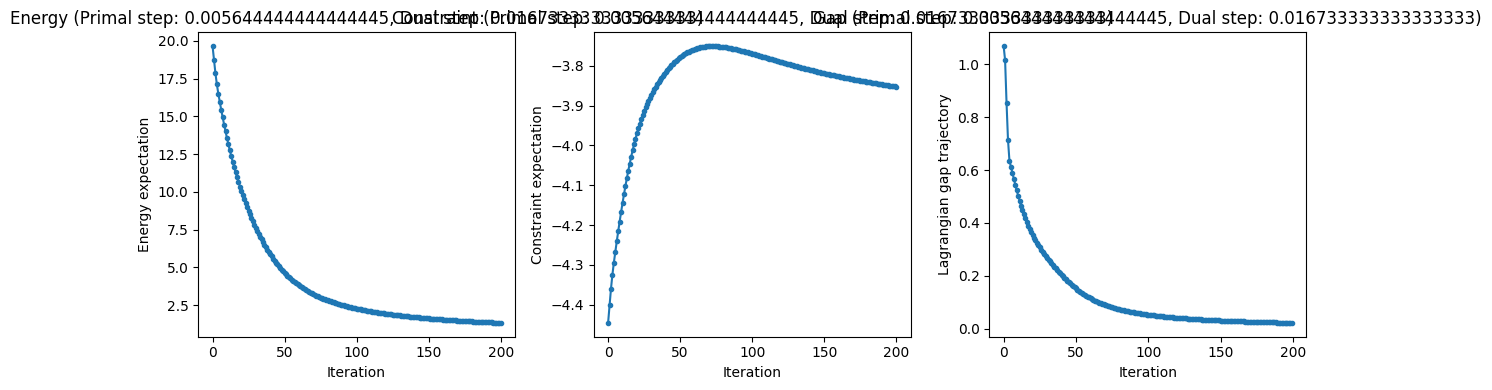

Sample 0: 000101000 with probability 0.1825 and energy 6.661338147750939e-15
Sample 1: 000101001 with probability 0.1207 and energy 1.0658141036401503e-14
Sample 2: 000110111 with probability 0.0529 and energy -1.7763568394002505e-15
Sample 3: 000011000 with probability 0.0497 and energy -2.6645352591003757e-15
Sample 4: 000010110 with probability 0.045 and energy -8.881784197001252e-15
Testing primal_perturb_step=0.005644444444444445, dual_perturb_step=0.02227777777777778


100%|██████████| 200/200 [03:19<00:00,  1.00it/s]


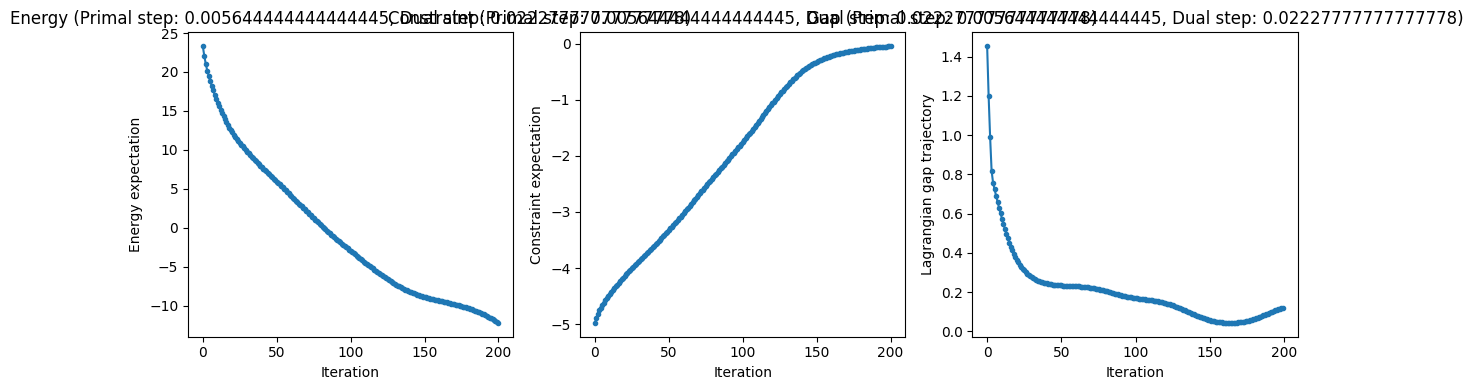

Sample 0: 100111111 with probability 0.3383 and energy -11.779999999999992
Sample 1: 100101011 with probability 0.2606 and energy -7.26
Sample 2: 110111111 with probability 0.2123 and energy -19.059999999999988
Sample 3: 110101011 with probability 0.1649 and energy -14.540000000000003
Sample 4: 010111111 with probability 0.0057 and energy 2.720000000000006
Testing primal_perturb_step=0.005644444444444445, dual_perturb_step=0.027822222222222224


100%|██████████| 200/200 [03:33<00:00,  1.07s/it]


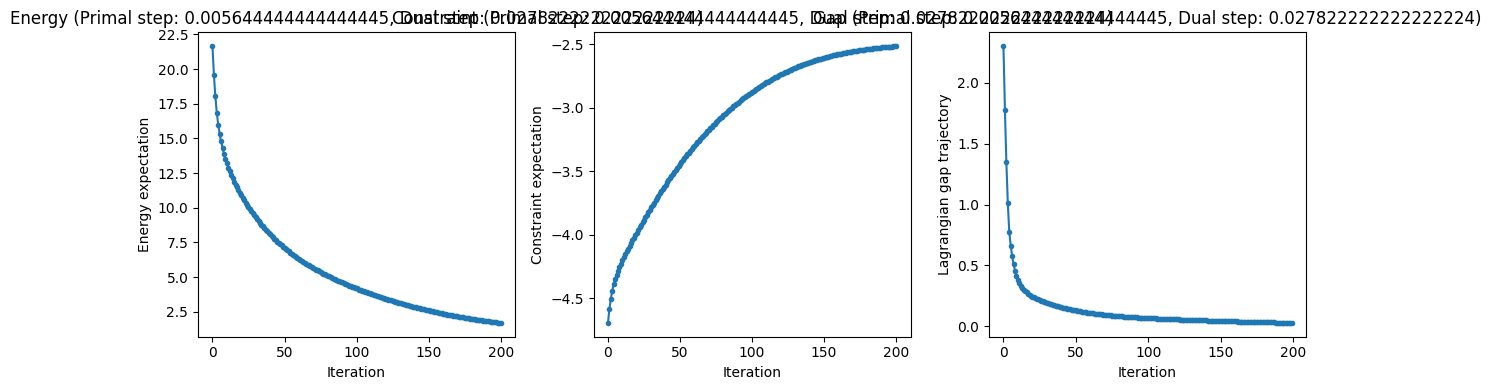

Sample 0: 000111110 with probability 0.0872 and energy 7.105427357601002e-15
Sample 1: 000110011 with probability 0.0859 and energy 8.881784197001252e-16
Sample 2: 000110010 with probability 0.0805 and energy -3.552713678800501e-15
Sample 3: 000111011 with probability 0.0759 and energy -3.552713678800501e-15
Sample 4: 000110111 with probability 0.0624 and energy -1.7763568394002505e-15
Testing primal_perturb_step=0.005644444444444445, dual_perturb_step=0.03336666666666667


100%|██████████| 200/200 [04:02<00:00,  1.21s/it]


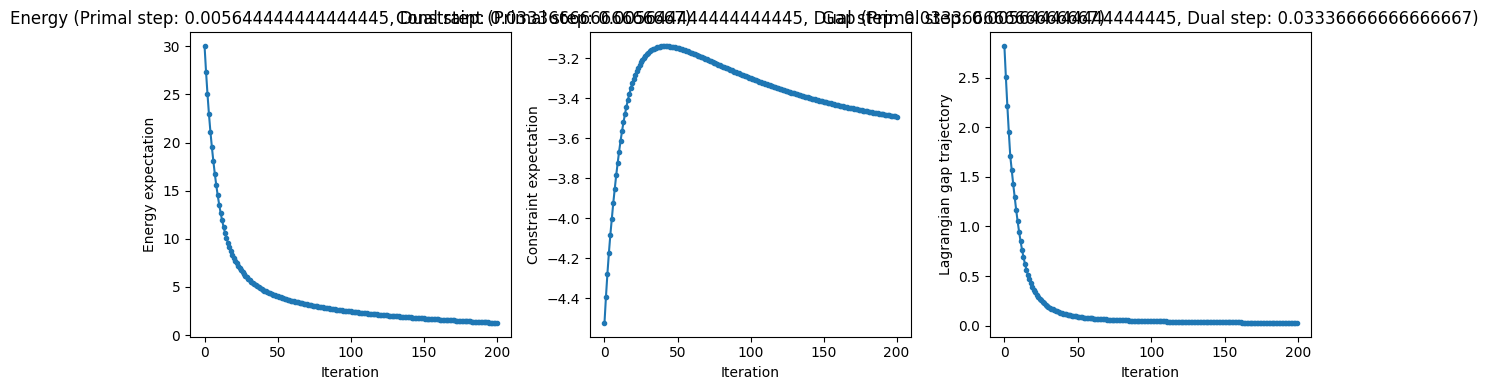

Sample 0: 000000010 with probability 0.1653 and energy -5.329070518200751e-15
Sample 1: 100000010 with probability 0.0714 and energy -7.260000000000005
Sample 2: 000110010 with probability 0.0697 and energy -3.552713678800501e-15
Sample 3: 000111010 with probability 0.0521 and energy -4.884981308350689e-15
Sample 4: 000110101 with probability 0.0422 and energy -1.7763568394002505e-15
Testing primal_perturb_step=0.005644444444444445, dual_perturb_step=0.03891111111111112


100%|██████████| 200/200 [03:22<00:00,  1.01s/it]


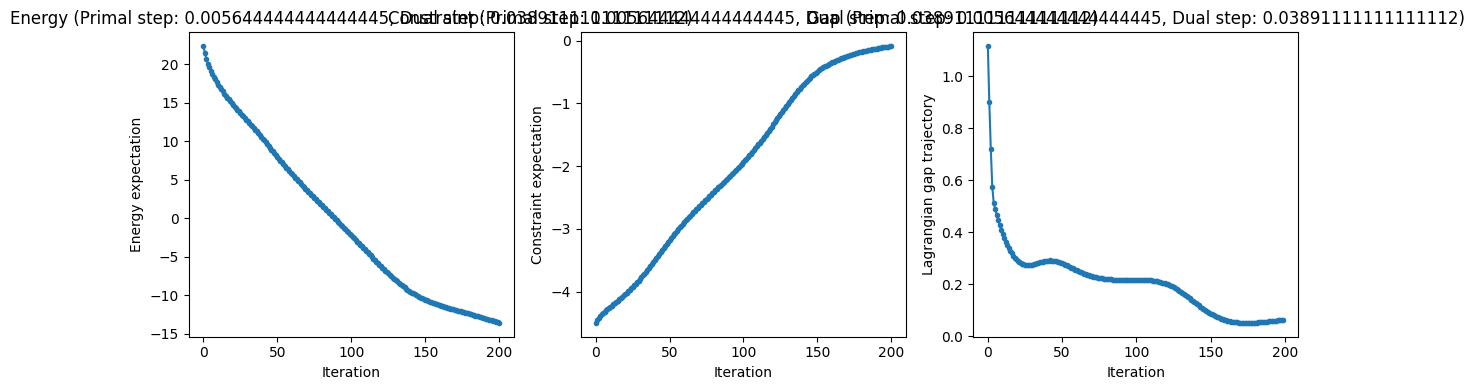

Sample 0: 100001001 with probability 0.1721 and energy -11.780000000000001
Sample 1: 100111111 with probability 0.1664 and energy -11.779999999999992
Sample 2: 100110000 with probability 0.1656 and energy -11.779999999999998
Sample 3: 100000110 with probability 0.1578 and energy -11.780000000000006
Sample 4: 110000110 with probability 0.0801 and energy -19.060000000000016
Testing primal_perturb_step=0.005644444444444445, dual_perturb_step=0.04445555555555556


100%|██████████| 200/200 [03:21<00:00,  1.01s/it]


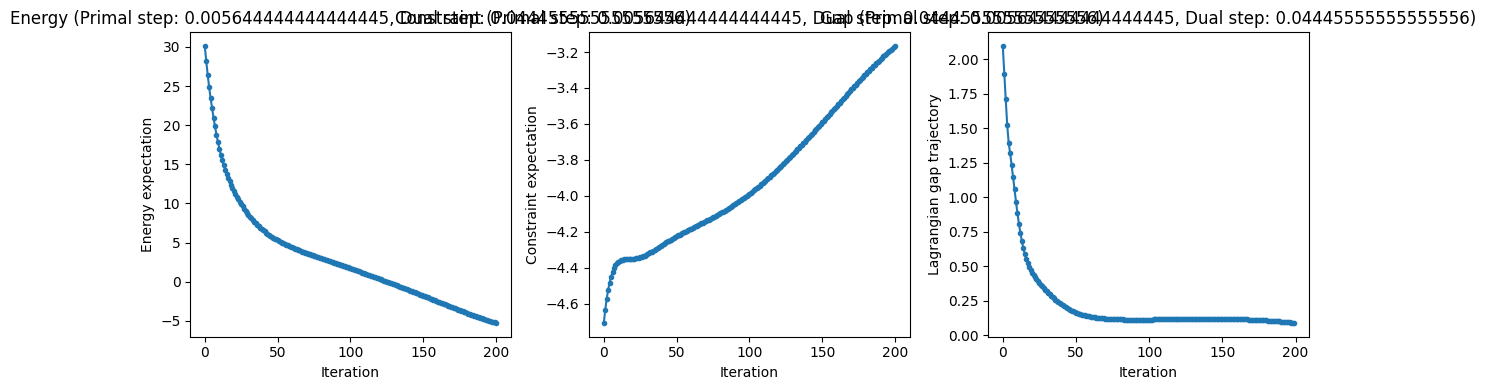

Sample 0: 100110111 with probability 0.1752 and energy -7.260000000000003
Sample 1: 100111000 with probability 0.1649 and energy -7.260000000000001
Sample 2: 100001101 with probability 0.1173 and energy -7.260000000000007
Sample 3: 100000010 with probability 0.1078 and energy -7.260000000000005
Sample 4: 100001001 with probability 0.0914 and energy -11.780000000000001
Testing primal_perturb_step=0.005644444444444445, dual_perturb_step=0.05


100%|██████████| 200/200 [03:09<00:00,  1.05it/s]


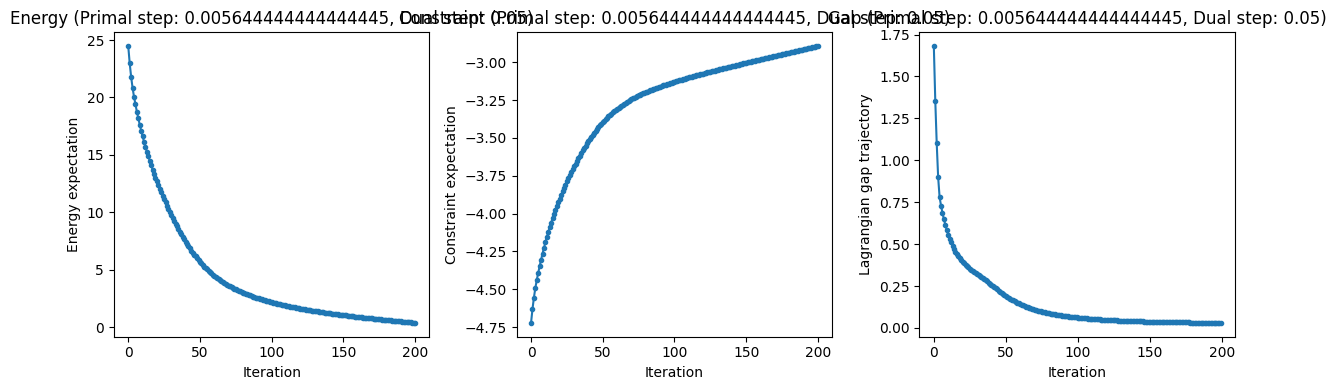

Sample 0: 000110110 with probability 0.2016 and energy -3.552713678800501e-15
Sample 1: 100011011 with probability 0.1192 and energy -7.260000000000005
Sample 2: 000110001 with probability 0.0733 and energy 0.0
Sample 3: 100011100 with probability 0.0487 and energy 2.7399999999999918
Sample 4: 100011010 with probability 0.0428 and energy -7.2600000000000104
Testing primal_perturb_step=0.011188888888888889, dual_perturb_step=0.0001


100%|██████████| 200/200 [03:06<00:00,  1.07it/s]


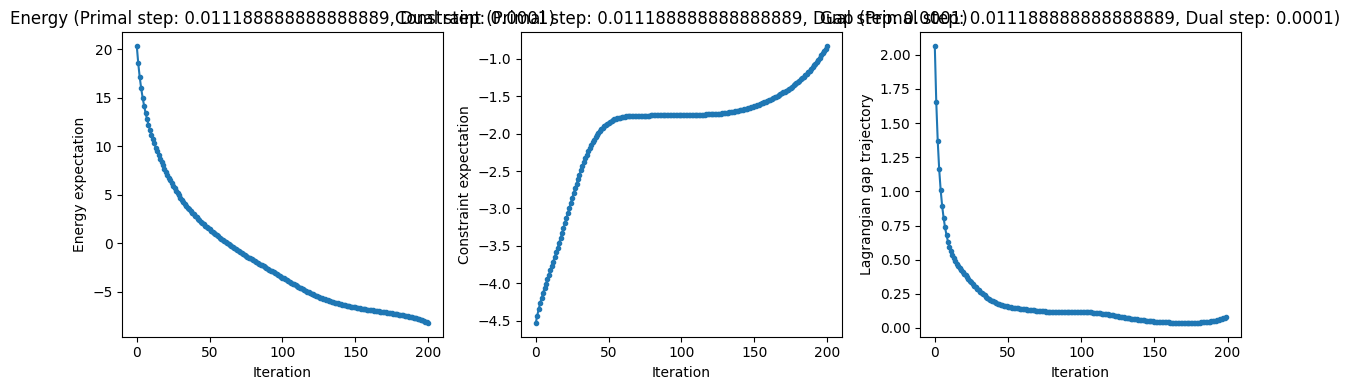

Sample 0: 001111110 with probability 0.5886 and energy -7.369999999999976
Sample 1: 101111110 with probability 0.1889 and energy -14.62999999999998
Sample 2: 001110110 with probability 0.141 and energy -7.370000000000001
Sample 3: 101110110 with probability 0.0491 and energy -0.11000000000000298
Sample 4: 001101110 with probability 0.0064 and energy 2.6299999999999972
Testing primal_perturb_step=0.011188888888888889, dual_perturb_step=0.005644444444444445


100%|██████████| 200/200 [03:07<00:00,  1.07it/s]


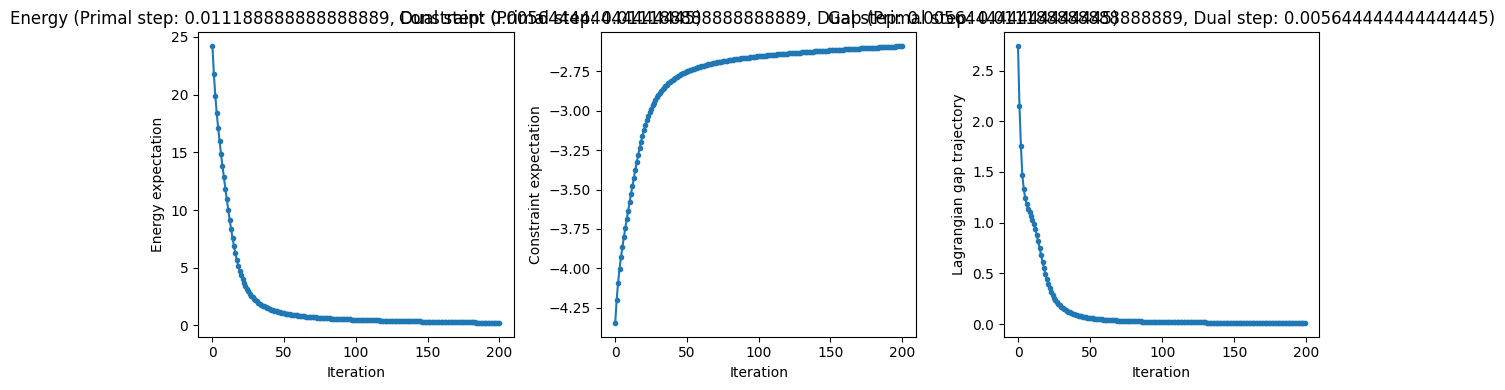

Sample 0: 000101010 with probability 0.4555 and energy -7.105427357601002e-15
Sample 1: 000101000 with probability 0.1815 and energy 6.661338147750939e-15
Sample 2: 000100110 with probability 0.131 and energy 5.329070518200751e-15
Sample 3: 001100110 with probability 0.0368 and energy -7.370000000000003
Sample 4: 000101011 with probability 0.036 and energy 2.6645352591003757e-15
Testing primal_perturb_step=0.011188888888888889, dual_perturb_step=0.011188888888888889


100%|██████████| 200/200 [03:07<00:00,  1.07it/s]


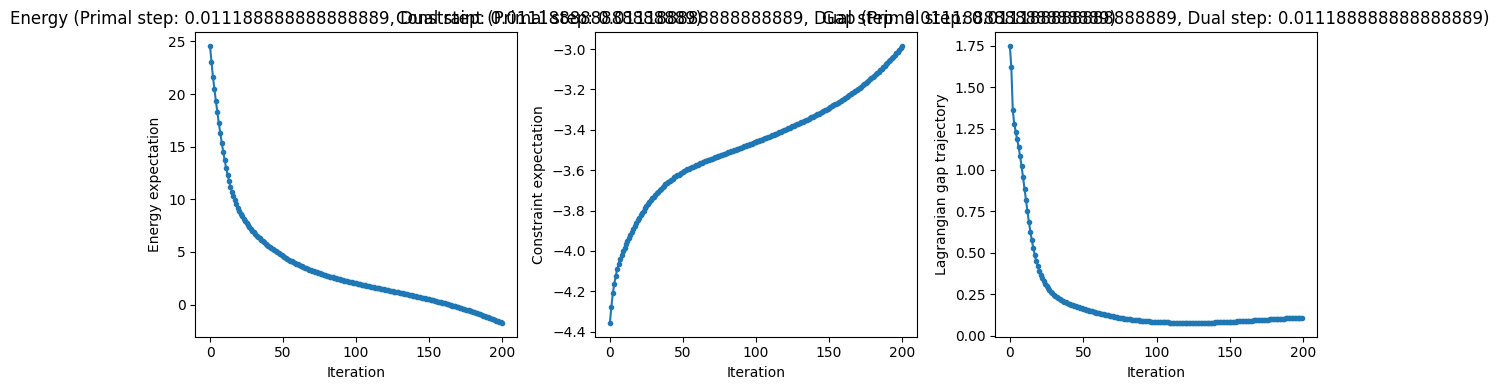

Sample 0: 001110010 with probability 0.2316 and energy -7.369999999999994
Sample 1: 000001000 with probability 0.2244 and energy -1.7763568394002505e-15
Sample 2: 001110110 with probability 0.1453 and energy -7.370000000000001
Sample 3: 000001100 with probability 0.0593 and energy -8.881784197001252e-15
Sample 4: 000101000 with probability 0.0507 and energy 6.661338147750939e-15
Testing primal_perturb_step=0.011188888888888889, dual_perturb_step=0.016733333333333333


100%|██████████| 200/200 [03:10<00:00,  1.05it/s]


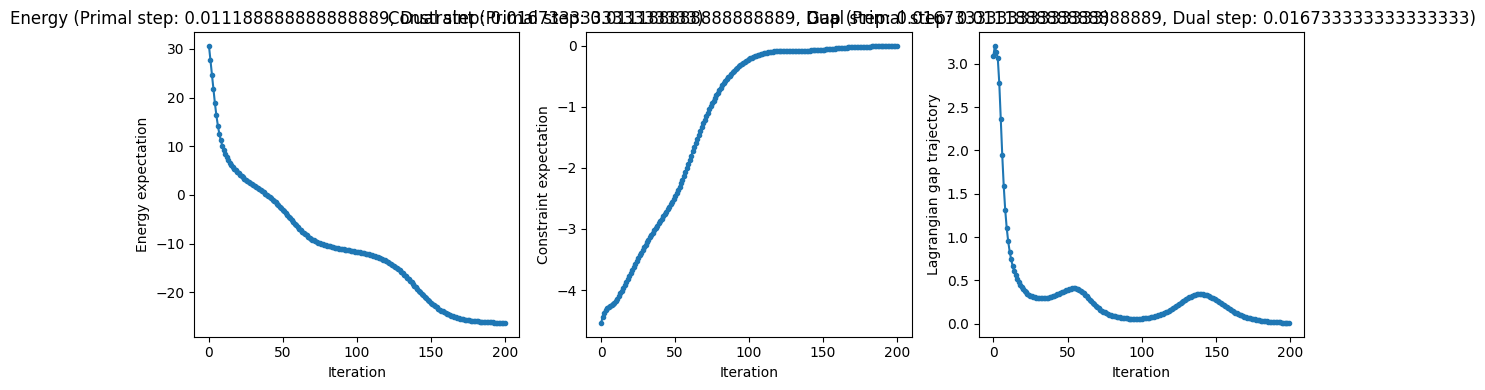

Sample 0: 111000110 with probability 0.9869 and energy -26.430000000000014
Sample 1: 110000110 with probability 0.0105 and energy -19.060000000000016
Sample 2: 011000110 with probability 0.0008 and energy -4.6500000000000075
Sample 3: 111011110 with probability 0.0005 and energy -11.909999999999998
Sample 4: 101000110 with probability 0.0003 and energy -19.150000000000006
Testing primal_perturb_step=0.011188888888888889, dual_perturb_step=0.02227777777777778


100%|██████████| 200/200 [03:41<00:00,  1.11s/it]


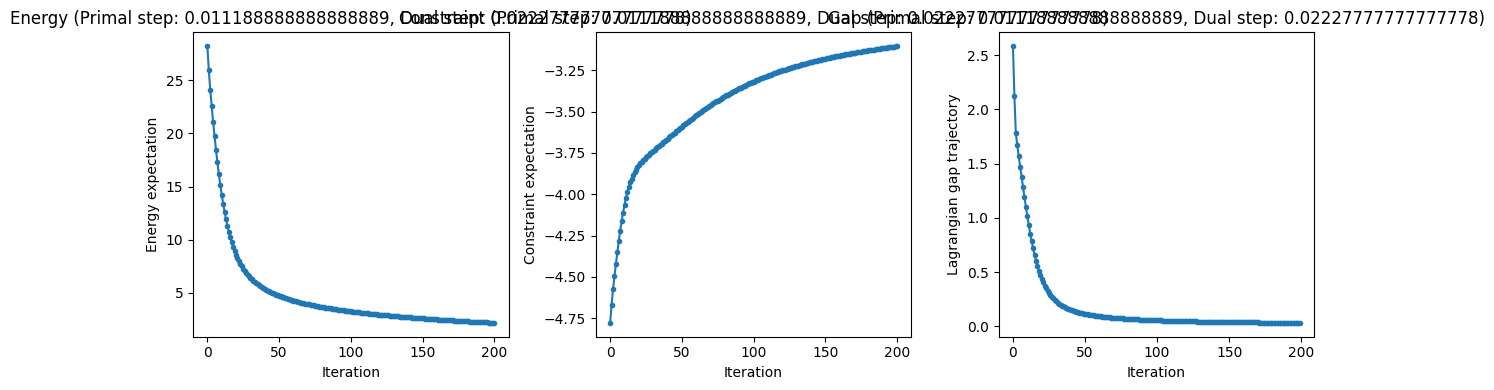

Sample 0: 000101011 with probability 0.0805 and energy 2.6645352591003757e-15
Sample 1: 000011011 with probability 0.0771 and energy -5.773159728050814e-15
Sample 2: 000011010 with probability 0.0459 and energy -1.4210854715202004e-14
Sample 3: 000000111 with probability 0.037 and energy 1.7763568394002505e-15
Sample 4: 000110101 with probability 0.037 and energy -1.7763568394002505e-15
Testing primal_perturb_step=0.011188888888888889, dual_perturb_step=0.027822222222222224


100%|██████████| 200/200 [03:34<00:00,  1.07s/it]


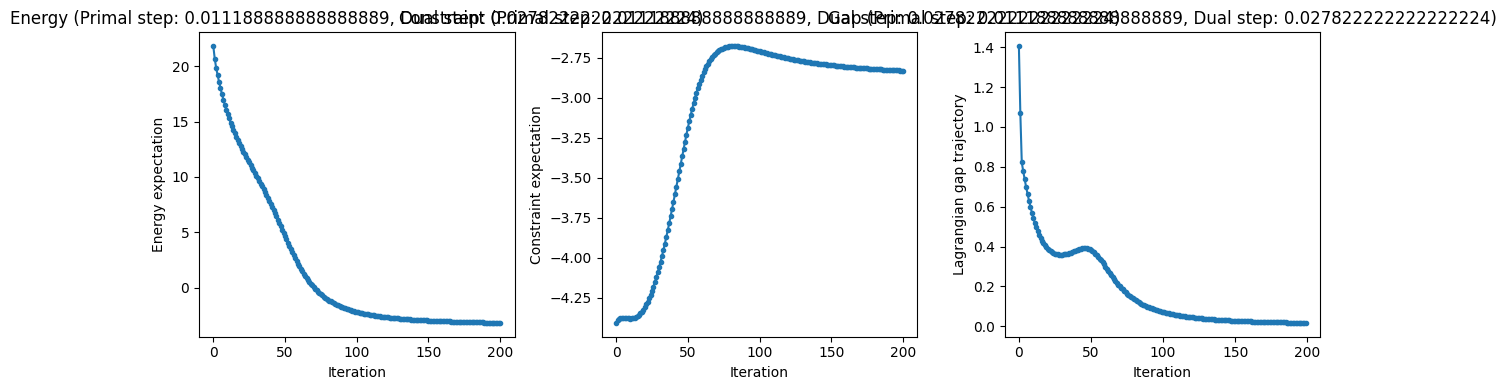

Sample 0: 001001110 with probability 0.2132 and energy -7.36999999999999
Sample 1: 001010110 with probability 0.2128 and energy -7.370000000000006
Sample 2: 000111110 with probability 0.1852 and energy 7.105427357601002e-15
Sample 3: 000100110 with probability 0.1657 and energy 5.329070518200751e-15
Sample 4: 000110011 with probability 0.0527 and energy 8.881784197001252e-16
Testing primal_perturb_step=0.011188888888888889, dual_perturb_step=0.03336666666666667


100%|██████████| 200/200 [03:14<00:00,  1.03it/s]


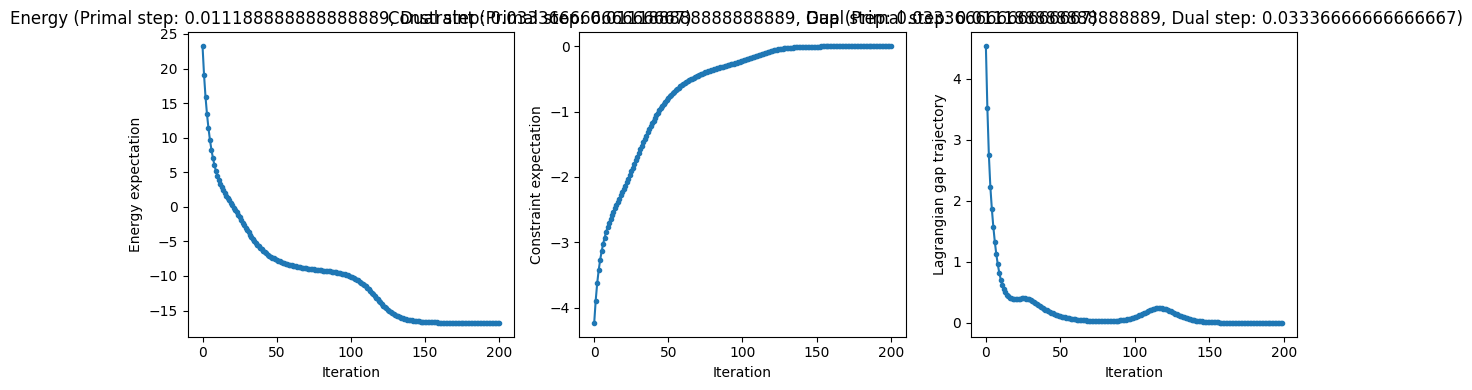

Sample 0: 110101011 with probability 0.506 and energy -14.540000000000003
Sample 1: 110111111 with probability 0.4938 and energy -19.059999999999988
Sample 2: 110110011 with probability 0.0002 and energy -0.020000000000007567
Testing primal_perturb_step=0.011188888888888889, dual_perturb_step=0.03891111111111112


100%|██████████| 200/200 [03:32<00:00,  1.06s/it]


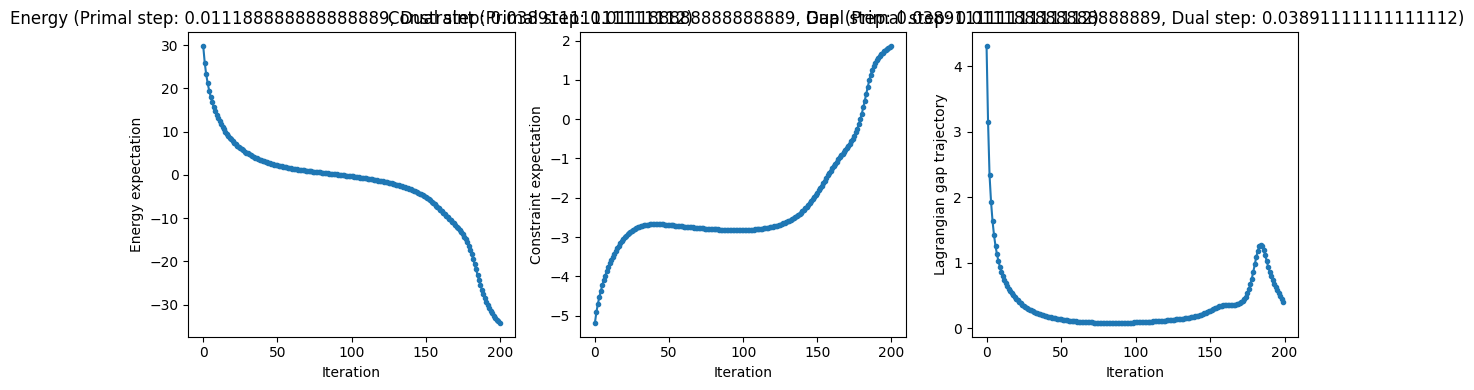

Sample 0: 111011010 with probability 0.846 and energy -36.46999999999999
Sample 1: 011011010 with probability 0.0962 and energy -29.209999999999994
Sample 2: 110011010 with probability 0.0137 and energy -29.100000000000012
Sample 3: 101011010 with probability 0.0112 and energy -14.629999999999994
Sample 4: 100110111 with probability 0.0079 and energy -7.260000000000003
Testing primal_perturb_step=0.011188888888888889, dual_perturb_step=0.04445555555555556


100%|██████████| 200/200 [03:32<00:00,  1.06s/it]


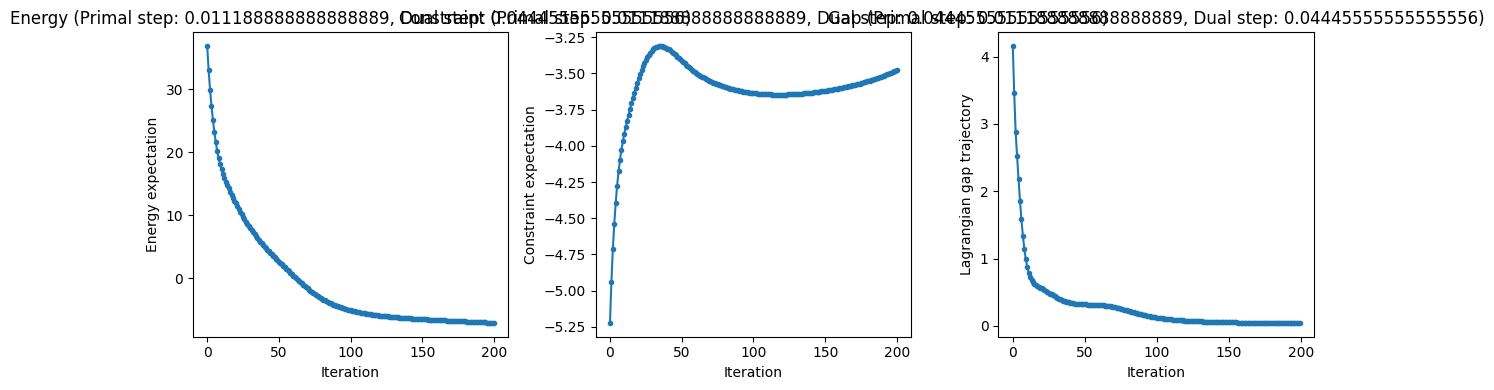

Sample 0: 100000010 with probability 0.3648 and energy -7.260000000000005
Sample 1: 100001000 with probability 0.3497 and energy -7.260000000000002
Sample 2: 100001001 with probability 0.0716 and energy -11.780000000000001
Sample 3: 100000110 with probability 0.0511 and energy -11.780000000000006
Sample 4: 100000111 with probability 0.0501 and energy -7.260000000000001
Testing primal_perturb_step=0.011188888888888889, dual_perturb_step=0.05


100%|██████████| 200/200 [03:27<00:00,  1.04s/it]


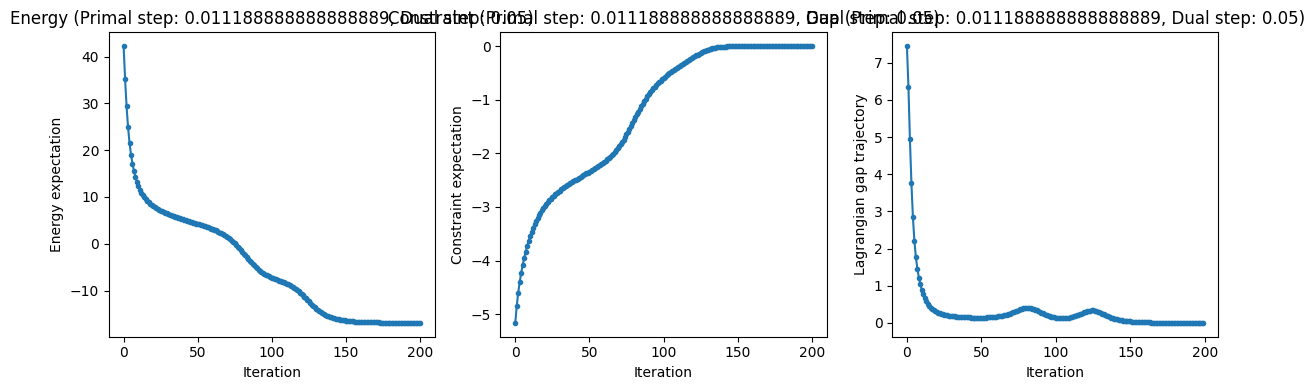

Sample 0: 110001001 with probability 0.2932 and energy -19.059999999999995
Sample 1: 110000110 with probability 0.2545 and energy -19.060000000000016
Sample 2: 110111110 with probability 0.2384 and energy -14.54
Sample 3: 110110001 with probability 0.1998 and energy -14.54
Sample 4: 100000110 with probability 0.0042 and energy -11.780000000000006
Testing primal_perturb_step=0.016733333333333333, dual_perturb_step=0.0001


100%|██████████| 200/200 [03:30<00:00,  1.05s/it]


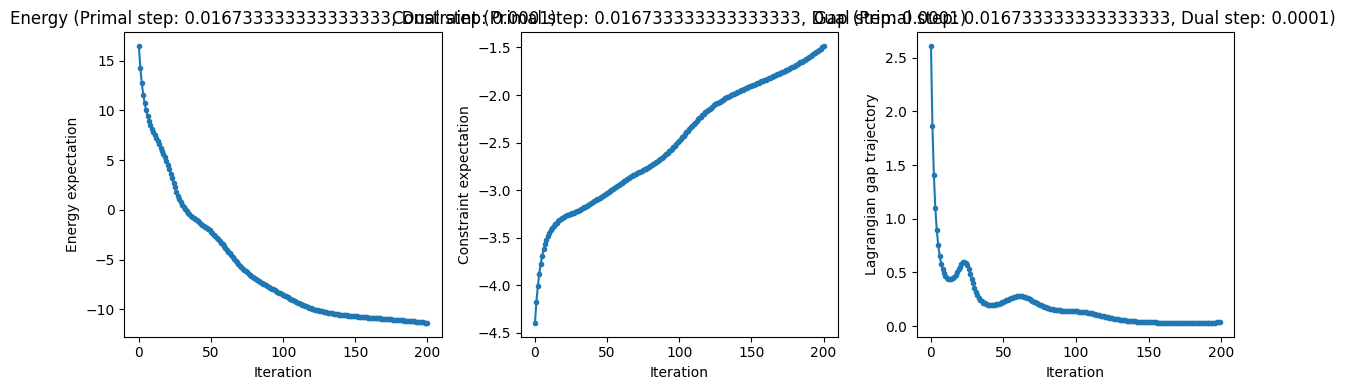

Sample 0: 100001001 with probability 0.2753 and energy -11.780000000000001
Sample 1: 101111110 with probability 0.2392 and energy -14.62999999999998
Sample 2: 101100110 with probability 0.2136 and energy -14.63
Sample 3: 100001101 with probability 0.1219 and energy -7.260000000000007
Sample 4: 100010101 with probability 0.0728 and energy -7.2600000000000104
Testing primal_perturb_step=0.016733333333333333, dual_perturb_step=0.005644444444444445


 60%|██████    | 121/200 [02:09<01:24,  1.07s/it]

Converged after 122 iterations


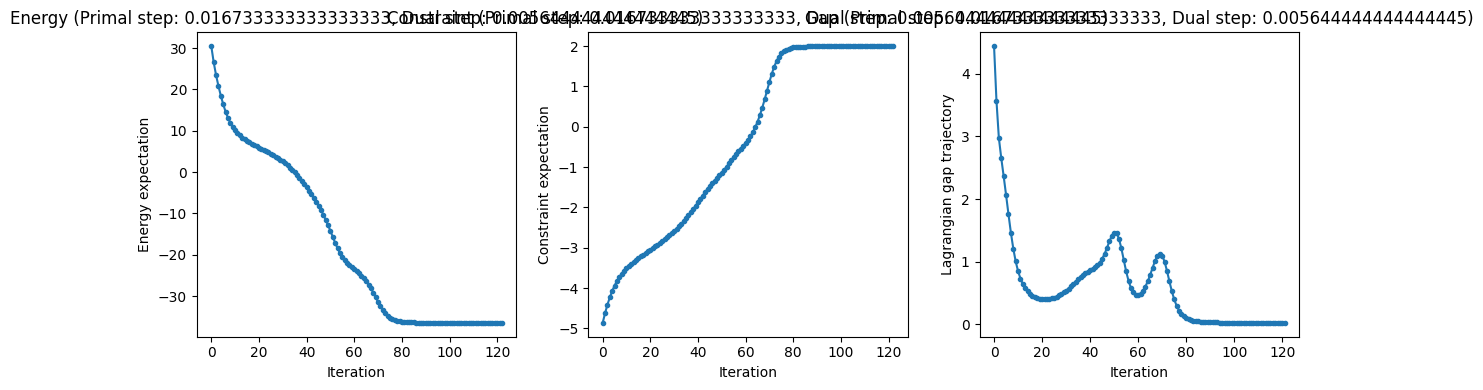

Sample 0: 111011010 with probability 0.9996 and energy -36.46999999999999
Sample 1: 011011010 with probability 0.0002 and energy -29.209999999999994
Sample 2: 110011010 with probability 0.0001 and energy -29.100000000000012
Sample 3: 111011001 with probability 0.0001 and energy 80.29
Testing primal_perturb_step=0.016733333333333333, dual_perturb_step=0.011188888888888889


 82%|████████▏ | 164/200 [03:08<00:41,  1.15s/it]

Converged after 165 iterations


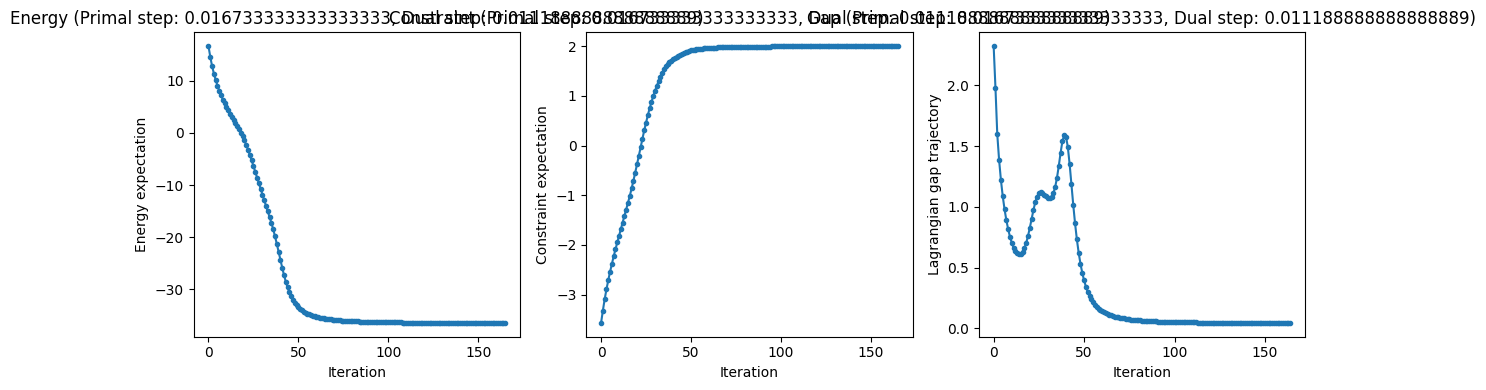

Sample 0: 111011010 with probability 0.9987 and energy -36.46999999999999
Sample 1: 011111110 with probability 0.0004 and energy -14.649999999999986
Sample 2: 111111110 with probability 0.0003 and energy -21.90999999999999
Found '111111110' with energy -21.9 and probability 0.0003
Testing primal_perturb_step=0.016733333333333333, dual_perturb_step=0.016733333333333333


100%|██████████| 200/200 [03:48<00:00,  1.14s/it]


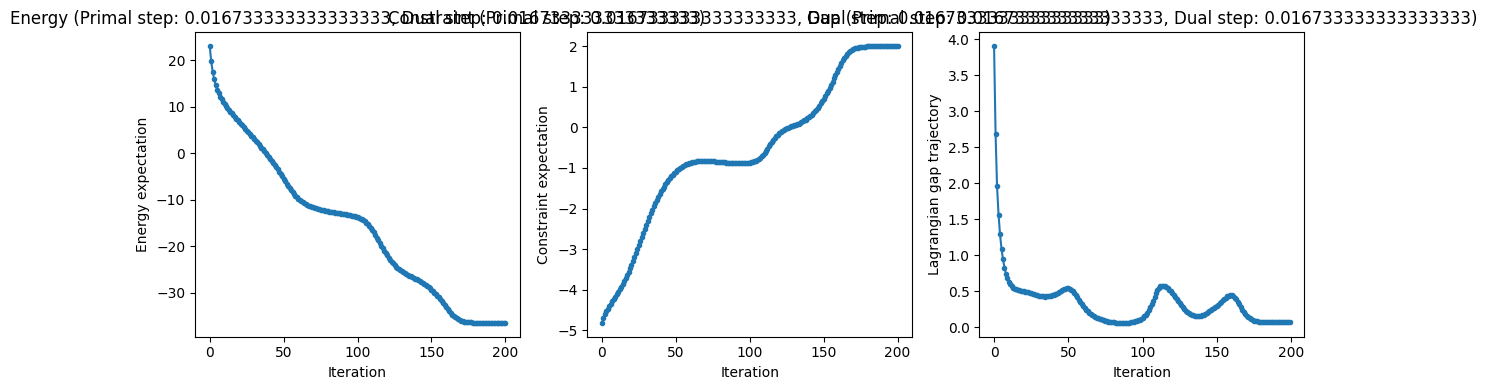

Sample 0: 111011010 with probability 0.9993 and energy -36.46999999999999
Sample 1: 001011010 with probability 0.0002 and energy -7.369999999999997
Sample 2: 111001010 with probability 0.0002 and energy 50.769999999999996
Sample 3: 010110110 with probability 0.0001 and energy 21.839999999999996
Sample 4: 011011010 with probability 0.0001 and energy -29.209999999999994
Testing primal_perturb_step=0.016733333333333333, dual_perturb_step=0.02227777777777778


100%|██████████| 200/200 [03:32<00:00,  1.06s/it]


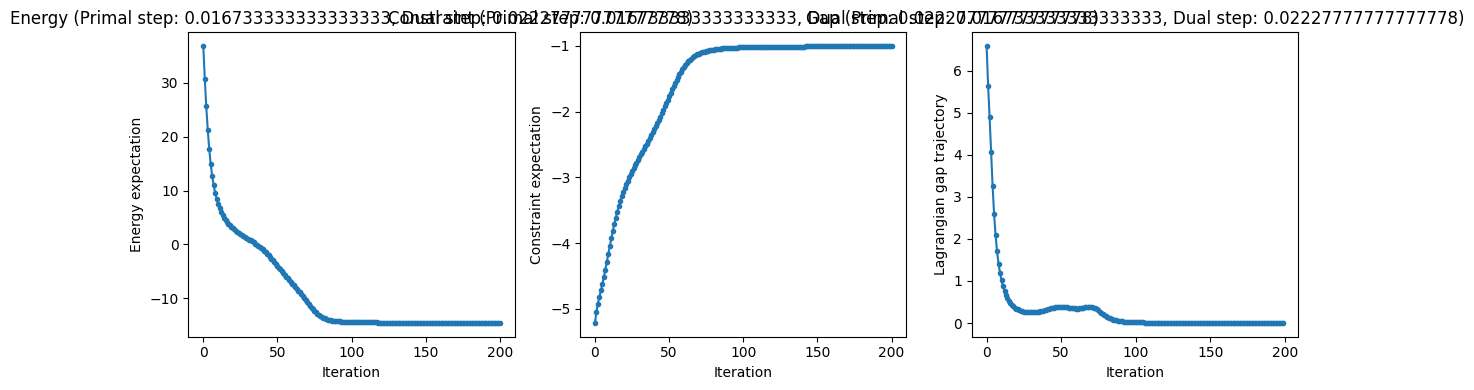

Sample 0: 101011010 with probability 0.5032 and energy -14.629999999999994
Sample 1: 101000010 with probability 0.4915 and energy -14.630000000000003
Sample 2: 101000110 with probability 0.0012 and energy -19.150000000000006
Sample 3: 000100011 with probability 0.0004 and energy 10.000000000000009
Sample 4: 100000010 with probability 0.0004 and energy -7.260000000000005
Testing primal_perturb_step=0.016733333333333333, dual_perturb_step=0.027822222222222224


100%|██████████| 200/200 [03:31<00:00,  1.06s/it]


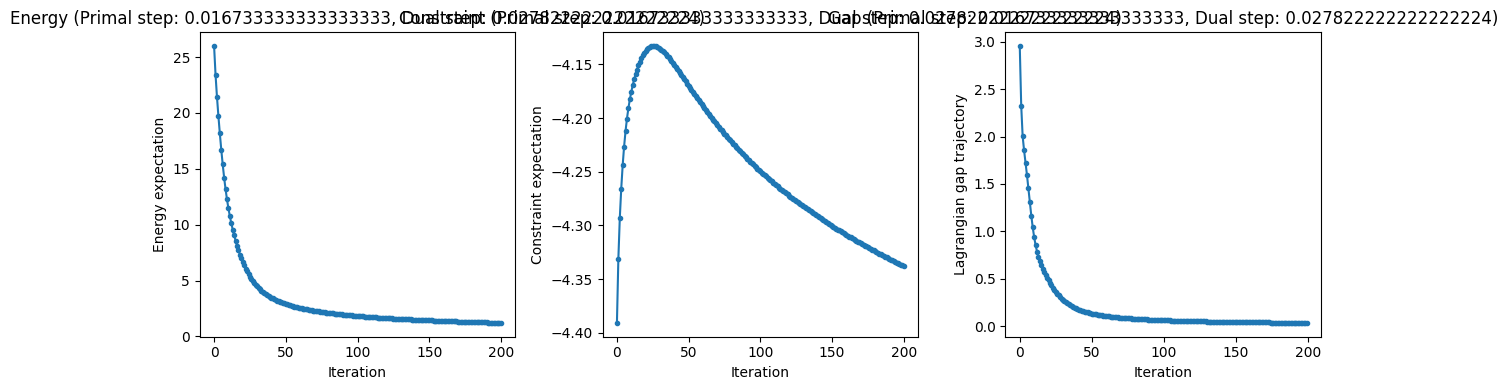

Sample 0: 000110110 with probability 0.0951 and energy -3.552713678800501e-15
Sample 1: 000110011 with probability 0.0734 and energy 8.881784197001252e-16
Sample 2: 000111101 with probability 0.0686 and energy -1.5987211554602254e-14
Sample 3: 000000100 with probability 0.0546 and energy -1.0658141036401503e-14
Sample 4: 000111010 with probability 0.0545 and energy -4.884981308350689e-15
Testing primal_perturb_step=0.016733333333333333, dual_perturb_step=0.03336666666666667


100%|██████████| 200/200 [03:31<00:00,  1.06s/it]


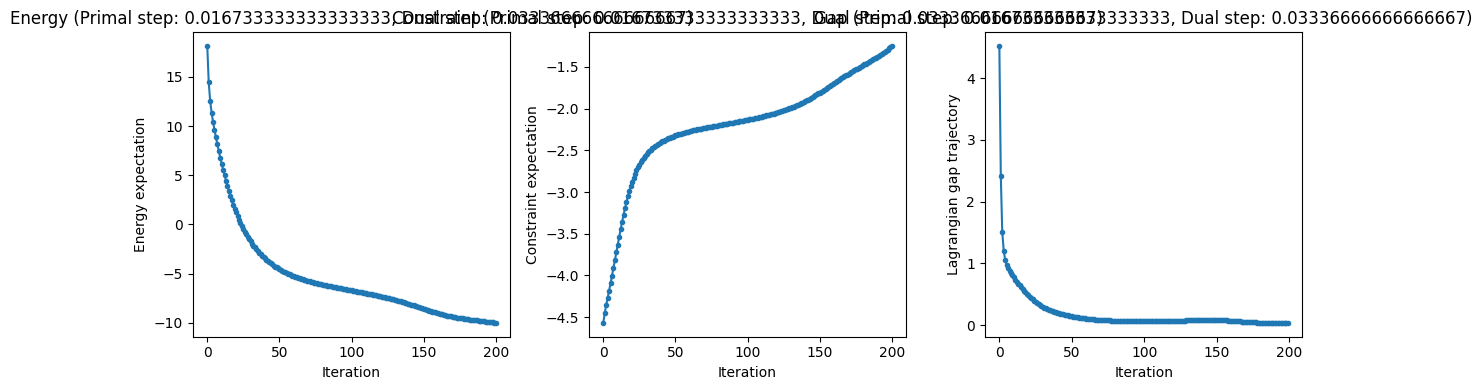

Sample 0: 100110000 with probability 0.6516 and energy -11.779999999999998
Sample 1: 100101000 with probability 0.3025 and energy -7.259999999999996
Sample 2: 100110001 with probability 0.0115 and energy -7.259999999999998
Sample 3: 100100110 with probability 0.0065 and energy -7.259999999999993
Sample 4: 100101001 with probability 0.0042 and energy -7.259999999999991
Testing primal_perturb_step=0.016733333333333333, dual_perturb_step=0.03891111111111112


 66%|██████▌   | 131/200 [02:17<01:12,  1.05s/it]

Converged after 132 iterations


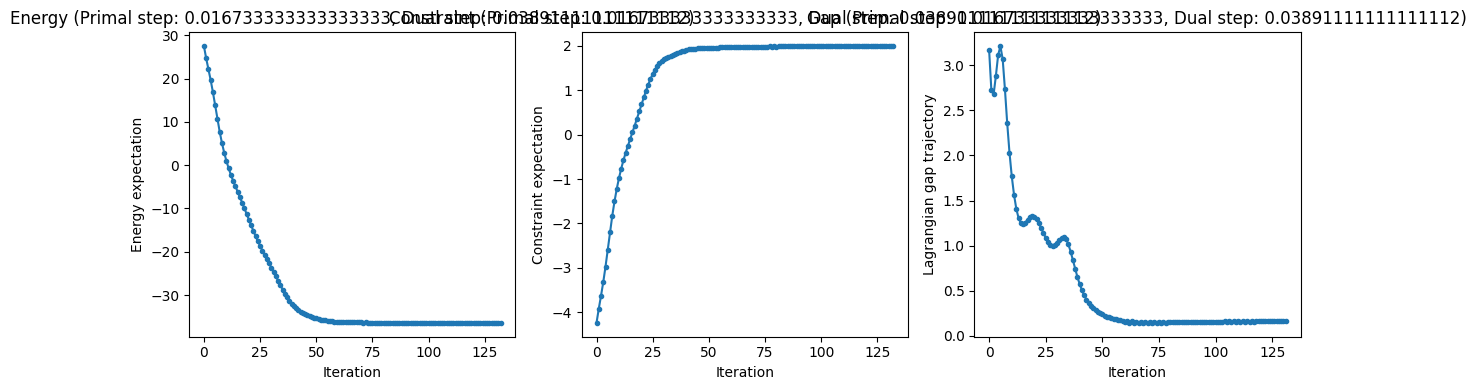

Sample 0: 111011010 with probability 0.9992 and energy -36.46999999999999
Sample 1: 100100000 with probability 0.0007 and energy 2.740000000000004
Sample 2: 111100000 with probability 0.0001 and energy 75.99
Testing primal_perturb_step=0.016733333333333333, dual_perturb_step=0.04445555555555556


100%|██████████| 200/200 [03:29<00:00,  1.05s/it]


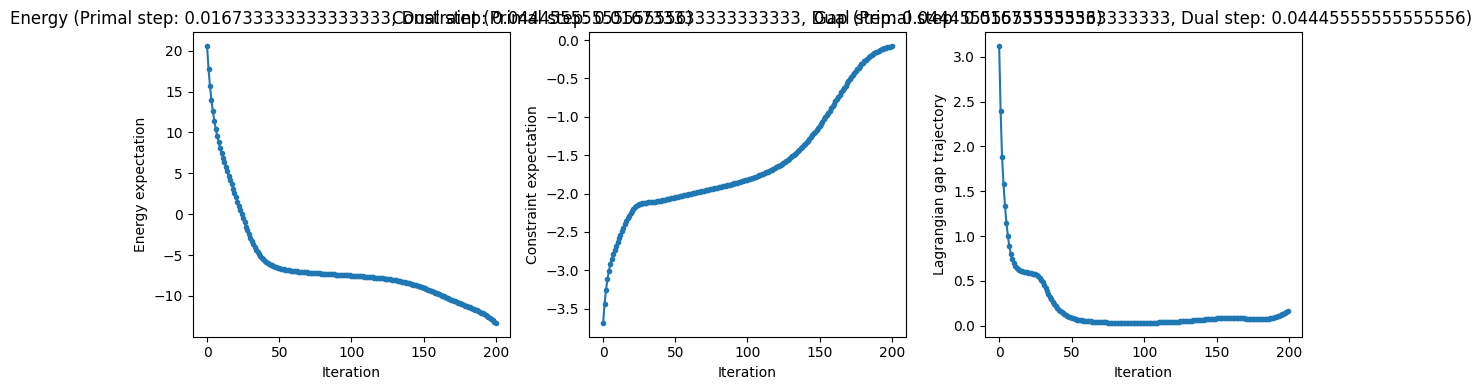

Sample 0: 100001001 with probability 0.3539 and energy -11.780000000000001
Sample 1: 100000110 with probability 0.3489 and energy -11.780000000000006
Sample 2: 110001001 with probability 0.1303 and energy -19.059999999999995
Sample 3: 110000110 with probability 0.1212 and energy -19.060000000000016
Sample 4: 100010101 with probability 0.0148 and energy -7.2600000000000104
Testing primal_perturb_step=0.016733333333333333, dual_perturb_step=0.05


100%|██████████| 200/200 [03:30<00:00,  1.05s/it]


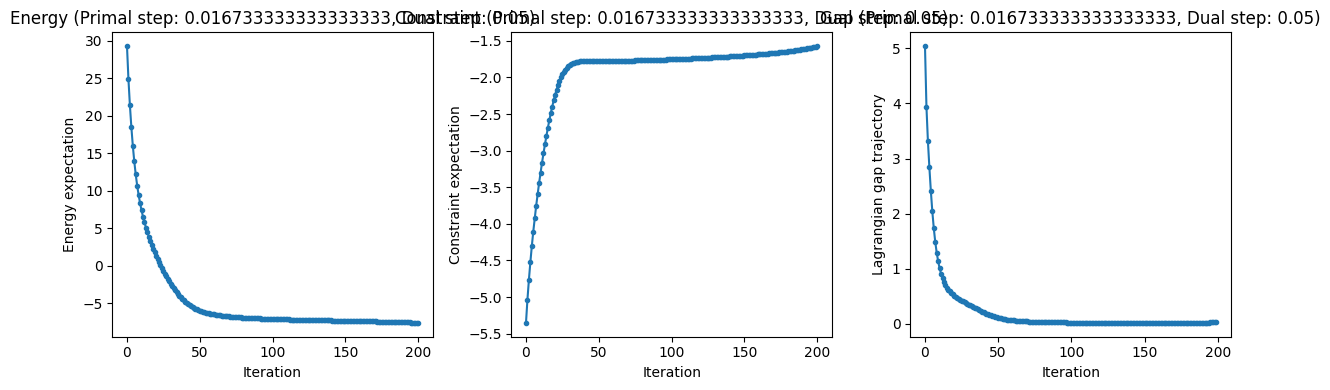

Sample 0: 110110001 with probability 0.1466 and energy -14.54
Sample 1: 110111110 with probability 0.1438 and energy -14.54
Sample 2: 100010101 with probability 0.1214 and energy -7.2600000000000104
Sample 3: 100011010 with probability 0.1178 and energy -7.2600000000000104
Sample 4: 110101001 with probability 0.1002 and energy 0.020000000000010232
Testing primal_perturb_step=0.02227777777777778, dual_perturb_step=0.0001


100%|██████████| 200/200 [03:29<00:00,  1.05s/it]


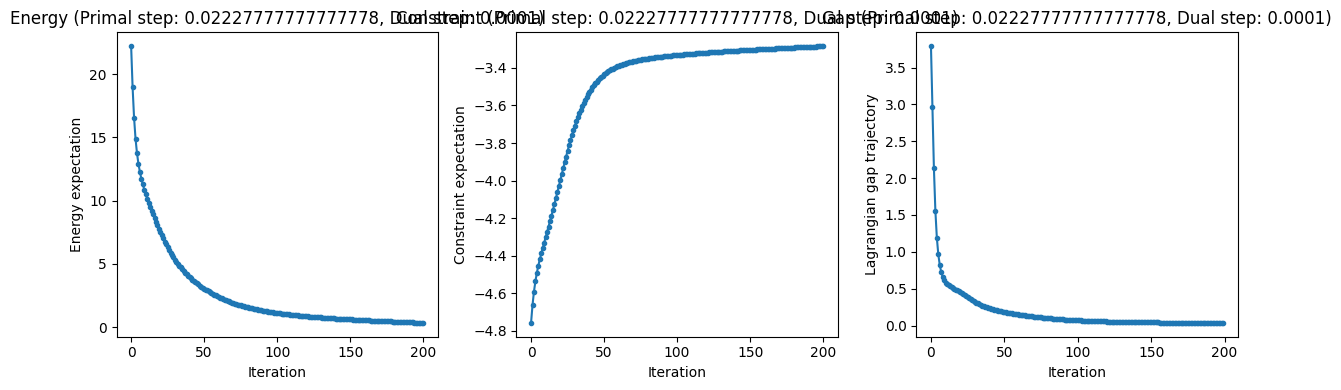

Sample 0: 000110110 with probability 0.1109 and energy -3.552713678800501e-15
Sample 1: 000100110 with probability 0.0713 and energy 5.329070518200751e-15
Sample 2: 000111010 with probability 0.0712 and energy -4.884981308350689e-15
Sample 3: 000110111 with probability 0.071 and energy -1.7763568394002505e-15
Sample 4: 000010111 with probability 0.063 and energy -7.105427357601002e-15
Testing primal_perturb_step=0.02227777777777778, dual_perturb_step=0.005644444444444445


100%|██████████| 200/200 [03:31<00:00,  1.06s/it]


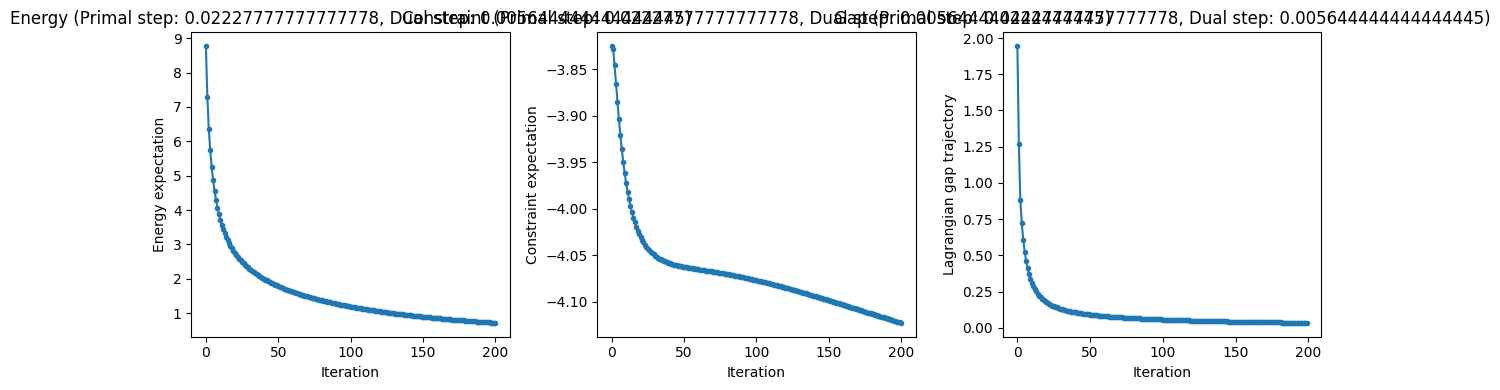

Sample 0: 000110110 with probability 0.2362 and energy -3.552713678800501e-15
Sample 1: 000011010 with probability 0.0975 and energy -1.4210854715202004e-14
Sample 2: 000110100 with probability 0.0851 and energy -7.105427357601002e-15
Sample 3: 000111000 with probability 0.0648 and energy 8.881784197001252e-16
Sample 4: 000110101 with probability 0.0575 and energy -1.7763568394002505e-15
Testing primal_perturb_step=0.02227777777777778, dual_perturb_step=0.011188888888888889


100%|██████████| 200/200 [03:25<00:00,  1.03s/it]


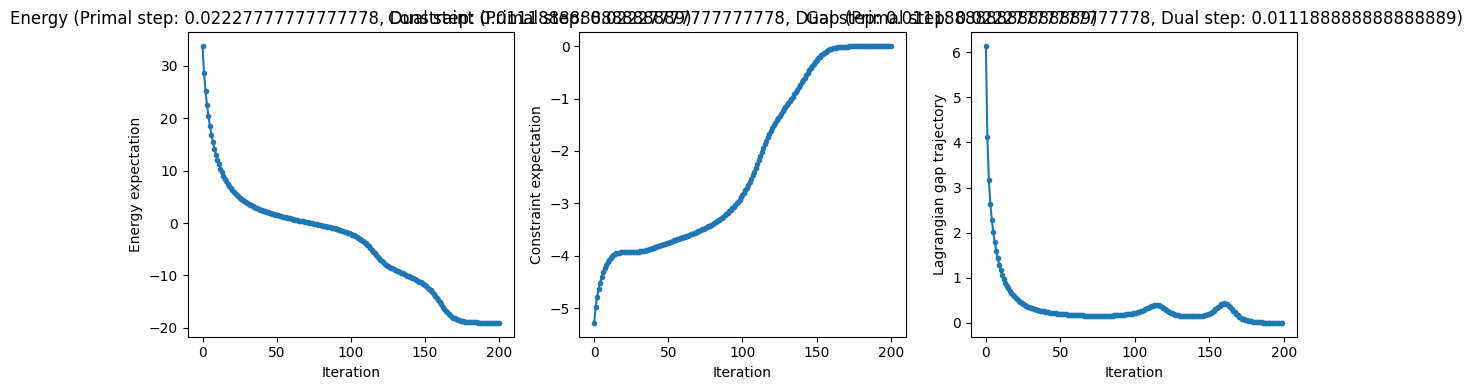

Sample 0: 110111111 with probability 0.5029 and energy -19.059999999999988
Sample 1: 110001001 with probability 0.495 and energy -19.059999999999995
Sample 2: 100001001 with probability 0.0012 and energy -11.780000000000001
Sample 3: 100111111 with probability 0.0007 and energy -11.779999999999992
Sample 4: 100110001 with probability 0.0002 and energy -7.259999999999998
Testing primal_perturb_step=0.02227777777777778, dual_perturb_step=0.016733333333333333


100%|██████████| 200/200 [03:29<00:00,  1.05s/it]


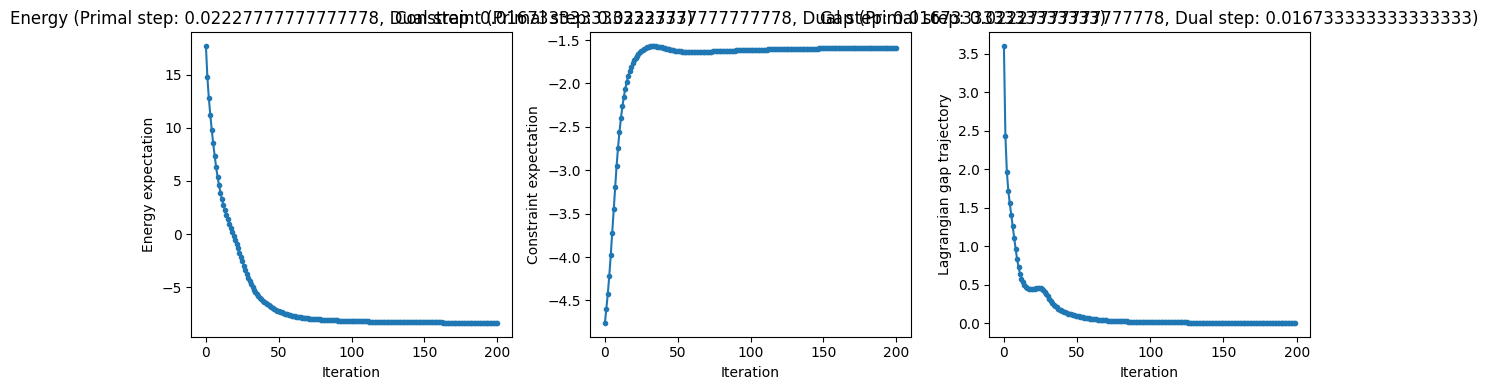

Sample 0: 100111111 with probability 0.286 and energy -11.779999999999992
Sample 1: 100010101 with probability 0.2484 and energy -7.2600000000000104
Sample 2: 100110001 with probability 0.2056 and energy -7.259999999999998
Sample 3: 100011011 with probability 0.1995 and energy -7.260000000000005
Sample 4: 100110000 with probability 0.0223 and energy -11.779999999999998
Testing primal_perturb_step=0.02227777777777778, dual_perturb_step=0.02227777777777778


100%|██████████| 200/200 [03:32<00:00,  1.06s/it]


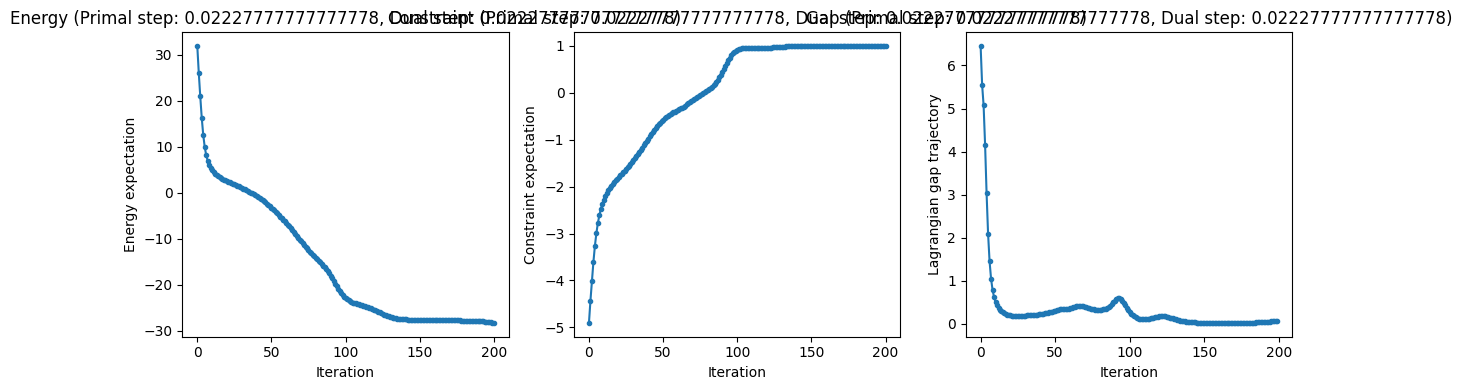

Sample 0: 111011010 with probability 0.4941 and energy -36.46999999999999
Sample 1: 110111111 with probability 0.4112 and energy -19.059999999999988
Sample 2: 111000110 with probability 0.0918 and energy -26.430000000000014
Sample 3: 111000111 with probability 0.0023 and energy 21.949999999999996
Sample 4: 000100011 with probability 0.0002 and energy 10.000000000000009
Testing primal_perturb_step=0.02227777777777778, dual_perturb_step=0.027822222222222224


 50%|█████     | 100/200 [01:44<01:44,  1.05s/it]

Gap closed after 101 iterations; VQEC converged.


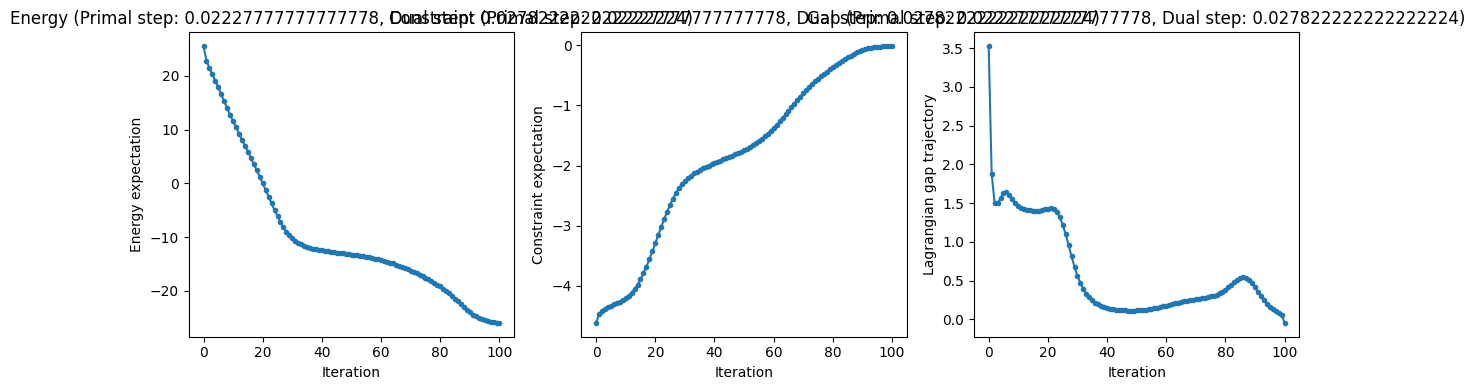

Sample 0: 111000110 with probability 0.9626 and energy -26.430000000000014
Sample 1: 101000110 with probability 0.0246 and energy -19.150000000000006
Sample 2: 110000110 with probability 0.0063 and energy -19.060000000000016
Sample 3: 001000110 with probability 0.0023 and energy 2.6300000000000026
Sample 4: 000101000 with probability 0.0018 and energy 6.661338147750939e-15
Testing primal_perturb_step=0.02227777777777778, dual_perturb_step=0.03336666666666667


100%|██████████| 200/200 [03:26<00:00,  1.03s/it]


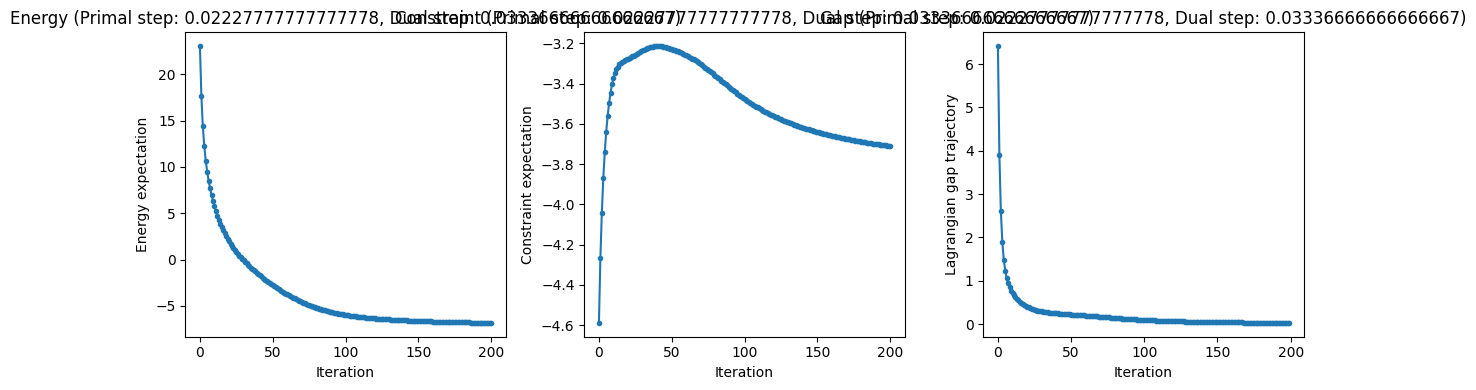

Sample 0: 001110110 with probability 0.2445 and energy -7.370000000000001
Sample 1: 001001010 with probability 0.1986 and energy -7.370000000000001
Sample 2: 001010110 with probability 0.1511 and energy -7.370000000000006
Sample 3: 001001110 with probability 0.1266 and energy -7.36999999999999
Sample 4: 001000010 with probability 0.0779 and energy -7.370000000000003
Testing primal_perturb_step=0.02227777777777778, dual_perturb_step=0.03891111111111112


100%|██████████| 200/200 [03:39<00:00,  1.10s/it]


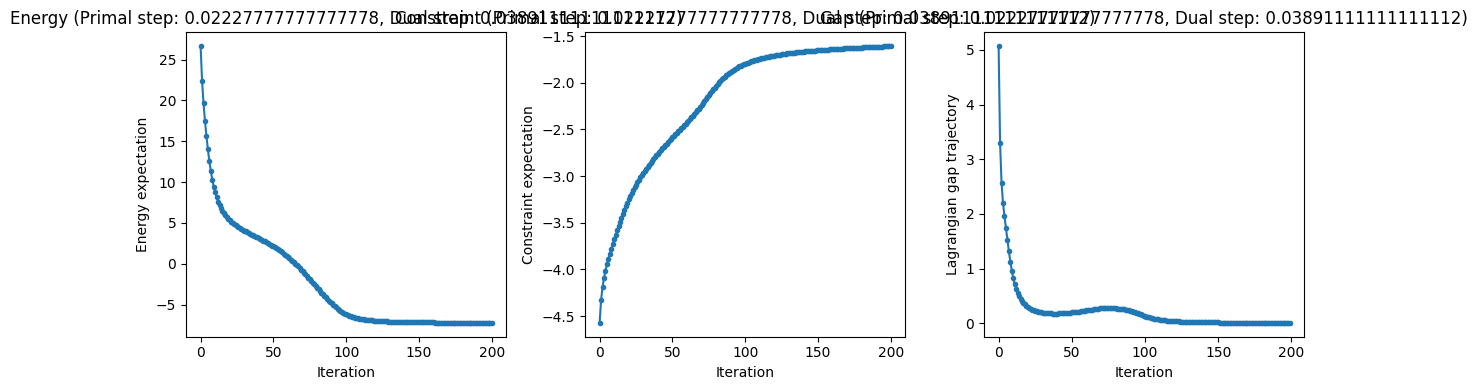

Sample 0: 001000010 with probability 0.316 and energy -7.370000000000003
Sample 1: 001110010 with probability 0.2809 and energy -7.369999999999994
Sample 2: 001111010 with probability 0.2486 and energy -7.369999999999996
Sample 3: 001100110 with probability 0.0325 and energy -7.370000000000003
Sample 4: 001001010 with probability 0.0264 and energy -7.370000000000001
Testing primal_perturb_step=0.02227777777777778, dual_perturb_step=0.04445555555555556


100%|██████████| 200/200 [03:29<00:00,  1.05s/it]


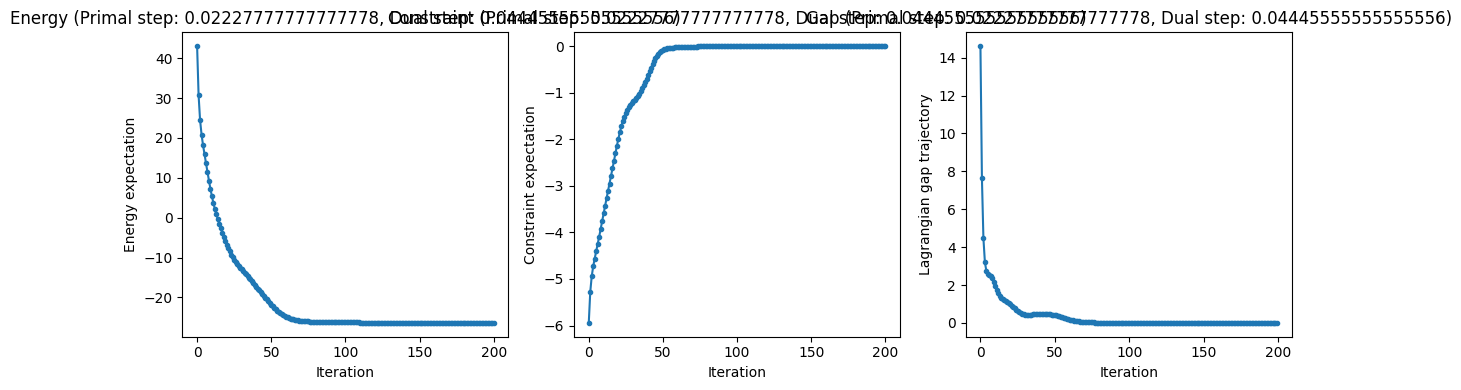

Sample 0: 111000110 with probability 0.9983 and energy -26.430000000000014
Sample 1: 101000110 with probability 0.0015 and energy -19.150000000000006
Sample 2: 000101110 with probability 0.0001 and energy 9.999999999999998
Sample 3: 001000110 with probability 0.0001 and energy 2.6300000000000026
Testing primal_perturb_step=0.02227777777777778, dual_perturb_step=0.05


100%|██████████| 200/200 [03:31<00:00,  1.06s/it]


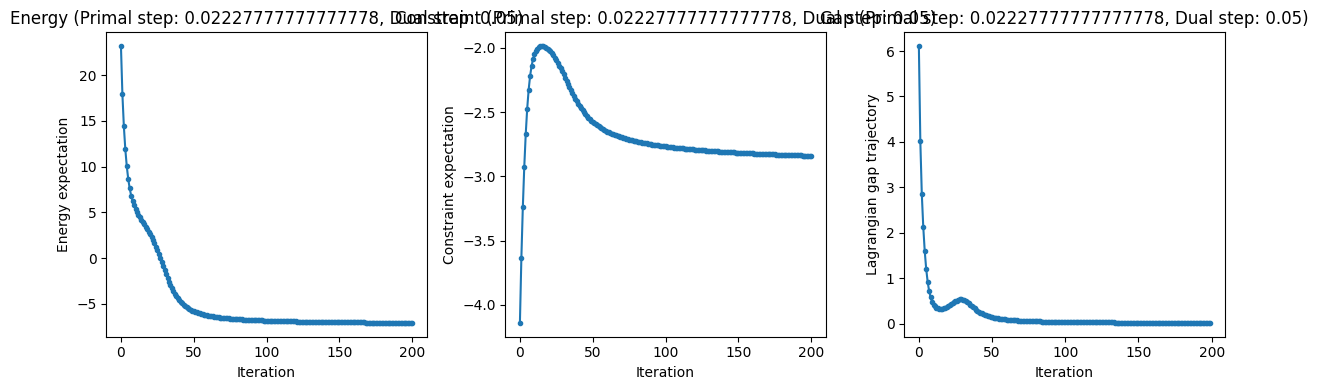

Sample 0: 001000010 with probability 0.4569 and energy -7.370000000000003
Sample 1: 001101010 with probability 0.4263 and energy -7.3700000000000045
Sample 2: 001111010 with probability 0.0358 and energy -7.369999999999996
Sample 3: 001110110 with probability 0.0189 and energy -7.370000000000001
Sample 4: 001110010 with probability 0.0118 and energy -7.369999999999994
Testing primal_perturb_step=0.027822222222222224, dual_perturb_step=0.0001


100%|██████████| 200/200 [03:31<00:00,  1.06s/it]


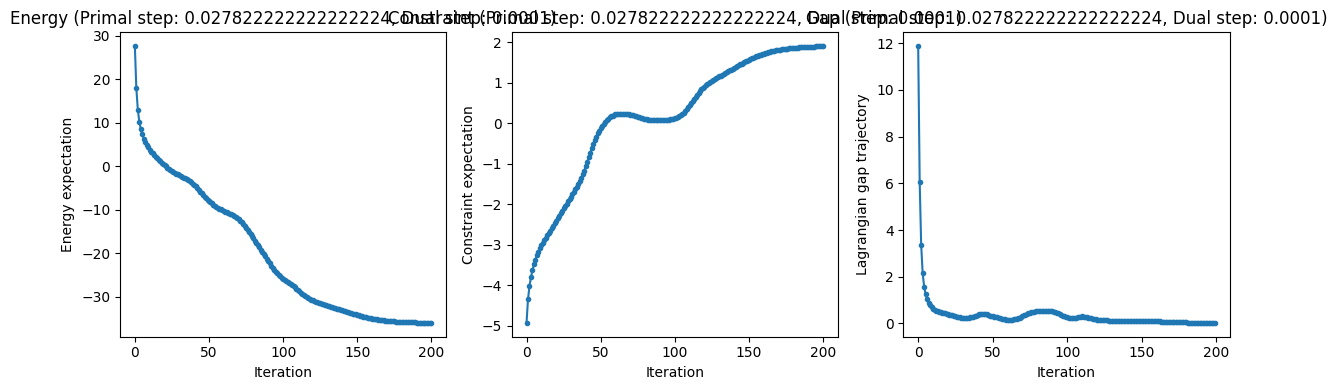

Sample 0: 111011010 with probability 0.9534 and energy -36.46999999999999
Sample 1: 111000110 with probability 0.0457 and energy -26.430000000000014
Sample 2: 111000010 with probability 0.0003 and energy 7.210000000000004
Sample 3: 000001110 with probability 0.0001 and energy 0.0
Sample 4: 100000010 with probability 0.0001 and energy -7.260000000000005
Testing primal_perturb_step=0.027822222222222224, dual_perturb_step=0.005644444444444445


100%|█████████▉| 199/200 [03:25<00:01,  1.04s/it]

Converged after 200 iterations


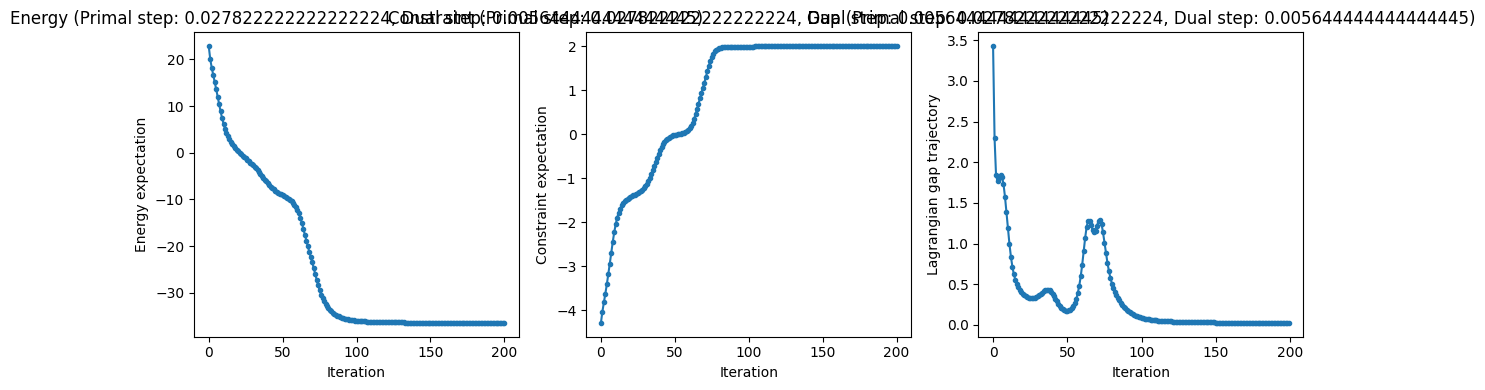

Sample 0: 111011010 with probability 0.9988 and energy -36.46999999999999
Sample 1: 110011010 with probability 0.0007 and energy -29.100000000000012
Sample 2: 110111010 with probability 0.0003 and energy -0.020000000000012452
Sample 3: 100101011 with probability 0.0001 and energy -7.26
Sample 4: 111011011 with probability 0.0001 and energy -7.17
Testing primal_perturb_step=0.027822222222222224, dual_perturb_step=0.011188888888888889


100%|██████████| 200/200 [03:30<00:00,  1.05s/it]


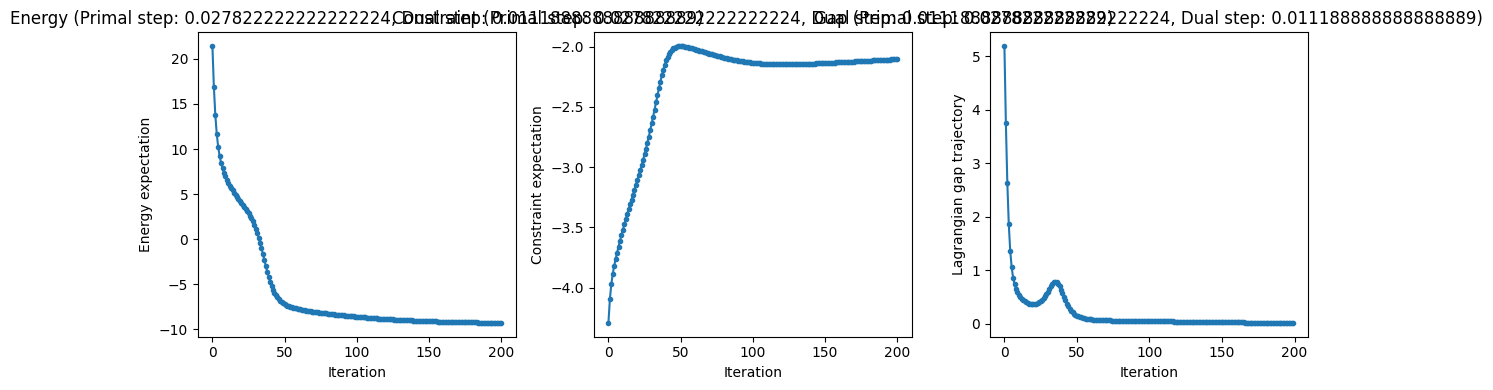

Sample 0: 100101000 with probability 0.4618 and energy -7.259999999999996
Sample 1: 100110000 with probability 0.4526 and energy -11.779999999999998
Sample 2: 100101001 with probability 0.02 and energy -7.259999999999991
Sample 3: 100001101 with probability 0.0197 and energy -7.260000000000007
Sample 4: 100110001 with probability 0.0163 and energy -7.259999999999998
Testing primal_perturb_step=0.027822222222222224, dual_perturb_step=0.016733333333333333


100%|██████████| 200/200 [03:32<00:00,  1.06s/it]


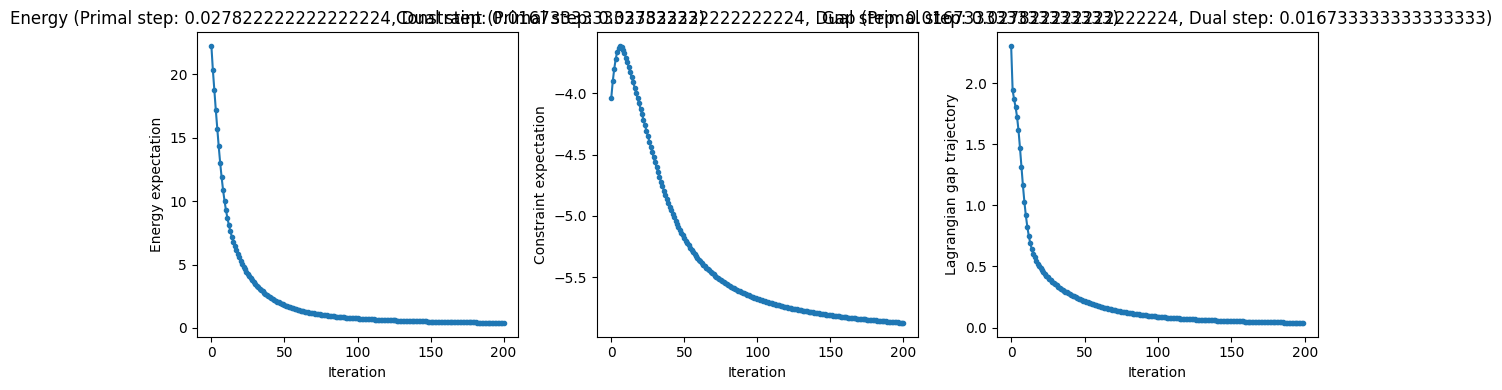

Sample 0: 000001101 with probability 0.2265 and energy -5.329070518200751e-15
Sample 1: 000001000 with probability 0.1696 and energy -1.7763568394002505e-15
Sample 2: 000001111 with probability 0.0756 and energy 0.0
Sample 3: 000000001 with probability 0.0746 and energy 0.0
Sample 4: 000001110 with probability 0.0674 and energy 0.0
Testing primal_perturb_step=0.027822222222222224, dual_perturb_step=0.02227777777777778


100%|██████████| 200/200 [03:27<00:00,  1.04s/it]


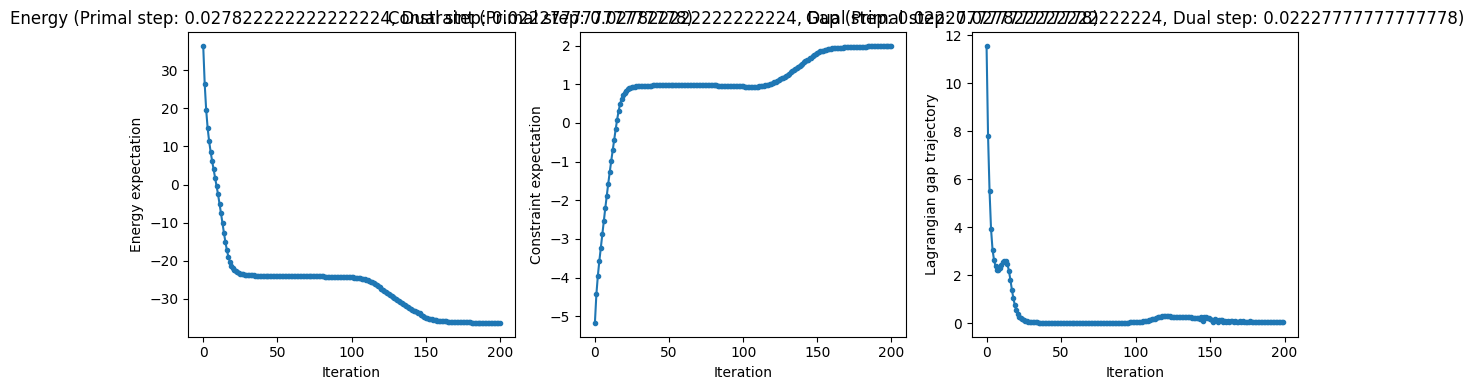

Sample 0: 111011010 with probability 0.9959 and energy -36.46999999999999
Sample 1: 011011010 with probability 0.0017 and energy -29.209999999999994
Sample 2: 111000110 with probability 0.0007 and energy -26.430000000000014
Sample 3: 110000110 with probability 0.0006 and energy -19.060000000000016
Sample 4: 111100110 with probability 0.0004 and energy -7.350000000000003
Testing primal_perturb_step=0.027822222222222224, dual_perturb_step=0.027822222222222224


 81%|████████  | 162/200 [02:54<00:41,  1.08s/it]

Converged after 163 iterations


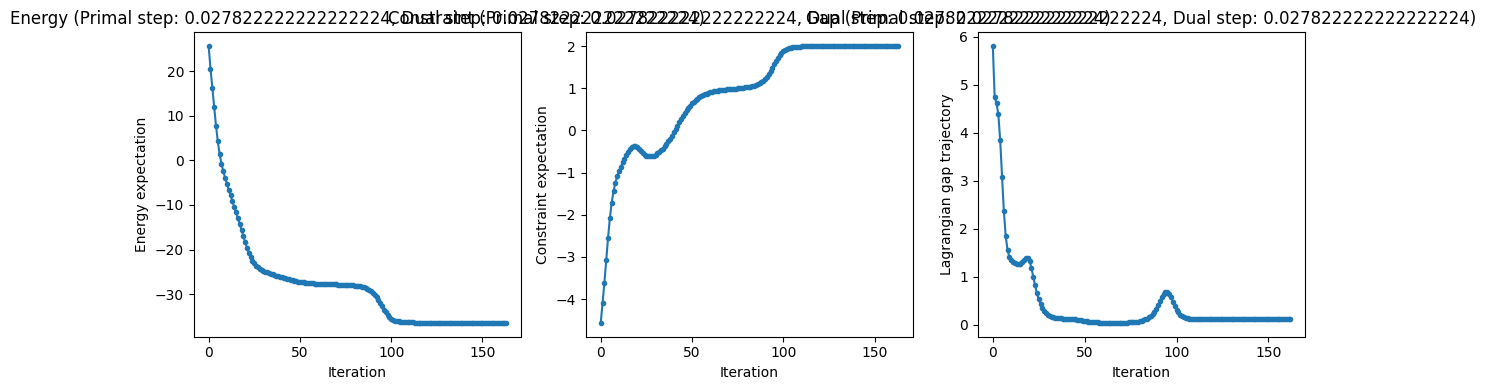

Sample 0: 111011010 with probability 0.9989 and energy -36.46999999999999
Sample 1: 011011010 with probability 0.0009 and energy -29.209999999999994
Sample 2: 100111110 with probability 0.0001 and energy -7.259999999999996
Sample 3: 110000110 with probability 0.0001 and energy -19.060000000000016
Testing primal_perturb_step=0.027822222222222224, dual_perturb_step=0.03336666666666667


 76%|███████▌  | 152/200 [02:37<00:49,  1.04s/it]

Converged after 153 iterations


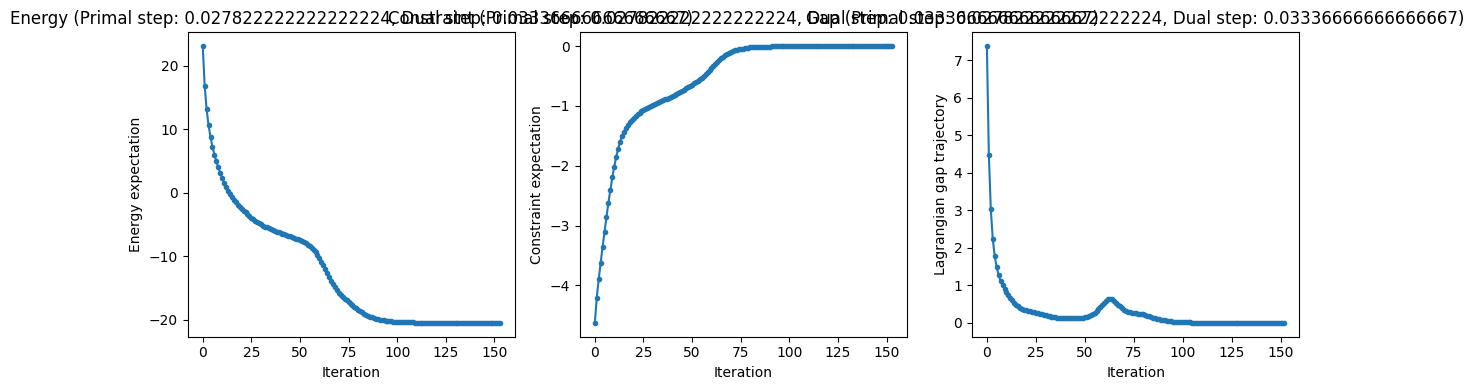

Sample 0: 110101011 with probability 0.5031 and energy -14.540000000000003
Sample 1: 111000110 with probability 0.4964 and energy -26.430000000000014
Sample 2: 000010011 with probability 0.0001 and energy 10.000000000000005
Sample 3: 000101011 with probability 0.0001 and energy 2.6645352591003757e-15
Sample 4: 001000110 with probability 0.0001 and energy 2.6300000000000026
Testing primal_perturb_step=0.027822222222222224, dual_perturb_step=0.03891111111111112


 30%|███       | 61/200 [01:04<02:27,  1.06s/it]

Converged after 62 iterations


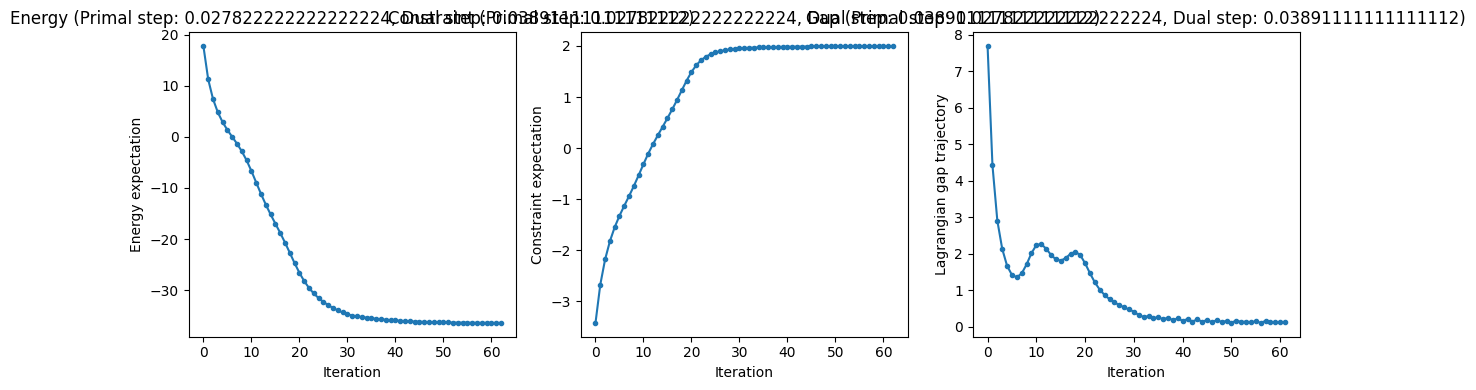

Sample 0: 111011010 with probability 0.9969 and energy -36.46999999999999
Sample 1: 011011010 with probability 0.0008 and energy -29.209999999999994
Sample 2: 110011010 with probability 0.0007 and energy -29.100000000000012
Sample 3: 101101110 with probability 0.0004 and energy -4.629999999999999
Sample 4: 111100010 with probability 0.0004 and energy -11.909999999999998
Testing primal_perturb_step=0.027822222222222224, dual_perturb_step=0.04445555555555556


100%|██████████| 200/200 [03:31<00:00,  1.06s/it]


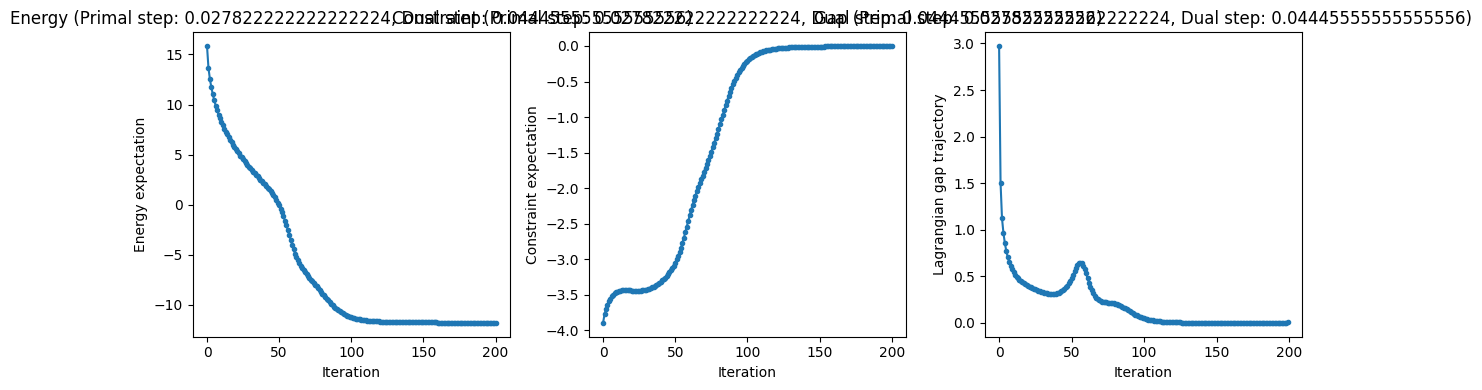

Sample 0: 100001001 with probability 0.4992 and energy -11.780000000000001
Sample 1: 100000110 with probability 0.4973 and energy -11.780000000000006
Sample 2: 110000110 with probability 0.0015 and energy -19.060000000000016
Sample 3: 110001001 with probability 0.001 and energy -19.059999999999995
Sample 4: 100110110 with probability 0.0004 and energy 7.2599999999999945
Testing primal_perturb_step=0.027822222222222224, dual_perturb_step=0.05


 61%|██████    | 122/200 [02:09<01:22,  1.06s/it]

Converged after 123 iterations


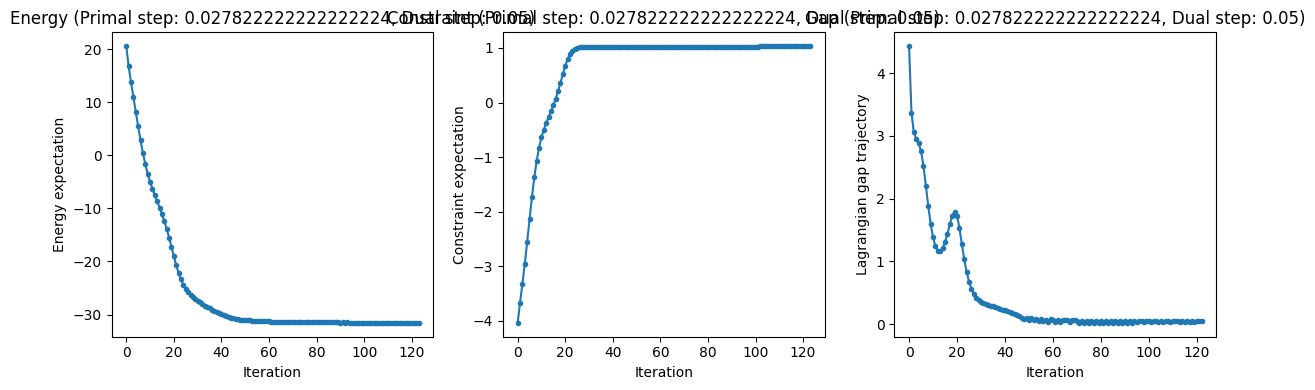

Sample 0: 111011010 with probability 0.5179 and energy -36.46999999999999
Sample 1: 111000110 with probability 0.4771 and energy -26.430000000000014
Sample 2: 110111110 with probability 0.002 and energy -14.54
Sample 3: 110011010 with probability 0.0017 and energy -29.100000000000012
Sample 4: 110000110 with probability 0.0007 and energy -19.060000000000016
Testing primal_perturb_step=0.03336666666666667, dual_perturb_step=0.0001


100%|██████████| 200/200 [03:30<00:00,  1.05s/it]


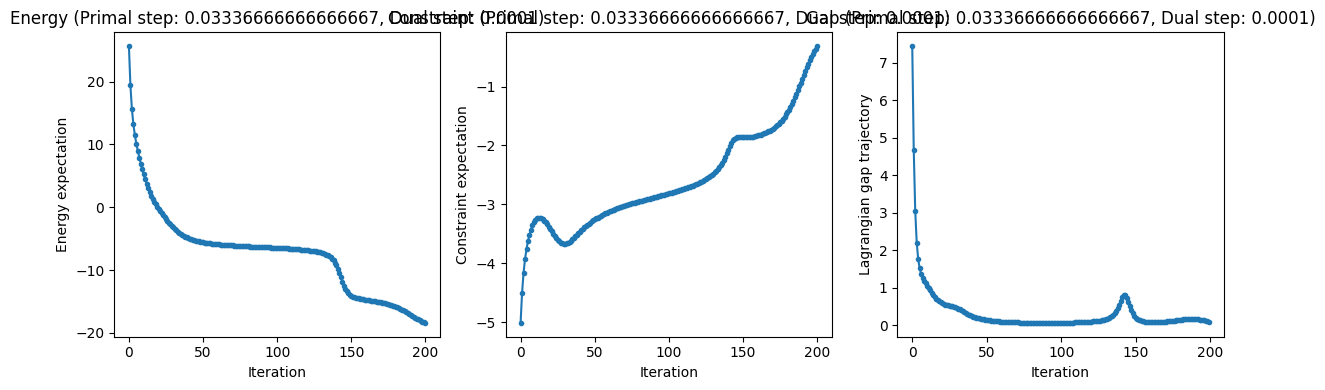

Sample 0: 101000110 with probability 0.8453 and energy -19.150000000000006
Sample 1: 101100110 with probability 0.1531 and energy -14.63
Sample 2: 100010001 with probability 0.0006 and energy 2.7400000000000038
Sample 3: 011101110 with probability 0.0003 and energy -4.650000000000002
Sample 4: 111101110 with probability 0.0003 and energy -11.909999999999998
Testing primal_perturb_step=0.03336666666666667, dual_perturb_step=0.005644444444444445


100%|██████████| 200/200 [03:31<00:00,  1.06s/it]


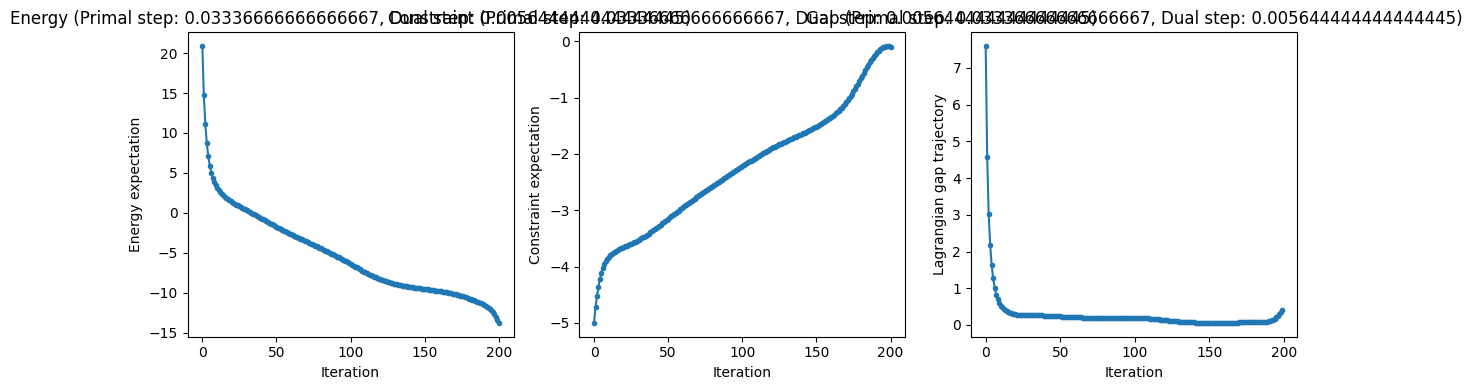

Sample 0: 100111111 with probability 0.6576 and energy -11.779999999999992
Sample 1: 110111111 with probability 0.3024 and energy -19.059999999999988
Sample 2: 100111110 with probability 0.0113 and energy -7.259999999999996
Sample 3: 000110101 with probability 0.0063 and energy -1.7763568394002505e-15
Sample 4: 110111110 with probability 0.0046 and energy -14.54
Testing primal_perturb_step=0.03336666666666667, dual_perturb_step=0.011188888888888889


100%|██████████| 200/200 [03:27<00:00,  1.04s/it]


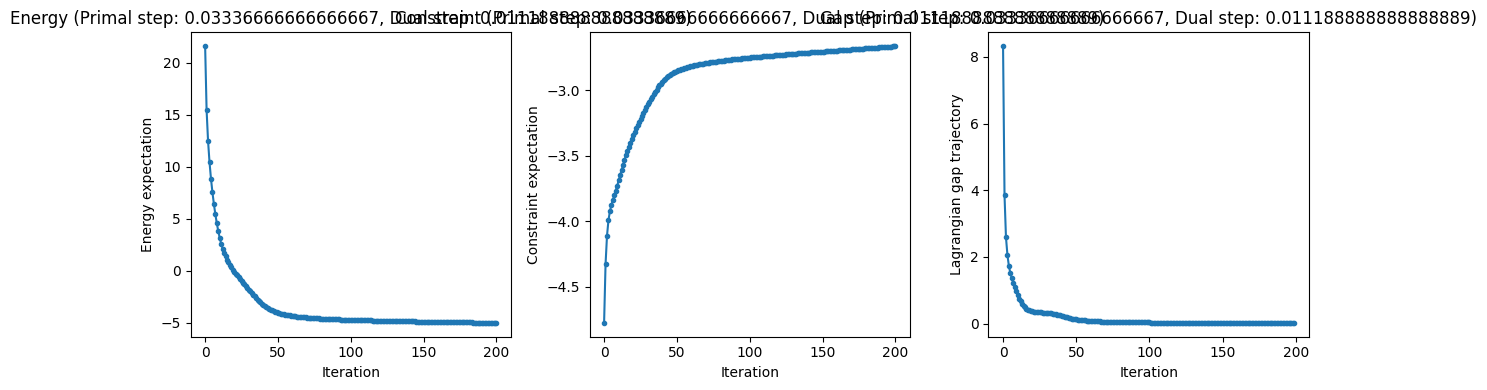

Sample 0: 100001101 with probability 0.1982 and energy -7.260000000000007
Sample 1: 100000111 with probability 0.16 and energy -7.260000000000001
Sample 2: 100101011 with probability 0.1439 and energy -7.26
Sample 3: 100100011 with probability 0.0707 and energy 2.7400000000000073
Sample 4: 100101001 with probability 0.059 and energy -7.259999999999991
Testing primal_perturb_step=0.03336666666666667, dual_perturb_step=0.016733333333333333


 67%|██████▋   | 134/200 [02:23<01:10,  1.07s/it]

Converged after 135 iterations


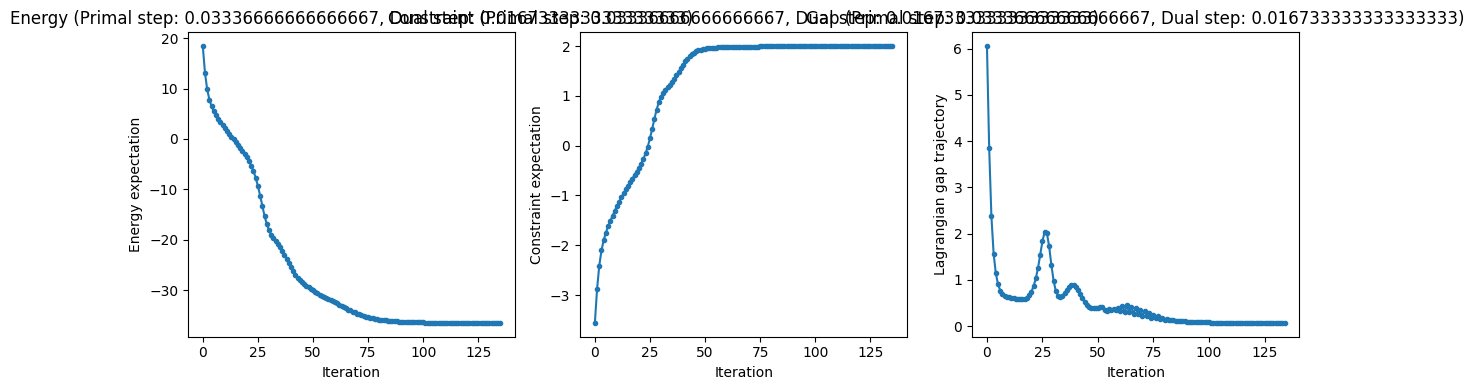

Sample 0: 111011010 with probability 0.9994 and energy -36.46999999999999
Sample 1: 111110010 with probability 0.0003 and energy 7.130000000000003
Sample 2: 011011010 with probability 0.0002 and energy -29.209999999999994
Sample 3: 111101010 with probability 0.0001 and energy 21.690000000000005
Testing primal_perturb_step=0.03336666666666667, dual_perturb_step=0.02227777777777778


 86%|████████▋ | 173/200 [03:01<00:28,  1.05s/it]

Converged after 174 iterations


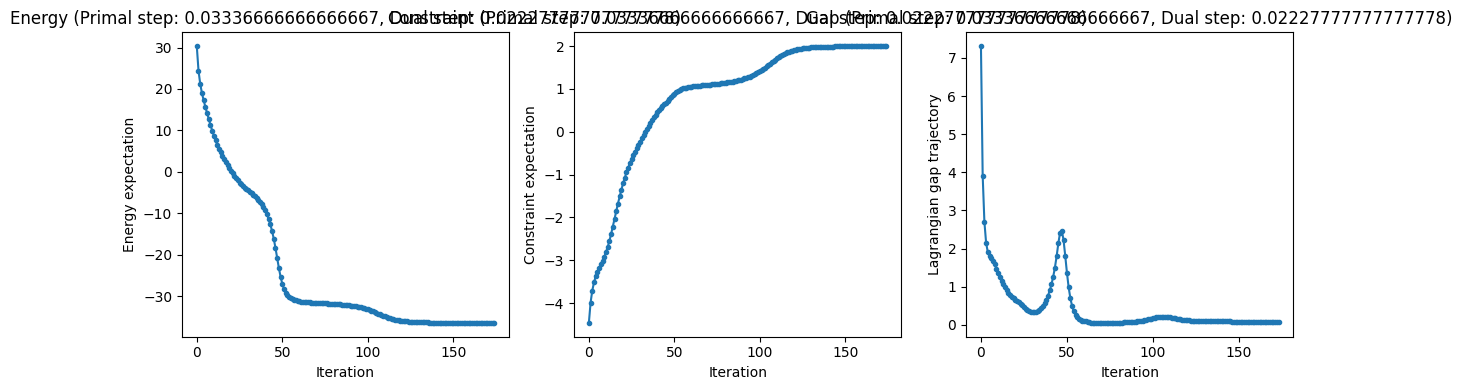

Sample 0: 111011010 with probability 0.9984 and energy -36.46999999999999
Sample 1: 111000110 with probability 0.0014 and energy -26.430000000000014
Sample 2: 101111111 with probability 0.0002 and energy -4.410000000000002
Testing primal_perturb_step=0.03336666666666667, dual_perturb_step=0.027822222222222224


 73%|███████▎  | 146/200 [02:35<00:57,  1.07s/it]

Converged after 147 iterations


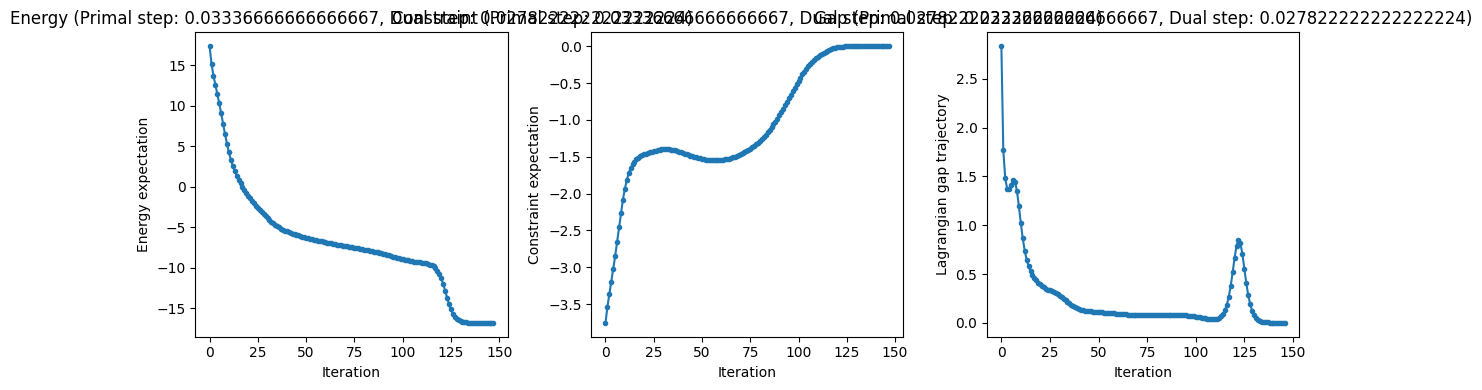

Sample 0: 110001001 with probability 0.2562 and energy -19.059999999999995
Sample 1: 110000110 with probability 0.2513 and energy -19.060000000000016
Sample 2: 110110001 with probability 0.2471 and energy -14.54
Sample 3: 110111110 with probability 0.2451 and energy -14.54
Sample 4: 100000110 with probability 0.0002 and energy -11.780000000000006
Testing primal_perturb_step=0.03336666666666667, dual_perturb_step=0.03336666666666667


 66%|██████▌   | 132/200 [02:23<01:13,  1.09s/it]

Gap closed after 133 iterations; VQEC converged.


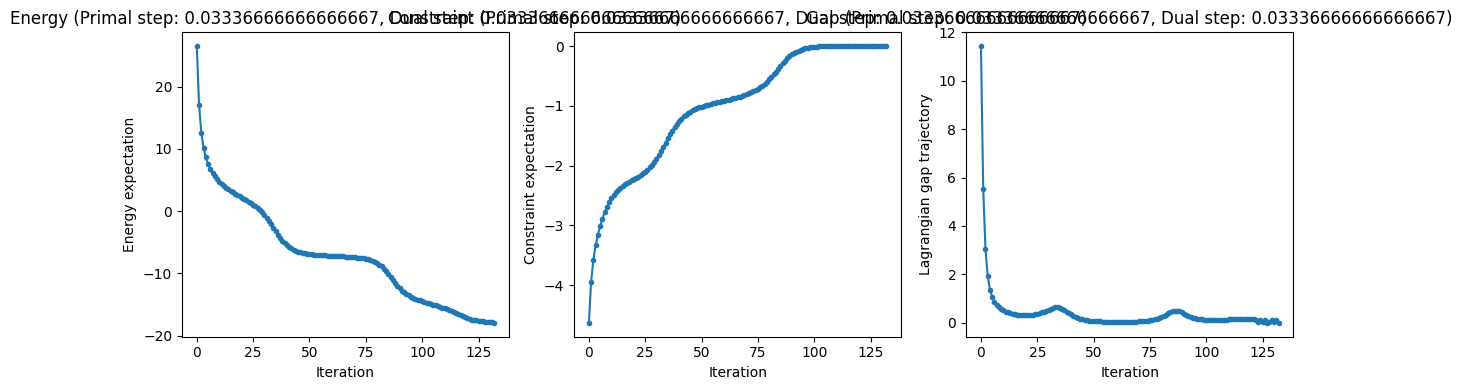

Sample 0: 110001001 with probability 0.3898 and energy -19.059999999999995
Sample 1: 110000110 with probability 0.3888 and energy -19.060000000000016
Sample 2: 110110001 with probability 0.1084 and energy -14.54
Sample 3: 110111110 with probability 0.1073 and energy -14.54
Sample 4: 100001001 with probability 0.0008 and energy -11.780000000000001
Testing primal_perturb_step=0.03336666666666667, dual_perturb_step=0.03891111111111112


100%|██████████| 200/200 [03:32<00:00,  1.06s/it]


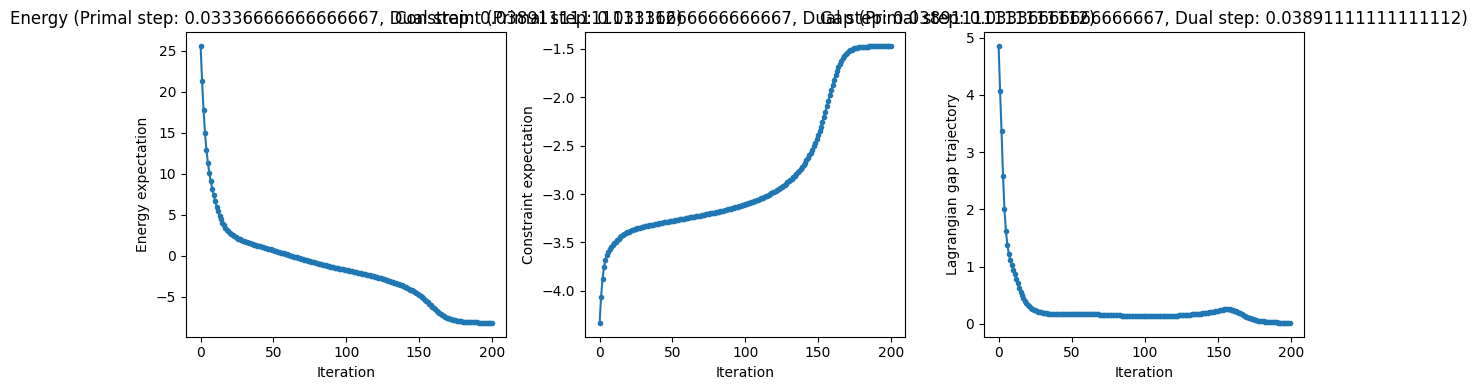

Sample 0: 100111110 with probability 0.2554 and energy -7.259999999999996
Sample 1: 100110000 with probability 0.2539 and energy -11.779999999999998
Sample 2: 100101000 with probability 0.2413 and energy -7.259999999999996
Sample 3: 100100110 with probability 0.2351 and energy -7.259999999999993
Sample 4: 011110000 with probability 0.0015 and energy 39.57000000000001
Testing primal_perturb_step=0.03336666666666667, dual_perturb_step=0.04445555555555556


100%|██████████| 200/200 [03:26<00:00,  1.03s/it]


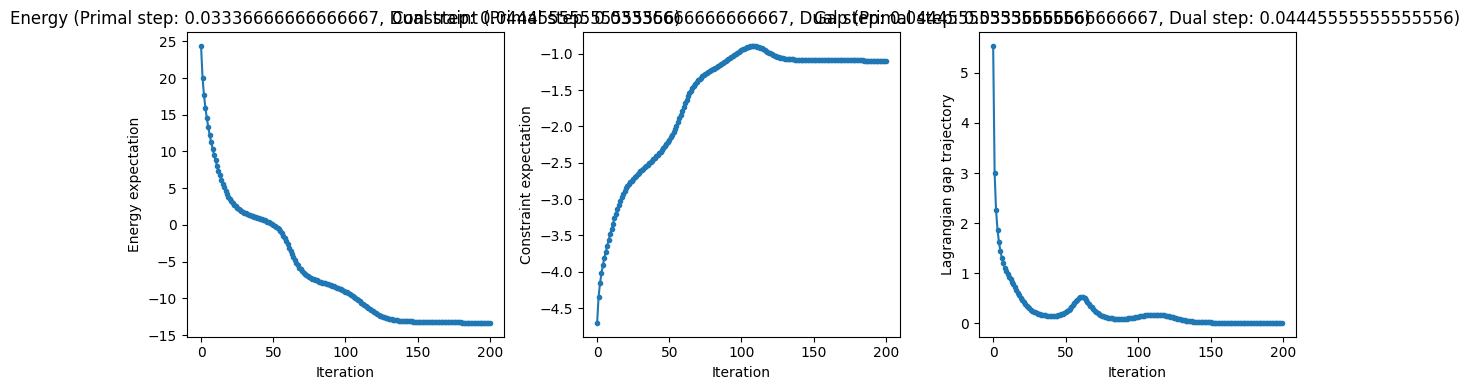

Sample 0: 101100110 with probability 0.5451 and energy -14.63
Sample 1: 100110000 with probability 0.4227 and energy -11.779999999999998
Sample 2: 110011011 with probability 0.012 and energy -14.540000000000004
Sample 3: 100011011 with probability 0.008 and energy -7.260000000000005
Sample 4: 110110000 with probability 0.0075 and energy -19.05999999999999
Testing primal_perturb_step=0.03336666666666667, dual_perturb_step=0.05


 45%|████▌     | 90/200 [01:38<02:00,  1.09s/it]

Gap closed after 91 iterations; VQEC converged.


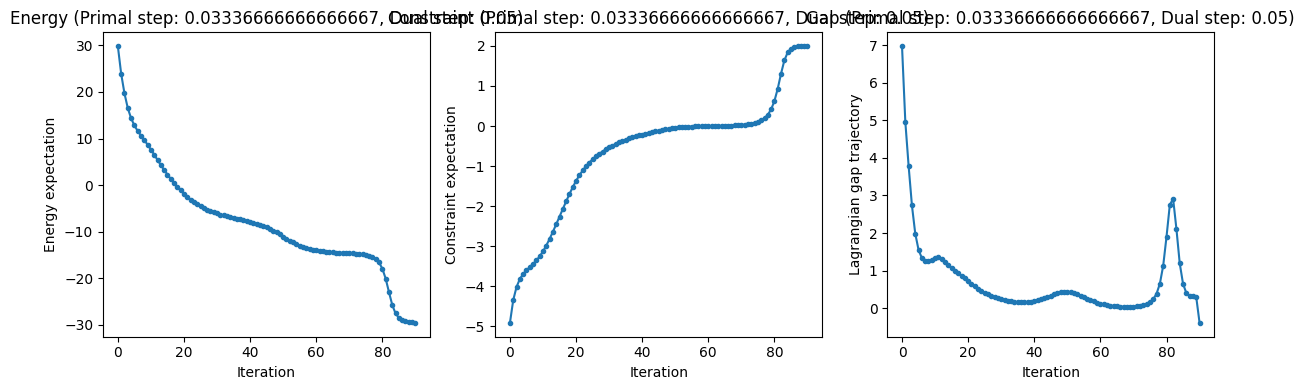

Sample 0: 011011010 with probability 0.9312 and energy -29.209999999999994
Sample 1: 111011010 with probability 0.0669 and energy -36.46999999999999
Sample 2: 011111010 with probability 0.0009 and energy -14.650000000000006
Sample 3: 011011001 with probability 0.0005 and energy 58.510000000000005
Sample 4: 100001001 with probability 0.0003 and energy -11.780000000000001
Testing primal_perturb_step=0.03891111111111112, dual_perturb_step=0.0001


 34%|███▍      | 68/200 [01:15<02:26,  1.11s/it]

Gap closed after 69 iterations; VQEC converged.


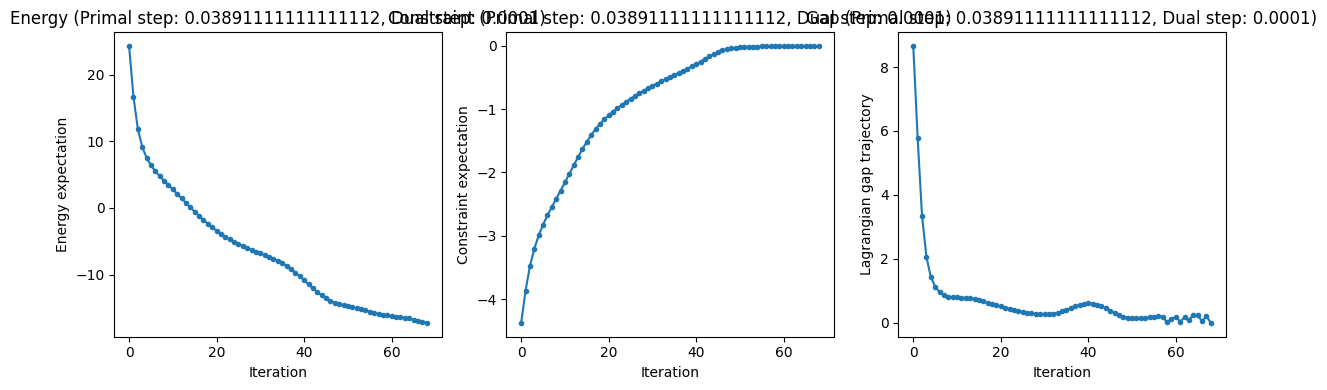

Sample 0: 110111111 with probability 0.317 and energy -19.059999999999988
Sample 1: 110110000 with probability 0.3048 and energy -19.05999999999999
Sample 2: 110110001 with probability 0.1906 and energy -14.54
Sample 3: 110111110 with probability 0.1839 and energy -14.54
Sample 4: 110110011 with probability 0.0014 and energy -0.020000000000007567
Testing primal_perturb_step=0.03891111111111112, dual_perturb_step=0.005644444444444445


 10%|█         | 21/200 [00:25<03:41,  1.24s/it]

Gap closed after 22 iterations; VQEC converged.


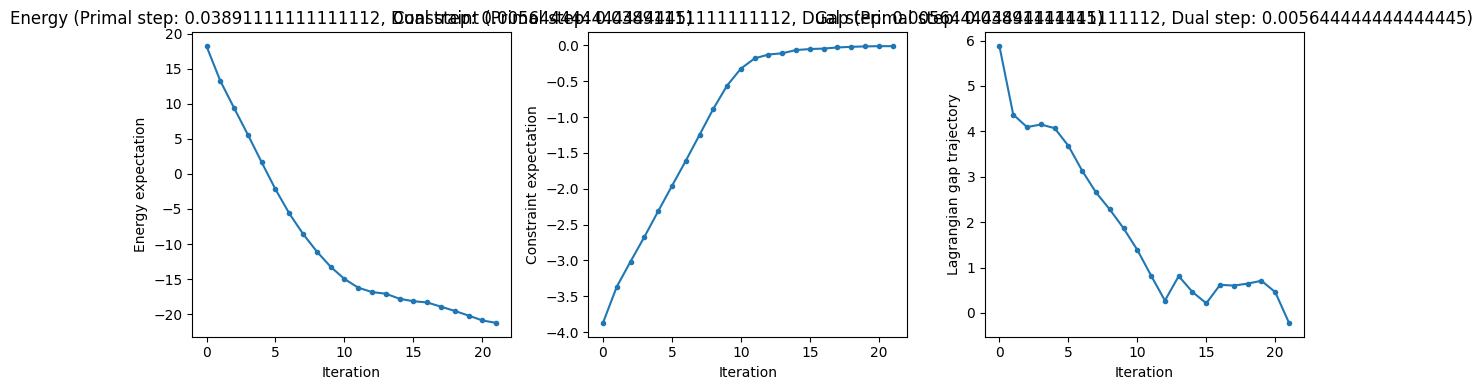

Sample 0: 110110000 with probability 0.5008 and energy -19.05999999999999
Sample 1: 111000110 with probability 0.3688 and energy -26.430000000000014
Sample 2: 110000110 with probability 0.065 and energy -19.060000000000016
Sample 3: 110110001 with probability 0.0565 and energy -14.54
Sample 4: 111110000 with probability 0.002 and energy 17.790000000000013
Testing primal_perturb_step=0.03891111111111112, dual_perturb_step=0.011188888888888889


 94%|█████████▎| 187/200 [03:17<00:13,  1.06s/it]

Converged after 188 iterations


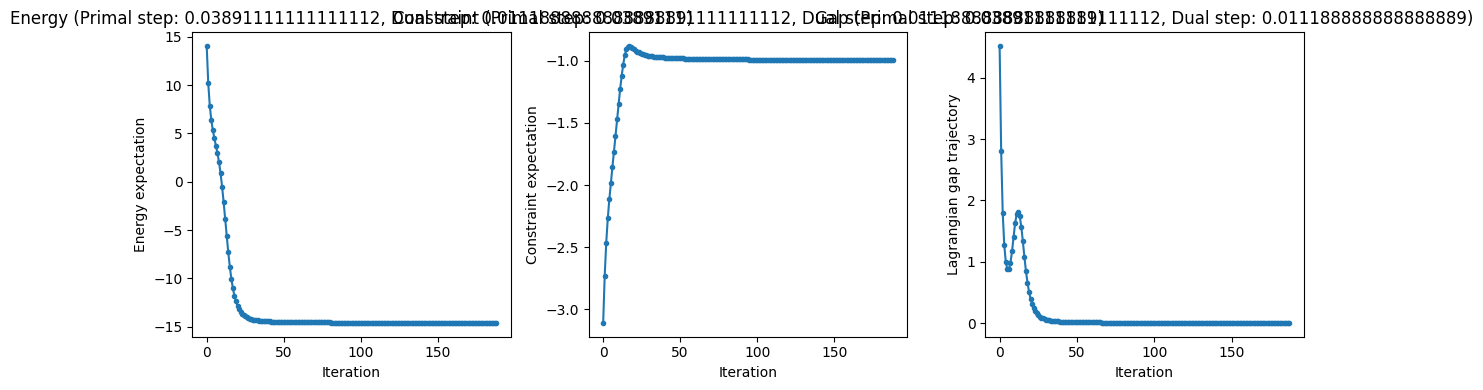

Sample 0: 101111110 with probability 0.4973 and energy -14.62999999999998
Sample 1: 101100110 with probability 0.4862 and energy -14.63
Sample 2: 111111110 with probability 0.0059 and energy -21.90999999999999
Found '111111110' with energy -21.9 and probability 0.0059
Testing primal_perturb_step=0.03891111111111112, dual_perturb_step=0.016733333333333333


100%|██████████| 200/200 [03:43<00:00,  1.12s/it]


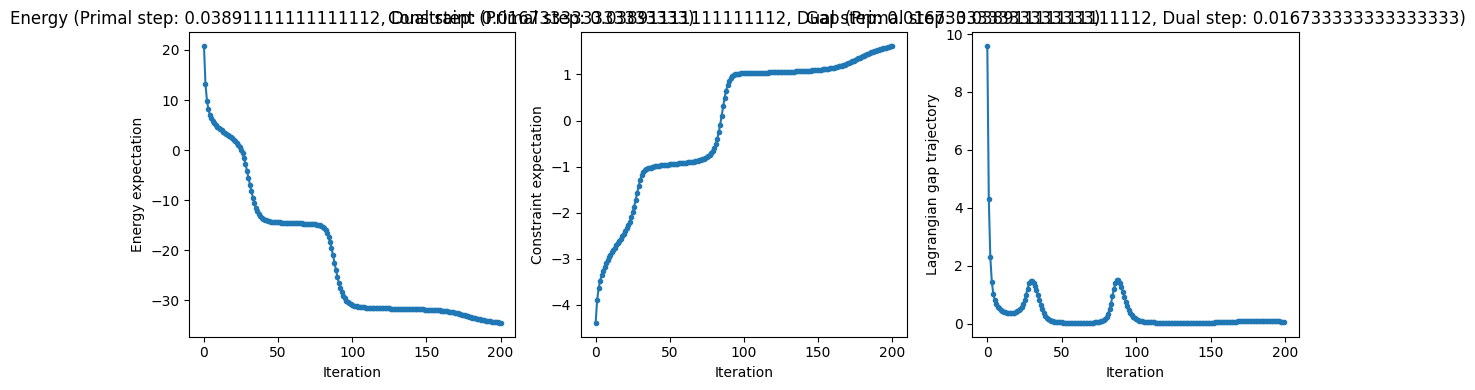

Sample 0: 111011010 with probability 0.8082 and energy -36.46999999999999
Sample 1: 111000110 with probability 0.1873 and energy -26.430000000000014
Sample 2: 111011110 with probability 0.0015 and energy -11.909999999999998
Sample 3: 111000010 with probability 0.0014 and energy 7.210000000000004
Sample 4: 111010010 with probability 0.0012 and energy -11.910000000000002
Testing primal_perturb_step=0.03891111111111112, dual_perturb_step=0.02227777777777778


 76%|███████▌  | 151/200 [02:47<00:54,  1.11s/it]

Gap closed after 152 iterations; VQEC converged.


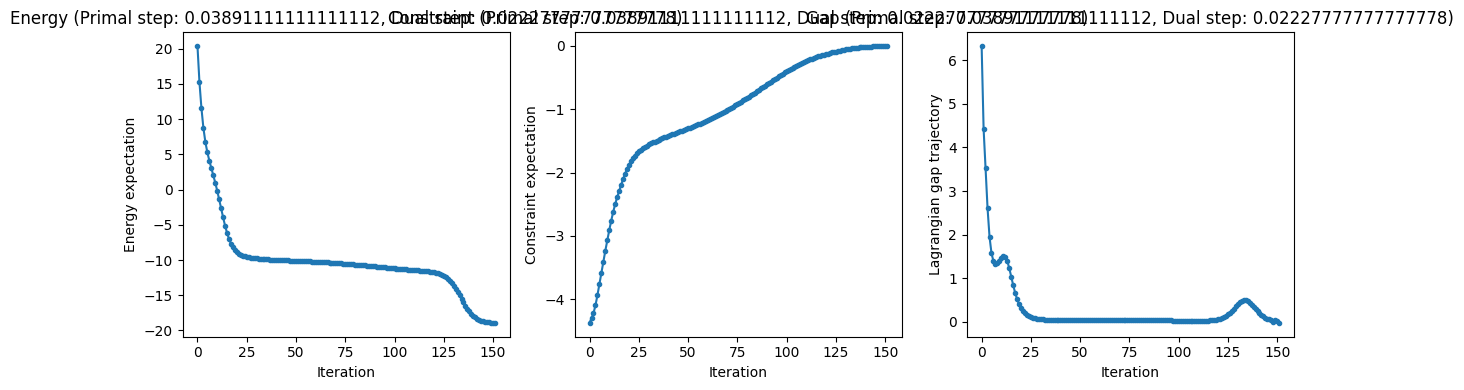

Sample 0: 110000110 with probability 0.498 and energy -19.060000000000016
Sample 1: 110001001 with probability 0.4889 and energy -19.059999999999995
Sample 2: 100000110 with probability 0.0064 and energy -11.780000000000006
Sample 3: 100001001 with probability 0.0054 and energy -11.780000000000001
Sample 4: 110001000 with probability 0.0005 and energy 14.579999999999997
Testing primal_perturb_step=0.03891111111111112, dual_perturb_step=0.027822222222222224


 23%|██▎       | 46/200 [00:49<02:45,  1.08s/it]

Gap closed after 47 iterations; VQEC converged.


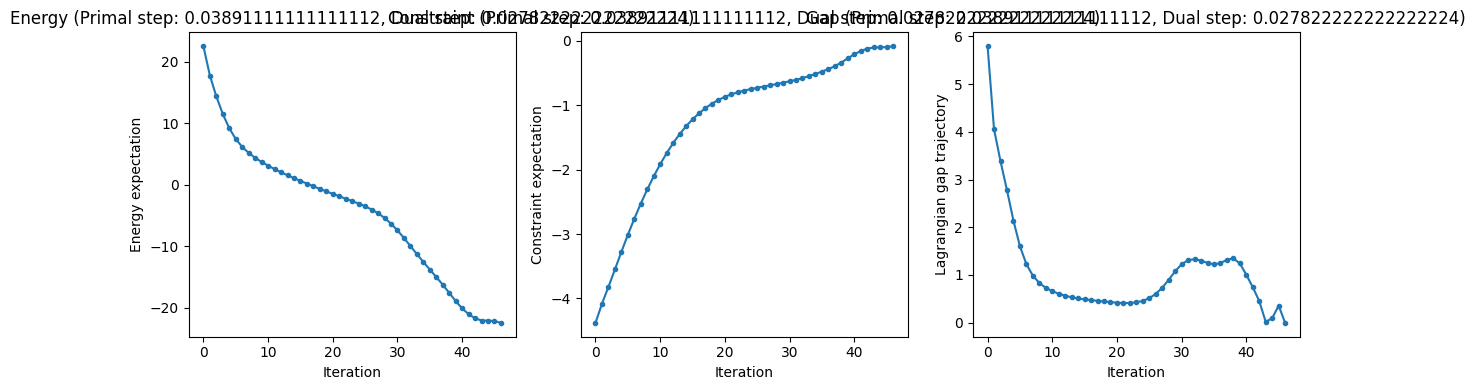

Sample 0: 111000110 with probability 0.4651 and energy -26.430000000000014
Sample 1: 111111110 with probability 0.4474 and energy -21.90999999999999
Found '111111110' with energy -21.9 and probability 0.4474
Testing primal_perturb_step=0.03891111111111112, dual_perturb_step=0.03336666666666667


100%|██████████| 200/200 [03:28<00:00,  1.04s/it]


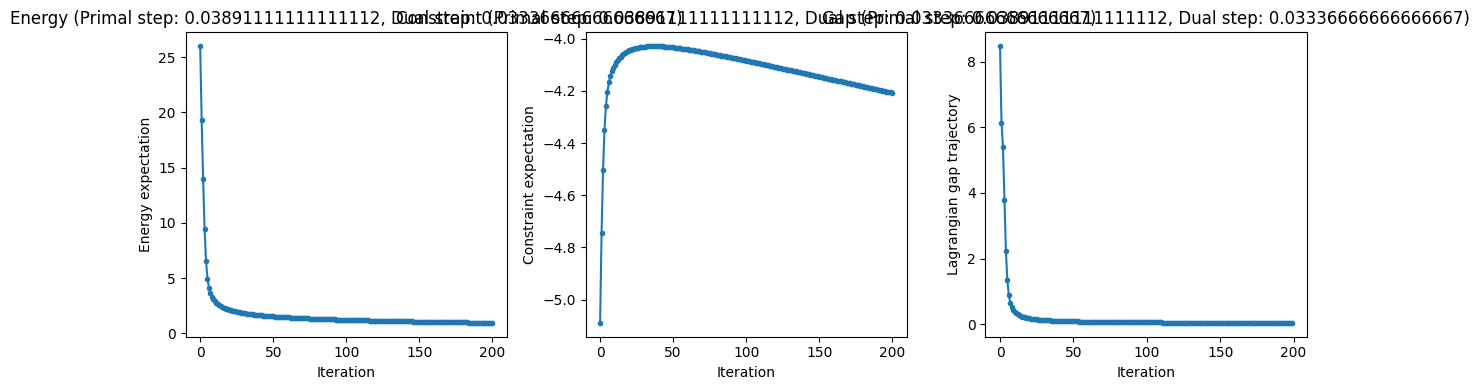

Sample 0: 000110001 with probability 0.0902 and energy 0.0
Sample 1: 000111101 with probability 0.0757 and energy -1.5987211554602254e-14
Sample 2: 000111100 with probability 0.0753 and energy -8.43769498715119e-15
Sample 3: 000111000 with probability 0.0654 and energy 8.881784197001252e-16
Sample 4: 000001010 with probability 0.0497 and energy -3.552713678800501e-15
Testing primal_perturb_step=0.03891111111111112, dual_perturb_step=0.03891111111111112


 57%|█████▊    | 115/200 [02:02<01:30,  1.07s/it]

Converged after 116 iterations


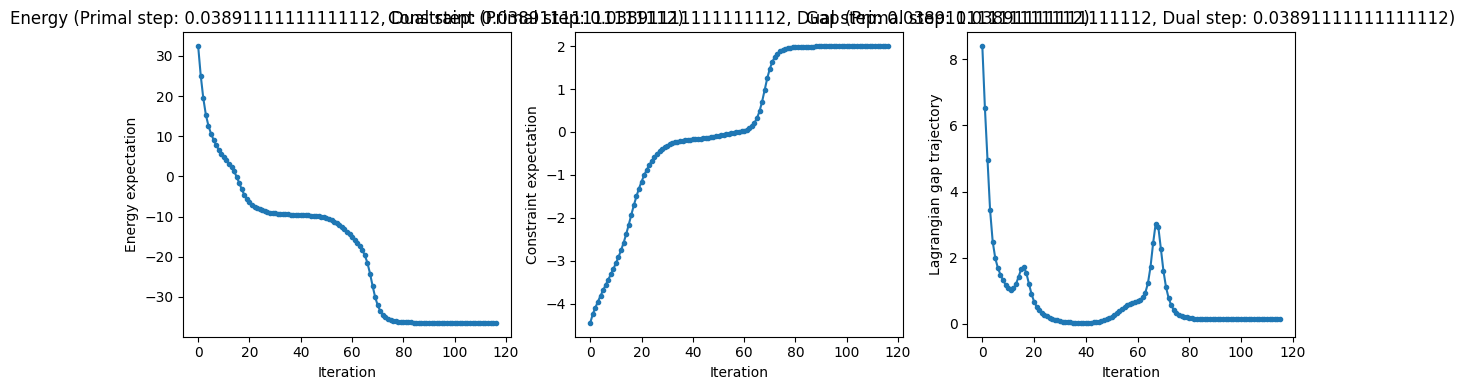

Sample 0: 111011010 with probability 0.9997 and energy -36.46999999999999
Sample 1: 111000110 with probability 0.0002 and energy -26.430000000000014
Sample 2: 111011100 with probability 0.0001 and energy 75.99
Testing primal_perturb_step=0.03891111111111112, dual_perturb_step=0.04445555555555556


100%|██████████| 200/200 [03:37<00:00,  1.09s/it]


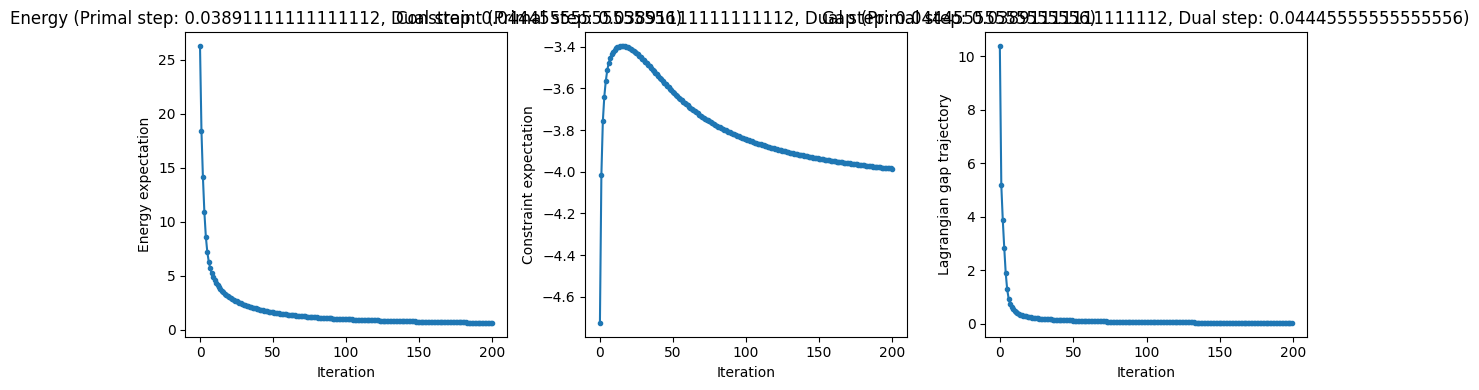

Sample 0: 000110110 with probability 0.1438 and energy -3.552713678800501e-15
Sample 1: 000100110 with probability 0.1332 and energy 5.329070518200751e-15
Sample 2: 000111010 with probability 0.1235 and energy -4.884981308350689e-15
Sample 3: 000111000 with probability 0.0874 and energy 8.881784197001252e-16
Sample 4: 000110100 with probability 0.0471 and energy -7.105427357601002e-15
Testing primal_perturb_step=0.03891111111111112, dual_perturb_step=0.05


100%|██████████| 200/200 [03:27<00:00,  1.04s/it]


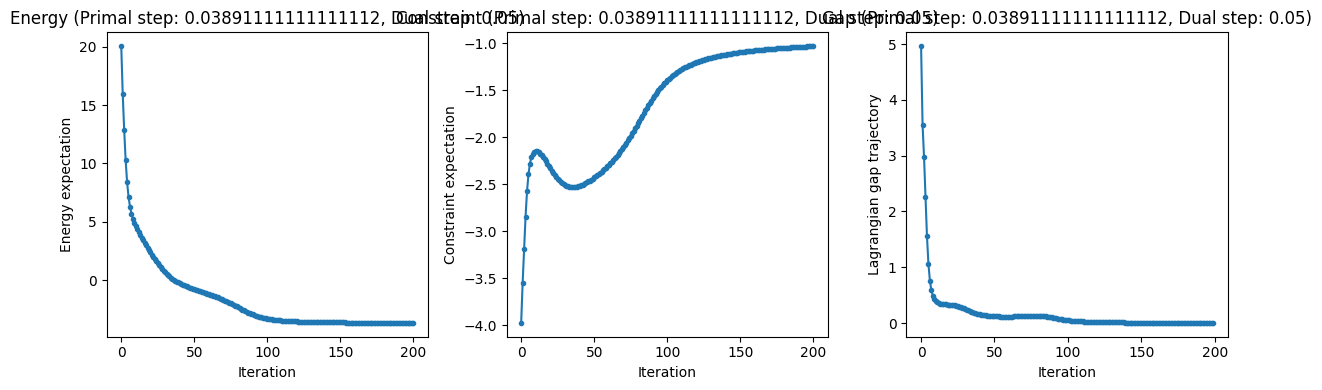

Sample 0: 001101010 with probability 0.2046 and energy -7.3700000000000045
Sample 1: 000011010 with probability 0.1947 and energy -1.4210854715202004e-14
Sample 2: 001110010 with probability 0.1522 and energy -7.369999999999994
Sample 3: 000000010 with probability 0.1454 and energy -5.329070518200751e-15
Sample 4: 000101010 with probability 0.0577 and energy -7.105427357601002e-15
Testing primal_perturb_step=0.04445555555555556, dual_perturb_step=0.0001


100%|██████████| 200/200 [03:28<00:00,  1.04s/it]


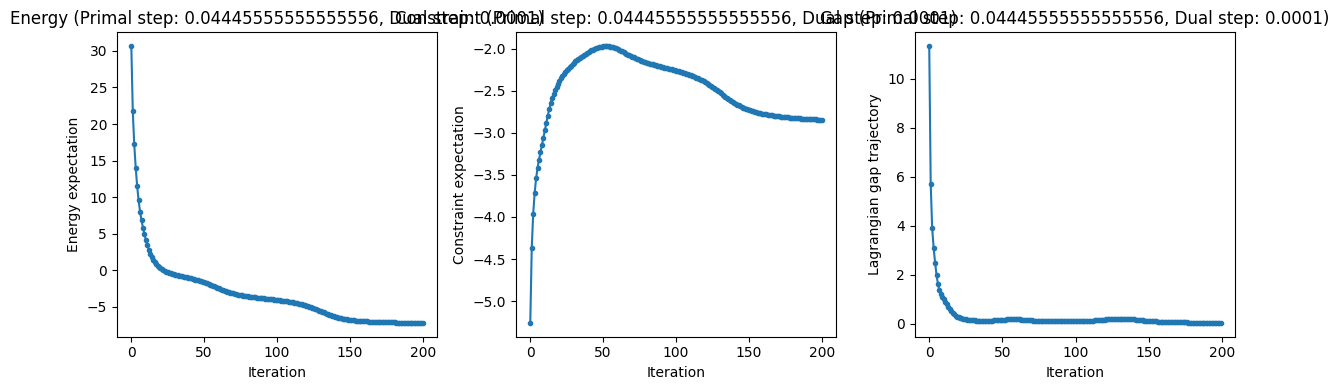

Sample 0: 001110110 with probability 0.2117 and energy -7.370000000000001
Sample 1: 001001110 with probability 0.2091 and energy -7.36999999999999
Sample 2: 001000010 with probability 0.1263 and energy -7.370000000000003
Sample 3: 001100110 with probability 0.1075 and energy -7.370000000000003
Sample 4: 001111110 with probability 0.0874 and energy -7.369999999999976
Testing primal_perturb_step=0.04445555555555556, dual_perturb_step=0.005644444444444445


 54%|█████▍    | 108/200 [01:56<01:39,  1.08s/it]

Converged after 109 iterations


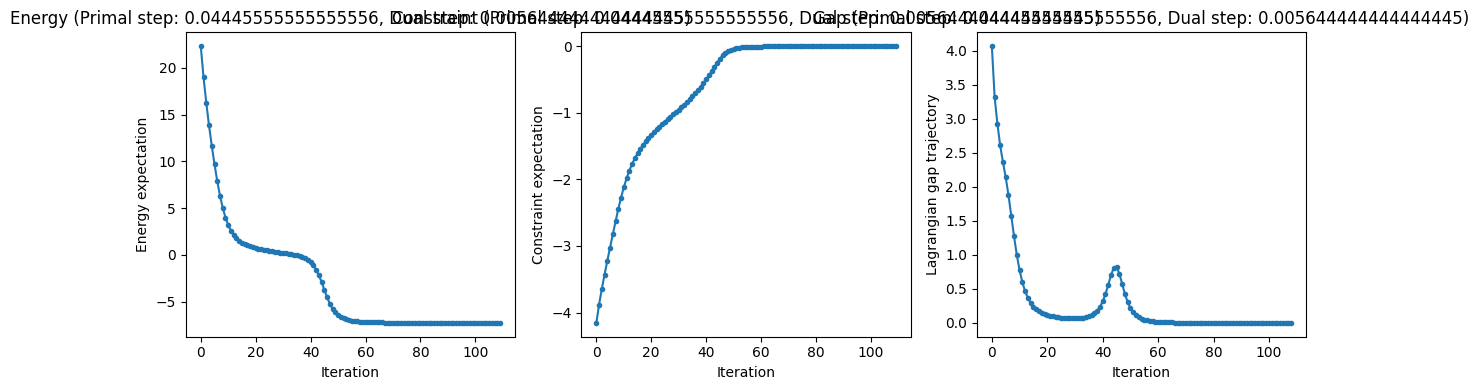

Sample 0: 010110001 with probability 0.5017 and energy -7.280000000000001
Sample 1: 010110010 with probability 0.2767 and energy -7.280000000000014
Sample 2: 010111010 with probability 0.2216 and energy -7.280000000000008
Testing primal_perturb_step=0.04445555555555556, dual_perturb_step=0.011188888888888889


 56%|█████▌    | 112/200 [01:56<01:31,  1.04s/it]

Gap closed after 113 iterations; VQEC converged.


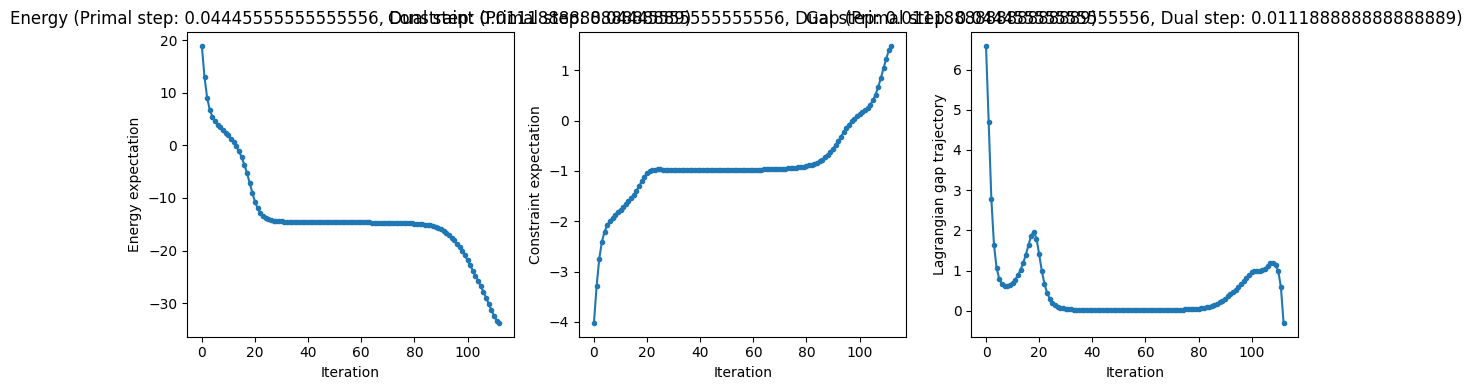

Sample 0: 111011010 with probability 0.7358 and energy -36.46999999999999
Sample 1: 111000110 with probability 0.259 and energy -26.430000000000014
Sample 2: 101011010 with probability 0.0024 and energy -14.629999999999994
Sample 3: 101000110 with probability 0.0009 and energy -19.150000000000006
Sample 4: 111010111 with probability 0.0005 and energy 80.10999999999999
Testing primal_perturb_step=0.04445555555555556, dual_perturb_step=0.016733333333333333


100%|██████████| 200/200 [03:30<00:00,  1.05s/it]


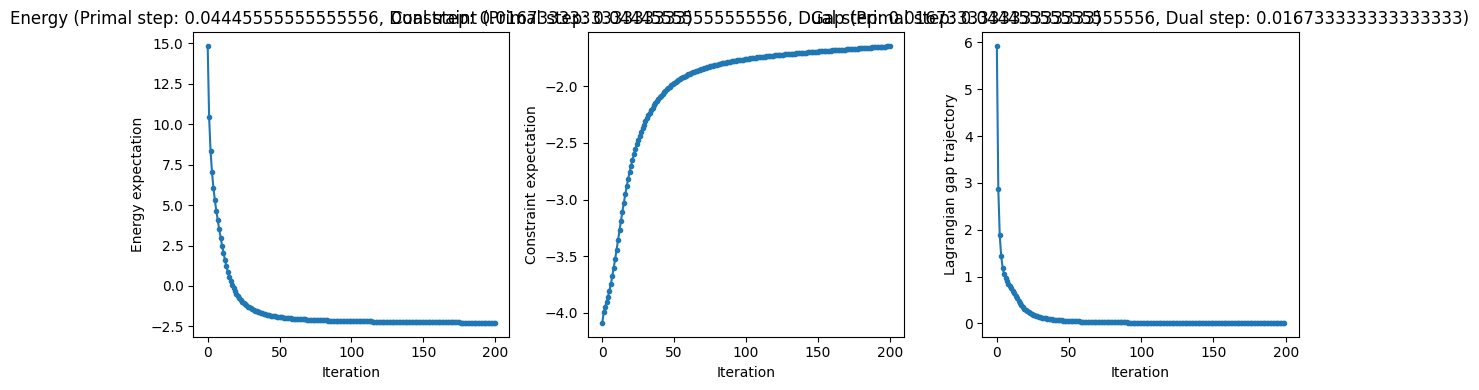

Sample 0: 100011011 with probability 0.2509 and energy -7.260000000000005
Sample 1: 100101011 with probability 0.2389 and energy -7.26
Sample 2: 100101110 with probability 0.0894 and energy 2.740000000000002
Sample 3: 100011110 with probability 0.0824 and energy 2.7400000000000064
Sample 4: 100101100 with probability 0.0815 and energy 2.7399999999999993
Testing primal_perturb_step=0.04445555555555556, dual_perturb_step=0.02227777777777778


100%|██████████| 200/200 [03:31<00:00,  1.06s/it]


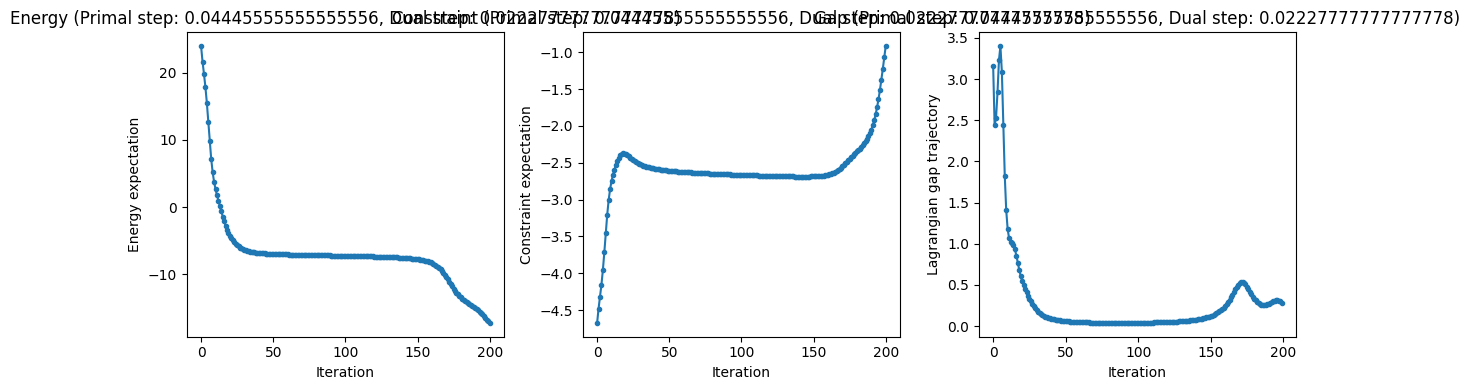

Sample 0: 101000110 with probability 0.5976 and energy -19.150000000000006
Sample 1: 101000010 with probability 0.2842 and energy -14.630000000000003
Sample 2: 101011010 with probability 0.1136 and energy -14.629999999999994
Sample 3: 101011110 with probability 0.0016 and energy -4.629999999999998
Sample 4: 101100110 with probability 0.0004 and energy -14.63
Testing primal_perturb_step=0.04445555555555556, dual_perturb_step=0.027822222222222224


100%|██████████| 200/200 [03:26<00:00,  1.03s/it]


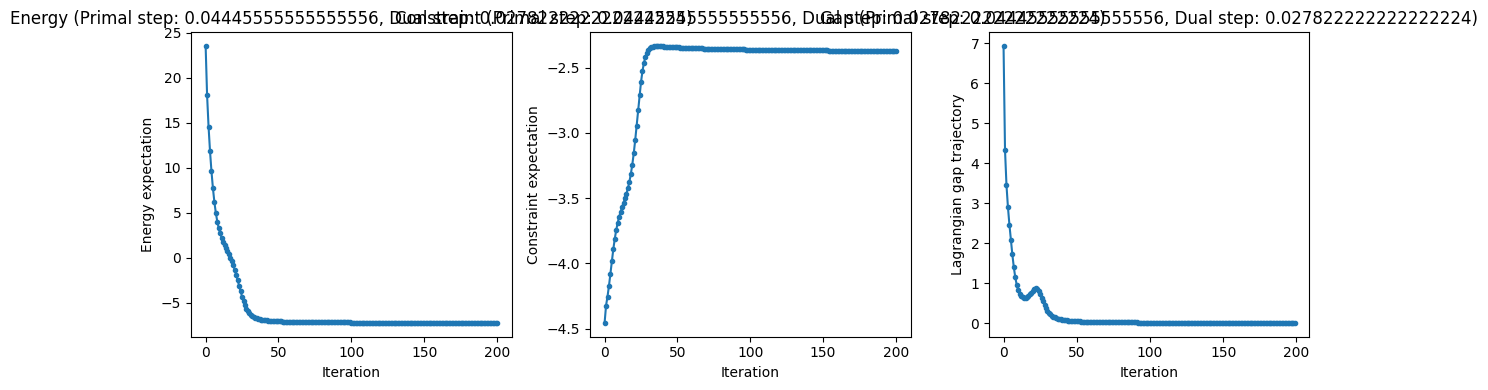

Sample 0: 100110111 with probability 0.2997 and energy -7.260000000000003
Sample 1: 100111000 with probability 0.2882 and energy -7.260000000000001
Sample 2: 100110001 with probability 0.206 and energy -7.259999999999998
Sample 3: 100111110 with probability 0.1925 and energy -7.259999999999996
Sample 4: 100110000 with probability 0.0053 and energy -11.779999999999998
Testing primal_perturb_step=0.04445555555555556, dual_perturb_step=0.03336666666666667


100%|██████████| 200/200 [03:28<00:00,  1.04s/it]


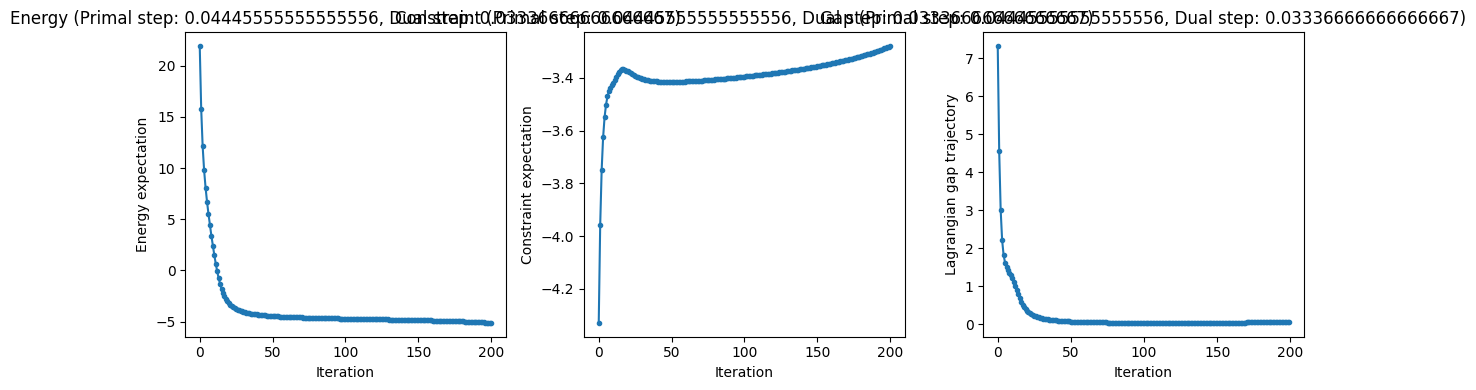

Sample 0: 100000010 with probability 0.2555 and energy -7.260000000000005
Sample 1: 100000111 with probability 0.1606 and energy -7.260000000000001
Sample 2: 100101000 with probability 0.1225 and energy -7.259999999999996
Sample 3: 100001000 with probability 0.101 and energy -7.260000000000002
Sample 4: 100101101 with probability 0.083 and energy 2.7399999999999984
Testing primal_perturb_step=0.04445555555555556, dual_perturb_step=0.03891111111111112


 26%|██▋       | 53/200 [00:57<02:38,  1.08s/it]

Gap closed after 54 iterations; VQEC converged.


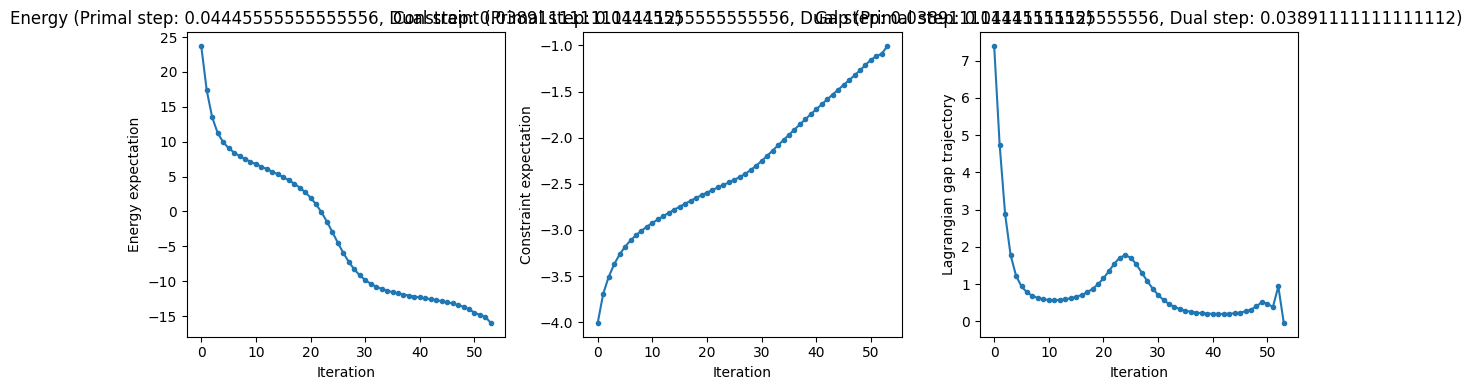

Sample 0: 100010101 with probability 0.2265 and energy -7.2600000000000104
Sample 1: 100001001 with probability 0.208 and energy -11.780000000000001
Sample 2: 101000110 with probability 0.1599 and energy -19.150000000000006
Sample 3: 101011010 with probability 0.152 and energy -14.629999999999994
Sample 4: 111000110 with probability 0.105 and energy -26.430000000000014
Testing primal_perturb_step=0.04445555555555556, dual_perturb_step=0.04445555555555556


100%|██████████| 200/200 [03:34<00:00,  1.07s/it]


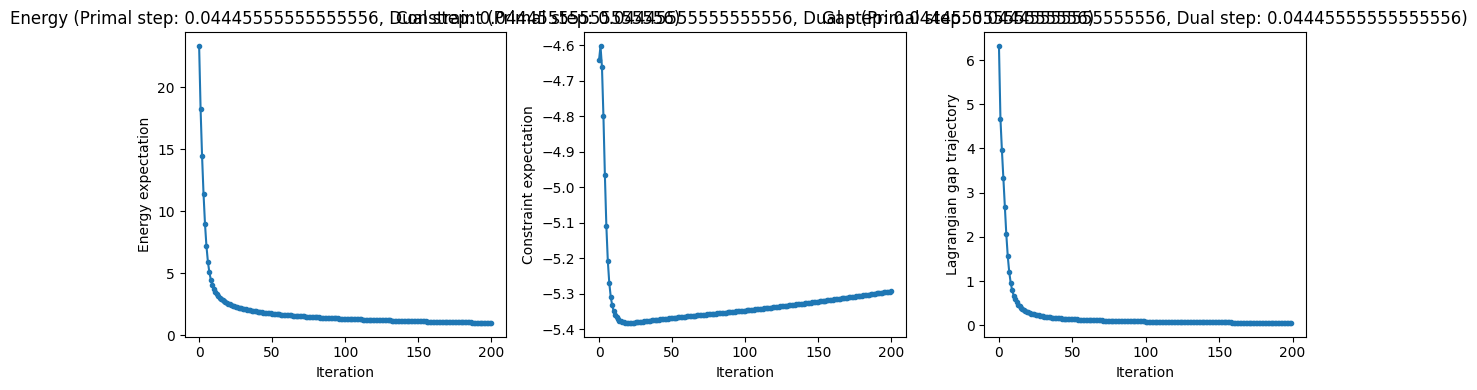

Sample 0: 000000010 with probability 0.129 and energy -5.329070518200751e-15
Sample 1: 000101010 with probability 0.1184 and energy -7.105427357601002e-15
Sample 2: 000110110 with probability 0.1032 and energy -3.552713678800501e-15
Sample 3: 000000000 with probability 0.0574 and energy 0.0
Sample 4: 000000100 with probability 0.0542 and energy -1.0658141036401503e-14
Testing primal_perturb_step=0.04445555555555556, dual_perturb_step=0.05


 24%|██▍       | 49/200 [00:52<02:41,  1.07s/it]

Gap closed after 50 iterations; VQEC converged.


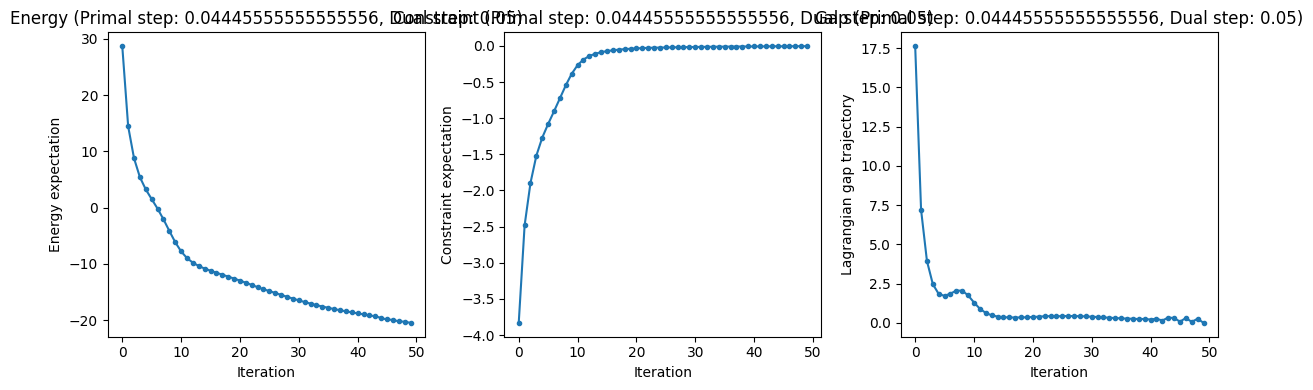

Sample 0: 111111110 with probability 0.8313 and energy -21.90999999999999
Found '111111110' with energy -21.9 and probability 0.8313
Testing primal_perturb_step=0.05, dual_perturb_step=0.0001


100%|██████████| 200/200 [03:29<00:00,  1.05s/it]


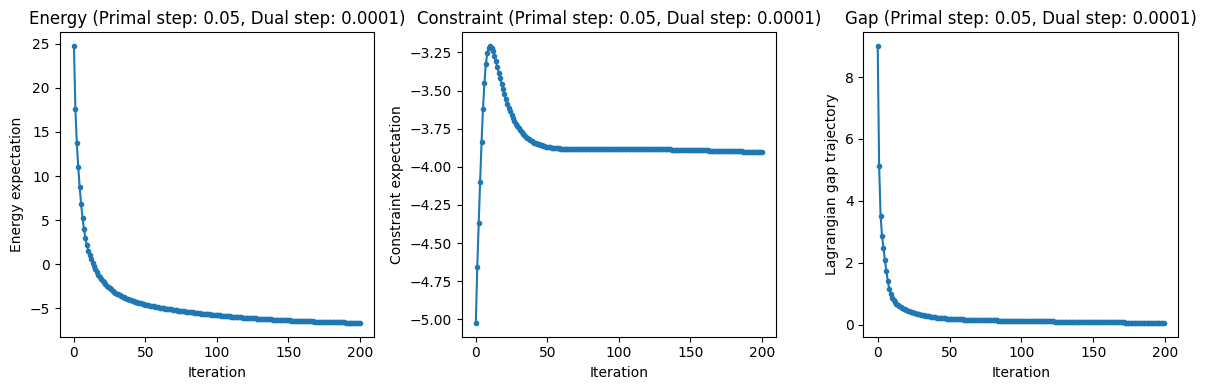

Sample 0: 100001000 with probability 0.2627 and energy -7.260000000000002
Sample 1: 100001101 with probability 0.2283 and energy -7.260000000000007
Sample 2: 100000010 with probability 0.206 and energy -7.260000000000005
Sample 3: 100000111 with probability 0.1733 and energy -7.260000000000001
Sample 4: 100011000 with probability 0.0248 and energy -7.259999999999998
Testing primal_perturb_step=0.05, dual_perturb_step=0.005644444444444445


100%|██████████| 200/200 [03:32<00:00,  1.06s/it]


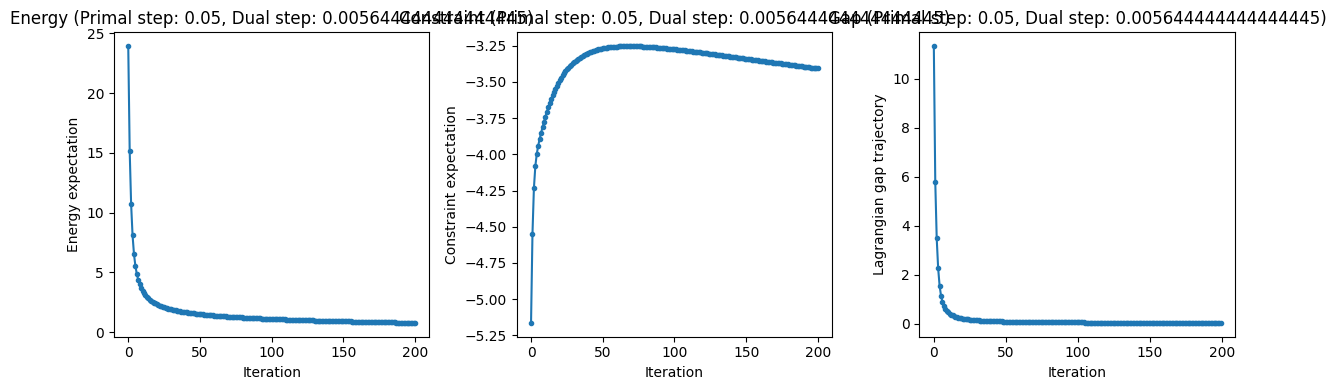

Sample 0: 000100110 with probability 0.1158 and energy 5.329070518200751e-15
Sample 1: 000011000 with probability 0.0895 and energy -2.6645352591003757e-15
Sample 2: 000001101 with probability 0.089 and energy -5.329070518200751e-15
Sample 3: 000101000 with probability 0.0457 and energy 6.661338147750939e-15
Sample 4: 000111000 with probability 0.0452 and energy 8.881784197001252e-16
Testing primal_perturb_step=0.05, dual_perturb_step=0.011188888888888889


 30%|███       | 60/200 [01:03<02:28,  1.06s/it]

Converged after 61 iterations


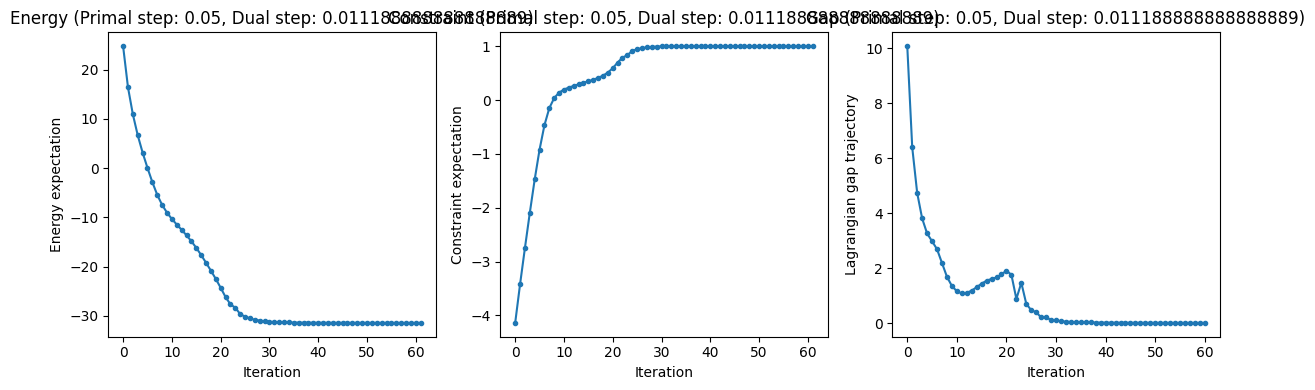

Sample 0: 111000110 with probability 0.5056 and energy -26.430000000000014
Sample 1: 111011010 with probability 0.4937 and energy -36.46999999999999
Sample 2: 110011010 with probability 0.0004 and energy -29.100000000000012
Sample 3: 110000110 with probability 0.0003 and energy -19.060000000000016
Testing primal_perturb_step=0.05, dual_perturb_step=0.016733333333333333


 12%|█▏        | 23/200 [00:26<03:25,  1.16s/it]

Gap closed after 24 iterations; VQEC converged.


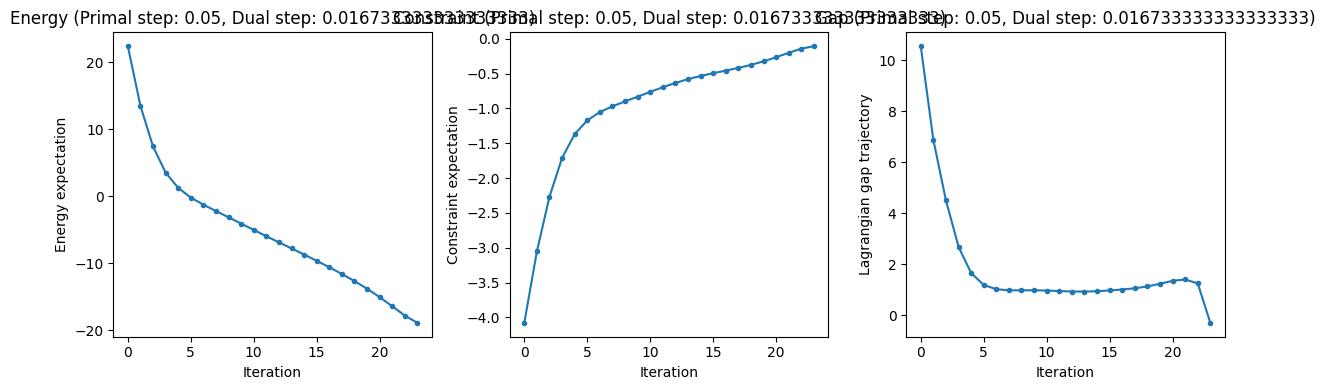

Sample 0: 111000110 with probability 0.2657 and energy -26.430000000000014
Sample 1: 111111110 with probability 0.2202 and energy -21.90999999999999
Found '111111110' with energy -21.9 and probability 0.2202
Testing primal_perturb_step=0.05, dual_perturb_step=0.02227777777777778


 28%|██▊       | 57/200 [01:01<02:34,  1.08s/it]

Gap closed after 58 iterations; VQEC converged.


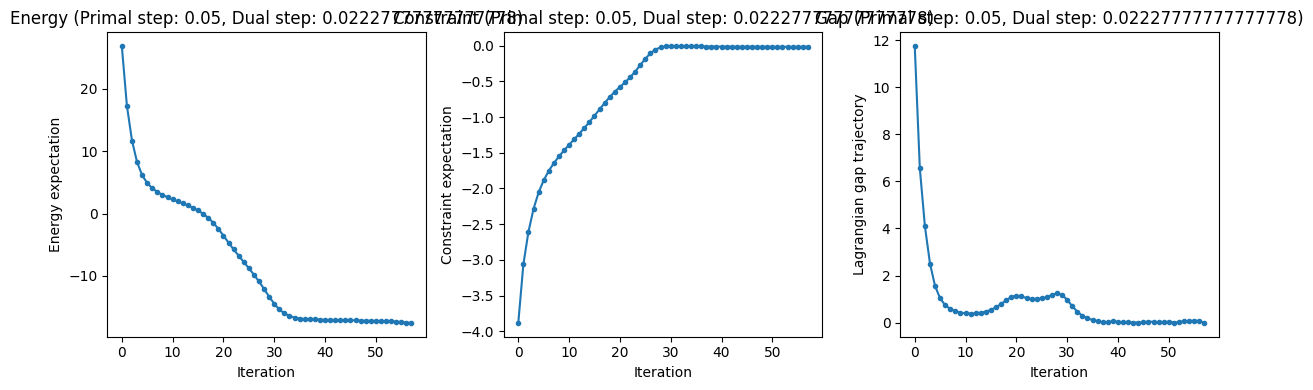

Sample 0: 110111111 with probability 0.7089 and energy -19.059999999999988
Sample 1: 110101011 with probability 0.2849 and energy -14.540000000000003
Sample 2: 110101111 with probability 0.0041 and energy 10.02
Sample 3: 110110011 with probability 0.0009 and energy -0.020000000000007567
Sample 4: 110111011 with probability 0.0006 and energy 43.61999999999999
Testing primal_perturb_step=0.05, dual_perturb_step=0.027822222222222224


 30%|██▉       | 59/200 [01:03<02:31,  1.08s/it]

Converged after 60 iterations


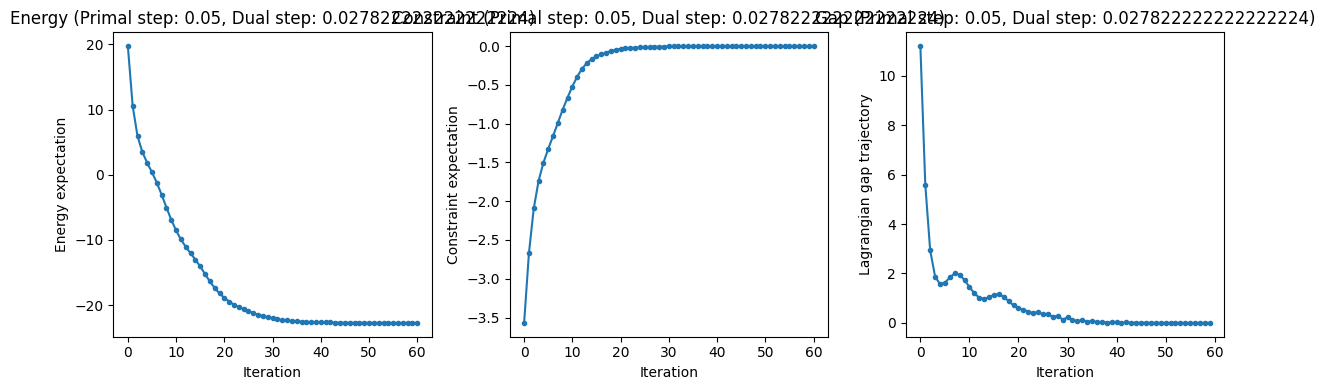

Sample 0: 111000110 with probability 0.5 and energy -26.430000000000014
Sample 1: 110111111 with probability 0.4996 and energy -19.059999999999988
Sample 2: 101000110 with probability 0.0001 and energy -19.150000000000006
Sample 3: 110010010 with probability 0.0001 and energy -4.539999999999997
Sample 4: 110110111 with probability 0.0001 and energy 14.579999999999993
Testing primal_perturb_step=0.05, dual_perturb_step=0.03336666666666667


 77%|███████▋  | 154/200 [02:40<00:47,  1.04s/it]

Converged after 155 iterations


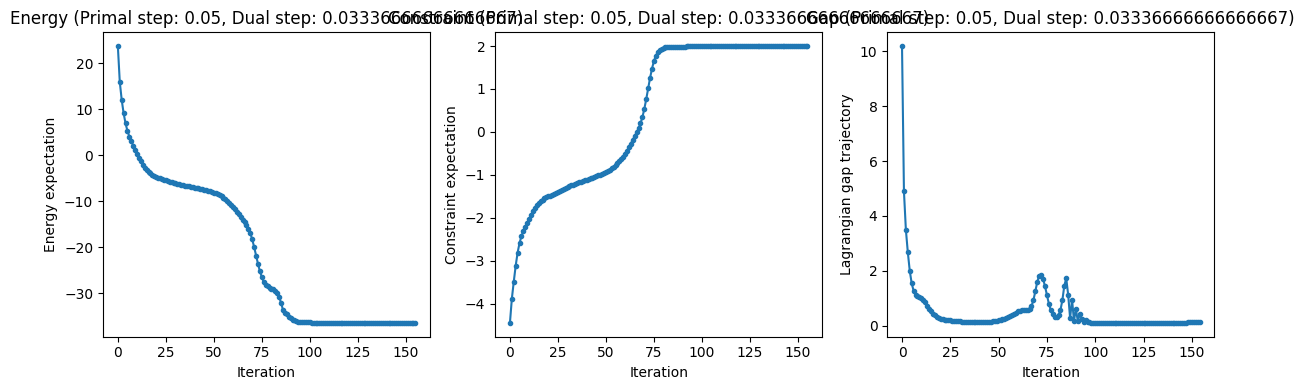

Sample 0: 111011010 with probability 0.9994 and energy -36.46999999999999
Sample 1: 111100110 with probability 0.0005 and energy -7.350000000000003
Sample 2: 011011010 with probability 0.0001 and energy -29.209999999999994
Testing primal_perturb_step=0.05, dual_perturb_step=0.03891111111111112


 86%|████████▌ | 172/200 [03:06<00:30,  1.09s/it]

Converged after 173 iterations


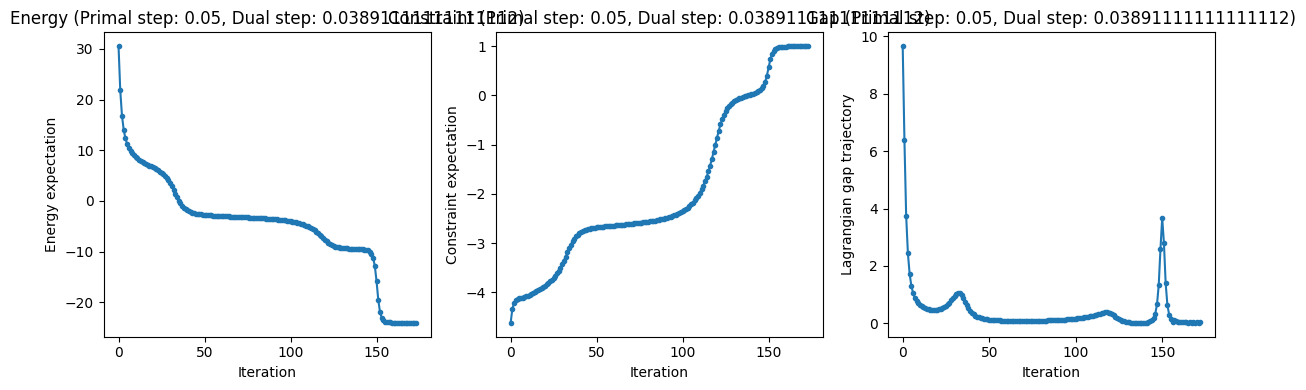

Sample 0: 110110000 with probability 0.504 and energy -19.05999999999999
Sample 1: 110011010 with probability 0.4957 and energy -29.100000000000012
Sample 2: 101101101 with probability 0.0001 and energy 24.85
Sample 3: 110110001 with probability 0.0001 and energy -14.54
Sample 4: 111110000 with probability 0.0001 and energy 17.790000000000013
Testing primal_perturb_step=0.05, dual_perturb_step=0.04445555555555556


100%|██████████| 200/200 [03:28<00:00,  1.04s/it]


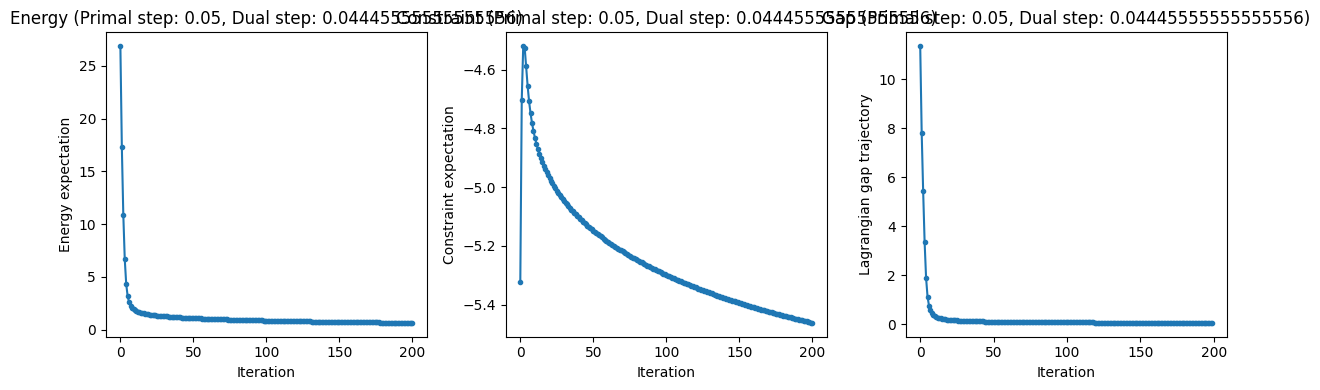

Sample 0: 000100101 with probability 0.0803 and energy -3.552713678800501e-15
Sample 1: 000101011 with probability 0.0771 and energy 2.6645352591003757e-15
Sample 2: 000100100 with probability 0.0769 and energy -1.7763568394002505e-14
Sample 3: 000100110 with probability 0.0747 and energy 5.329070518200751e-15
Sample 4: 000101010 with probability 0.0714 and energy -7.105427357601002e-15
Testing primal_perturb_step=0.05, dual_perturb_step=0.05


 82%|████████▏ | 164/200 [02:51<00:37,  1.04s/it]

Gap closed after 165 iterations; VQEC converged.


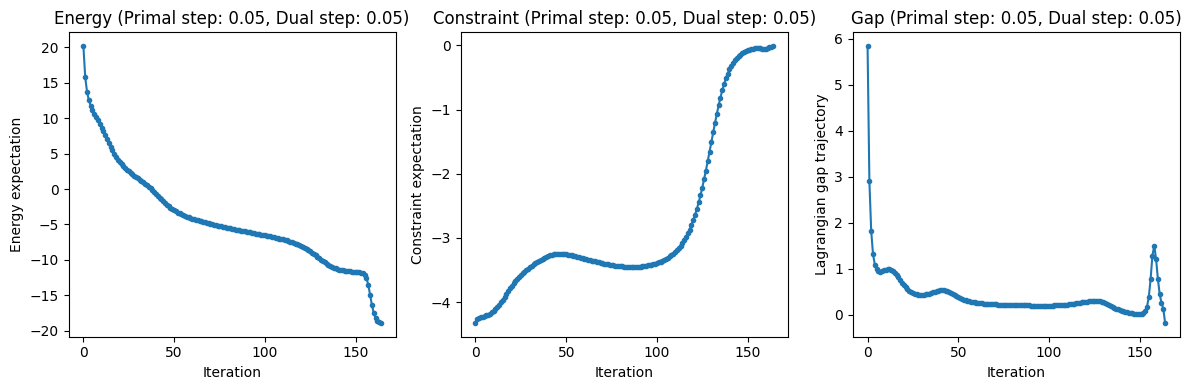

Sample 0: 110001001 with probability 0.4954 and energy -19.059999999999995
Sample 1: 110000110 with probability 0.4872 and energy -19.060000000000016
Sample 2: 100001001 with probability 0.0059 and energy -11.780000000000001
Sample 3: 100000110 with probability 0.0056 and energy -11.780000000000006
Sample 4: 111001001 with probability 0.0017 and energy 3.0500000000000043
Successful perturbation parameters:
Primal Perturb Step: 0.016733333333333333, Dual Perturb Step: 0.011188888888888889
Primal Perturb Step: 0.03891111111111112, Dual Perturb Step: 0.011188888888888889
Primal Perturb Step: 0.03891111111111112, Dual Perturb Step: 0.027822222222222224
Primal Perturb Step: 0.04445555555555556, Dual Perturb Step: 0.05
Primal Perturb Step: 0.05, Dual Perturb Step: 0.016733333333333333


In [10]:
# Range of perturbation parameters to test
primal_perturb_range = np.linspace(0.0001, 0.05, 10)  # Example range for primal perturbation steps
dual_perturb_range = np.linspace(0.0001, 0.05, 10)    # Example range for dual perturbation steps

successful_parameters = []

for primal_perturb_step in primal_perturb_range:
    for dual_perturb_step in dual_perturb_range:
        print(f"Testing primal_perturb_step={primal_perturb_step}, dual_perturb_step={dual_perturb_step}")

        # Run VQEC optimization with current perturbation parameters
        vqec_lincomb = VQECOpt(
            primal_perturb_step=primal_perturb_step,
            dual_perturb_step=dual_perturb_step,
            qubit_op=qubit_op,
            constr_ops=olap_constr_ops,
            ansatz=ansatz_su2,
            estimator=estimator,
            gradient=gradient_lincomb,
            max_iter=200
        )
        vqec_lincomb_result = vqec_lincomb.optimize_primal_dual()

        # Plot the results for energy, constraints, and lagrangian gap
        fig, ax = plt.subplots(1, 3, figsize=(12, 4))

        # Energy plot
        ax[0].plot(vqec_lincomb_result.energies, label="Energy", marker=".")
        ax[0].set_xlabel("Iteration")
        ax[0].set_ylabel("Energy expectation")
        ax[0].set_title(f"Energy (Primal step: {primal_perturb_step}, Dual step: {dual_perturb_step})")

        # Constraint plot
        ax[1].plot(vqec_lincomb_result.constraints[:, 0], label="Overlap", marker=".")
        ax[1].set_xlabel("Iteration")
        ax[1].set_ylabel("Constraint expectation")
        ax[1].set_title(f"Constraint (Primal step: {primal_perturb_step}, Dual step: {dual_perturb_step})")

        # Lagrangian gap plot
        ax[2].plot(vqec_lincomb_result.lagrangian_gap_trajectory, label="Dual", marker=".")
        ax[2].set_xlabel("Iteration")
        ax[2].set_ylabel("Lagrangian gap trajectory")
        ax[2].set_title(f"Gap (Primal step: {primal_perturb_step}, Dual step: {dual_perturb_step})")

        plt.tight_layout()
        plt.show()

        # Copy and measure the full circuit
        full_circ = vqec_lincomb_result.ansatz.copy()
        full_circ.measure_all()
        sampler = Sampler(options={"shots": 10000})
        sampler_result = sampler.run(circuits=[full_circ], parameter_values=vqec_lincomb_result.optimal_primal_vars).result()

        # Extract probabilities and sort
        quasi_dist = sampler_result.quasi_dists[0].binary_probabilities()
        sorted_quasi_dist = dict(sorted(quasi_dist.items(), key=lambda item: item[1], reverse=True))

        # Compute the energies of the top 5 samples and check for "111111110"
        from qufold.execution_utils.measurements import _evaluate_sparsepauli
        bitstring_energies = {}
        found_solution = False

        for i, (sample, prob) in enumerate(sorted_quasi_dist.items()):
            if i >= 5:
                break
            energy = _evaluate_sparsepauli(sample, qubit_op)
            bitstring_energies[sample] = energy
            print(f"Sample {i}: {sample} with probability {prob} and energy {energy}")
            
            # Check if "111111110" appears in the top 5 with energy -21.9
            if sample == "111111110" and np.isclose(energy, -21.9, atol=0.1):
                print(f"Found '111111110' with energy -21.9 and probability {prob}")
                found_solution = True
                break

        # If found, record the perturbation parameters
        if found_solution:
            successful_parameters.append((primal_perturb_step, dual_perturb_step))

# Output the successful parameters
print("Successful perturbation parameters:")
for params in successful_parameters:
    print(f"Primal Perturb Step: {params[0]}, Dual Perturb Step: {params[1]}")


In [45]:
# Optimal solution for LFLF
print(_evaluate_sparsepauli("111111110", qubit_op))

print(_evaluate_sparsepauli("001001110", qubit_op))

-21.909999999999993
-7.36999999999999


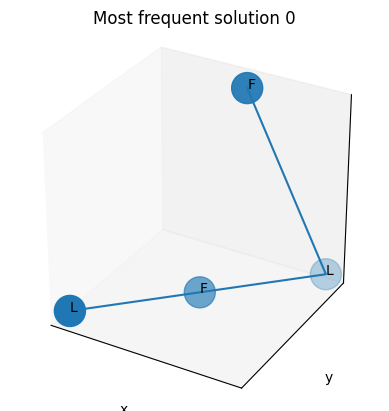

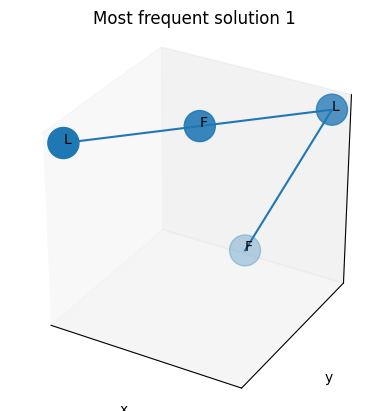

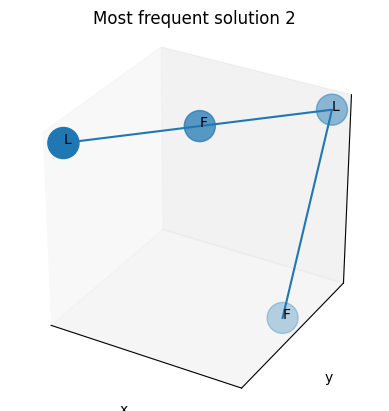

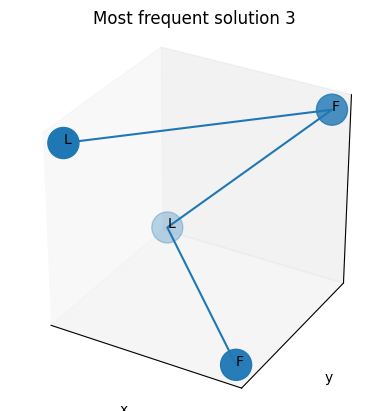

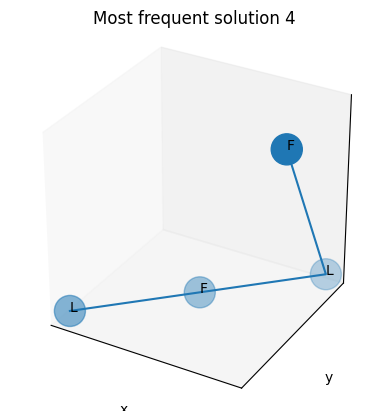

In [30]:
for i, (sample, energy) in enumerate(bitstring_energies.items()):
    pf_result = ProteinFoldingResult(peptide=protein_folding_problem.peptide, unused_qubits=protein_folding_problem.unused_qubits, solution_bitstring=sample)
    fig = pf_result.get_figure(title=f"Most frequent solution {i}")
    plt.show()

In [11]:
for i, (sample, energy) in enumerate(bitstring_energies.items()):
    pf_result = ProteinFoldingResult(peptide=protein_folding_problem.peptide, unused_qubits=protein_folding_problem.unused_qubits, solution_bitstring=sample)
    print(f"Turn sequence: {pf_result.turn_sequence}")
    xyz_coords = pf_result.protein_shape_file_gen.get_xyz_data()
    print(xyz_coords)
    distances = []
    xyz_coords = xyz_coords[:, 1::]
    # Convert the coordinates to float
    xyz_coords = xyz_coords.astype(float)
    for i in range(len(xyz_coords)):
        for j in range(i + 2, len(xyz_coords)):
            distance = (np.linalg.norm(xyz_coords[i] - xyz_coords[j]) / 3.8 * np.sqrt(2)) ** 2
            distances.append(distance)
    print(distances)

Turn sequence: [0, 9, 5]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '0.0' '0.0' '-5.37401153701776']]
[1.9999999999999996, 4.0, 5.999999999999999]
Turn sequence: [0, 9, 11]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '-2.68700576850888' '2.68700576850888' '0.0']]
[1.9999999999999996, 1.9999999999999996, 4.0]
Turn sequence: [0, 9, 11]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '-2.68700576850888' '2.68700576850888' '0.0']]
[1.9999999999999996, 1.9999999999999996, 4.0]
Turn sequence: [0, 9, 5]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '0.0' '0.0' '-5.37401153701776']]
[1.9999999999999996, 4.0, 5.999999999999999]
Turn sequence: [0,

In [12]:
test_op = SparsePauliOp.from_list([("ZII", 1)])
print(test_op)
print(_evaluate_sparsepauli("000", test_op))
print(_evaluate_sparsepauli("001", test_op))
print(_evaluate_sparsepauli("100", test_op))

SparsePauliOp(['ZII'],
              coeffs=[1.+0.j])
1.0
1.0
-1.0


## Checking qubit_op

In [13]:
from fcc.fcc_qubit_op_builder import QubitOpBuilder
from fcc.fcc_distance_map import DistanceMap
from fcc.utils import remove_unused_qubits

In [14]:
main_seq_4

'LFLF'

In [15]:
peptide = Peptide(main_seq_4)
mj_interaction = MiyazawaJerniganInteraction("mj_matrix")
pair_energies = mj_interaction.calculate_energy_matrix(main_seq_4)
penalty_params = PenaltyParameters(50, 50)

qubit_op_builder = QubitOpBuilder(peptide, pair_energies, penalty_params)

In [16]:
contact_op = qubit_op_builder._create_h_contact()
print(contact_op.num_qubits)

# "001001110" -> full bitstring: "001001100100000"
print(_evaluate_sparsepauli("001001100100000", contact_op))

full_qubit_op = qubit_op_builder.build_qubit_op()
print(full_qubit_op.num_qubits)
print(_evaluate_sparsepauli("001001100100000", full_qubit_op))

15
-7.369999999999994
15
-7.36999999999999


In [17]:
reduced_qubit_op, unused_qubits = remove_unused_qubits(full_qubit_op)
print(unused_qubits)
print(reduced_qubit_op.num_qubits)
print(_evaluate_sparsepauli("001001110", reduced_qubit_op))

[0, 1, 2, 3, 6, 7]
9
-7.36999999999999


In [18]:
DM = DistanceMap(peptide)
distance_map = DM.distance_map
distance_map

defaultdict(dict,
            {'0': {'1': SparsePauliOp(['IIIIIIIIIIII'],
                            coeffs=[2.+0.j]),
              '2': SparsePauliOp(['IIIIIIIIIIII', 'IIIIIIZIIIII', 'IIIIIIZZIIII'],
                            coeffs=[5.+0.j, 2.+0.j, 1.+0.j]),
              '3': SparsePauliOp(['IIIIIIIIIIII', 'IIIIIIZIIIII', 'IIZIIIIIIIII', 'ZIZIIIIIIIII', 'IZZIIIIIIIII', 'ZZZIIIIIIIII', 'IIIZIIIIIIII', 'ZIIZIIIIIIII', 'IZIZIIIIIIII', 'ZZIZIIIIIIII', 'IIZIIIZIIIII', 'ZIZIIIZIIIII', 'IZZIIIZIIIII', 'ZZZIIIZIIIII', 'IIIZIIZIIIII', 'ZIIZIIZIIIII', 'ZZIZIIZIIIII', 'ZIIIIIIIIIII', 'IZIIIIIIIIII', 'ZZIIIIIIIIII', 'IIZZIIIIIIII', 'ZIZZIIIIIIII', 'IZZZIIIIIIII', 'ZZZZIIIIIIII', 'IIIIIIZZIIII', 'ZIIIIIZZIIII', 'IZIIIIZZIIII', 'IIZIIIZZIIII', 'ZZZIIIZZIIII', 'IIIZIIZZIIII', 'ZZIZIIZZIIII', 'ZIZZIIZZIIII', 'IZZZIIZZIIII', 'IZZIIIIZIIII', 'IZIZIIIZIIII'],
                            coeffs=[ 6.5 +0.j,  2.  +0.j,  1.25+0.j,  0.5 +0.j,  0.5 +0.j, -0.25+0.j,
               -1.25+0.j,  0.5 +0.j,  

In [19]:
print(_evaluate_sparsepauli("001100100000", distance_map['0']['2']))
print(_evaluate_sparsepauli("001100100000", distance_map['0']['3']))
print(_evaluate_sparsepauli("001100100000", distance_map['1']['3']))

2.0
6.0
6.0


In [20]:
bead_idx = 3
print(_evaluate_sparsepauli("001100100000", DM._compute_x_coordinate(bead_idx)))
print(_evaluate_sparsepauli("001100100000", DM._compute_y_coordinate(bead_idx)))
print(_evaluate_sparsepauli("001100100000", DM._compute_z_coordinate(bead_idx)))

-1.0
2.0
-1.0


## Demo of a potential "issue"

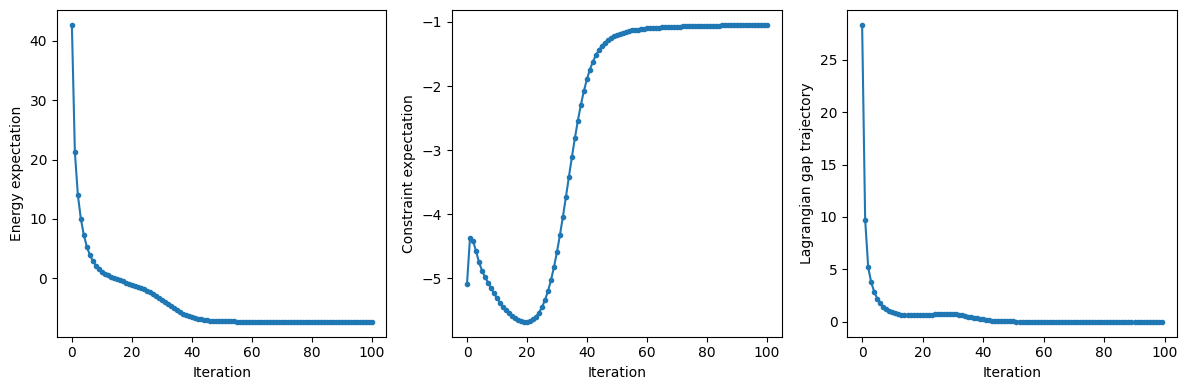

In [21]:
# Plot the results
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].plot(vqec_result.energies, label="Energy", marker=".")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Energy expectation")

ax[1].plot(vqec_result.constraints[:, 0], label="Overlap", marker=".")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Constraint expectation")

ax[2].plot(vqec_result.lagrangian_gap_trajectory, label="Dual", marker=".")
ax[2].set_xlabel("Iteration")
ax[2].set_ylabel("Lagrangian gap trajectory")



plt.tight_layout()
plt.show()

In [22]:
full_circ = vqec_result.ansatz.copy()
full_circ.measure_all()
sampler = Sampler(options={"shots": 10000})
# sampler = Sampler(run_options={"shots": 10000})
sampler_result = sampler.run(circuits=[full_circ], parameter_values=vqec_result.optimal_primal_vars).result()
quasi_dist = sampler_result.quasi_dists[0].binary_probabilities()

# Sort the binary strings by their probabilities
sorted_quasi_dist = dict(sorted(quasi_dist.items(), key=lambda item: item[1], reverse=True))
# Compute the energies of all samples
from qufold.execution_utils.measurements import _evaluate_sparsepauli
bitstring_energies = {}
for i, (sample, prob) in enumerate(sorted_quasi_dist.items()):
    if i >= 5:
        break
    energy = _evaluate_sparsepauli(sample, qubit_op)
    bitstring_energies[sample] = energy
    print(f"Sample {i}: {sample} with probability {prob} and energy {energy}")

Sample 0: 001101010 with probability 0.515 and energy -7.3700000000000045
Sample 1: 001111010 with probability 0.469 and energy -7.369999999999996
Sample 2: 011101010 with probability 0.0072 and energy -0.09000000000000075
Sample 3: 011111010 with probability 0.0062 and energy -14.650000000000006
Sample 4: 000010101 with probability 0.0012 and energy -8.881784197001252e-15


C:\Users\8J6010897\AppData\Local\Temp\ipykernel_44376\2213236805.py:3: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler(options={"shots": 10000})


Note that the second solution above seems to be a valid solution, but clearly, the interaction qubits are not consistent with the configuration qubits. For a given set of configuration qubits, the interaction qubits can be determined completely. 

How should we eliminate such inconsistent bitstrings?
- By postprocessing.
- Better yet, by eliminating them at the Hamiltonian level, which also reduces the search space. But how?

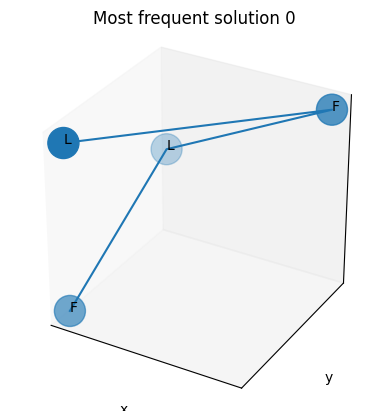

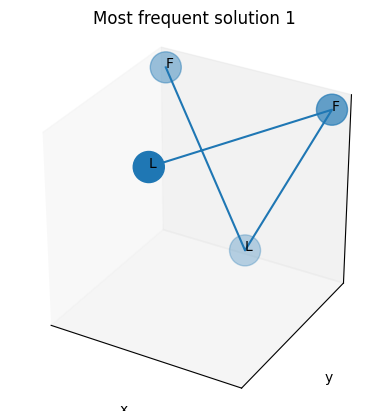

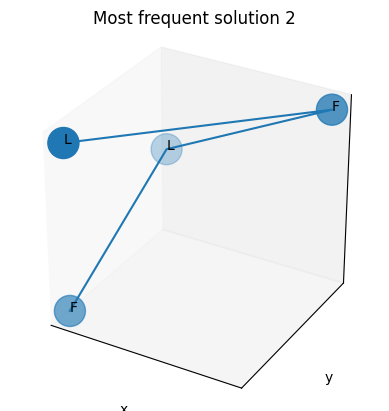

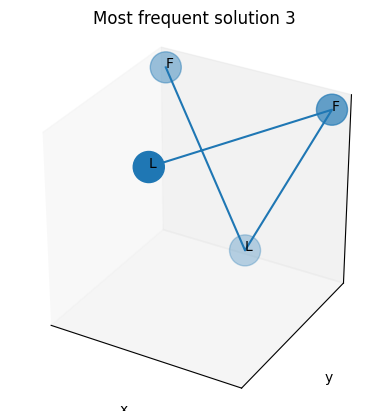

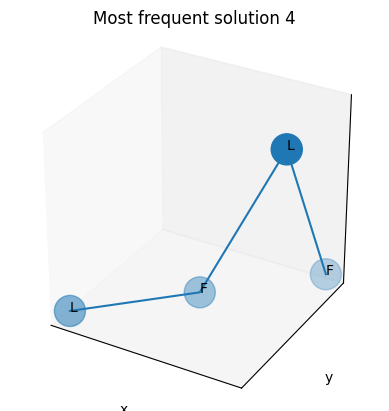

In [23]:
for i, (sample, energy) in enumerate(bitstring_energies.items()):
    pf_result = ProteinFoldingResult(peptide=protein_folding_problem.peptide, unused_qubits=protein_folding_problem.unused_qubits, solution_bitstring=sample)
    fig = pf_result.get_figure(title=f"Most frequent solution {i}")
    plt.show()

In [24]:
for i, (sample, energy) in enumerate(bitstring_energies.items()):
    pf_result = ProteinFoldingResult(peptide=protein_folding_problem.peptide, unused_qubits=protein_folding_problem.unused_qubits, solution_bitstring=sample)
    print(f"Turn sequence: {pf_result.turn_sequence}")
    xyz_coords = pf_result.protein_shape_file_gen.get_xyz_data()
    print(xyz_coords)
    distances = []
    xyz_coords = xyz_coords[:, 1::]
    # Convert the coordinates to float
    xyz_coords = xyz_coords.astype(float)
    for i in range(len(xyz_coords)):
        for j in range(i + 2, len(xyz_coords)):
            distance = (np.linalg.norm(xyz_coords[i] - xyz_coords[j]) / 3.8 * np.sqrt(2)) ** 2
            distances.append(distance)
    print(distances)

Turn sequence: [0, 9, 5]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '0.0' '0.0' '-5.37401153701776']]
[1.9999999999999996, 4.0, 5.999999999999999]
Turn sequence: [0, 9, 11]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '-2.68700576850888' '2.68700576850888' '0.0']]
[1.9999999999999996, 1.9999999999999996, 4.0]
Turn sequence: [0, 9, 5]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '0.0' '0.0' '-5.37401153701776']]
[1.9999999999999996, 4.0, 5.999999999999999]
Turn sequence: [0, 9, 11]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '-2.68700576850888' '2.68700576850888' '0.0']]
[1.9999999999999996, 1.9999999999999996, 4.0]
Turn sequence: [0,